# 0 - Libraries


In [409]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import to_hex
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import chi2, kruskal
from scipy.cluster.hierarchy import set_link_color_palette, dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist
import seaborn as sns
from statannotations.Annotator import Annotator
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

## 0 bis - Hardcoded variable

In [410]:
NORMALIZE_PPR = False  # Set to True to normalize PPR values
n_clust = 5

APPLY_FAILURE_RATE_TRANSFORMATION = False  # Set to True to apply transformation
TRANSFORMATION_METHOD = 'yeo-johnson'  # Options: 'yeo-johnson', 'box-cox', 'quantile-uniform', 'quantile-normal'

# 1 - Data preparation

## 1.A. Direction for fig

In [411]:
output_dir = r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures"
os.makedirs(output_dir, exist_ok=True)

## 1.B. Import data
The PCA will use only the columns AMP1, AMP2, all PPRs and %Fail1 and 2. All the other columns will be un-selected.

In [412]:
#WT experiments
df_WT_pooled  = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="WT_pooled")
df_WT_Theo    = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="WT_Theo")
df_WT_Anthime = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="WT_Anthime")

#SynII experiments
df_SynII      = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="SynII")

#Calcium experiments
df_WT_1_5Ca   = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="Theo_1_5Ca")
df_WT_4Ca     = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="Theo_4Ca")

#Stability experiments
df_stab_before = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="Stability_Before")
df_stab_after  = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="Stability_After")

### 1.B.a Normalize PPR (OPTIONAL)

In [413]:
# Pour toutes les dataframes de données, recalculer les colonnes PPRx/1 comme (AMPx / mean(AMP1...AMP10))

def recalc_ppr_mean(df):
    # Trouver toutes les colonnes AMPx (x=1..9)
    amp_cols = [f'AMP{i}' for i in range(1,10) if f'AMP{i}' in df.columns]
    amp_cols = [col for col in df.columns if col.startswith('AMP') and col.replace('AMP', '').isdigit()]
    if not amp_cols:
        return df
    amp_mean = df[amp_cols].mean(axis=1)
    print(amp_mean)
    for amp_col in amp_cols:
        idx = int(amp_col.replace('AMP', ''))
        ppr_col = f'PPR{idx}/1'
        df[ppr_col] = df[amp_col] / amp_mean
    return df

# Appliquer à chaque dataframe de données
if NORMALIZE_PPR == True:
    df_WT_pooled = recalc_ppr_mean(df_WT_pooled)
    df_WT_Theo = recalc_ppr_mean(df_WT_Theo)
    df_WT_Anthime = recalc_ppr_mean(df_WT_Anthime)
    df_SynII = recalc_ppr_mean(df_SynII)
    df_WT_1_5Ca = recalc_ppr_mean(df_WT_1_5Ca)
    df_WT_4Ca = recalc_ppr_mean(df_WT_4Ca)
    df_stab_before = recalc_ppr_mean(df_stab_before)
    df_stab_after = recalc_ppr_mean(df_stab_after)

### 1.B.c Normalize failure rates (OPTIONAL)

In [414]:
# Yeo-Johnson transformation of failure rates distribution before PCA
# This helps normalize highly skewed, zero-inflated data for PCA

def transform_failure_rates(df, plot_before_after=True):
    """
    Transform failure rate distributions using Yeo-Johnson
    
    Parameters:
    - df: DataFrame containing failure rate data
    - plot_before_after: whether to show before/after distribution plots
    
    Returns:
    - df_transformed: DataFrame with transformed failure rates
    - transformer: fitted transformer object
    """
    # Find failure rate columns (assuming they contain 'Fail' in the name)
    fail_cols = [col for col in df.columns if 'Fail' in col or 'fail' in col]
    if not fail_cols:
        return df

## 1.C. Check if data are comparable

### 1.C.a Amp1, Amp2, PPR 2/1, Fail1 and STD baseline comparison

WT_Theo vs. WT_Anthime: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:8.071e-03 U_stat=4.030e+03
WT_Anthime vs. SynII: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:6.152e-01 U_stat=1.403e+03
WT_Theo vs. SynII: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.111e-07 U_stat=6.961e+03
Kruskal-Wallis test for PPR2/1: H = 33.078, p = 0.000000
WT_Theo vs. WT_Anthime: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.575e-01 U_stat=2.466e+03
WT_Anthime vs. SynII: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.423e-01 U_stat=1.506e+03
WT_Theo vs. SynII: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=4.793e+03
Kruskal-Wallis test for AMP1: H = 4.482, p = 0.106328
WT_Theo vs. WT_Anthime: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=3.032e+03
WT_Anthime vs. SynII: Mann-Whitney-Wilcoxon test 

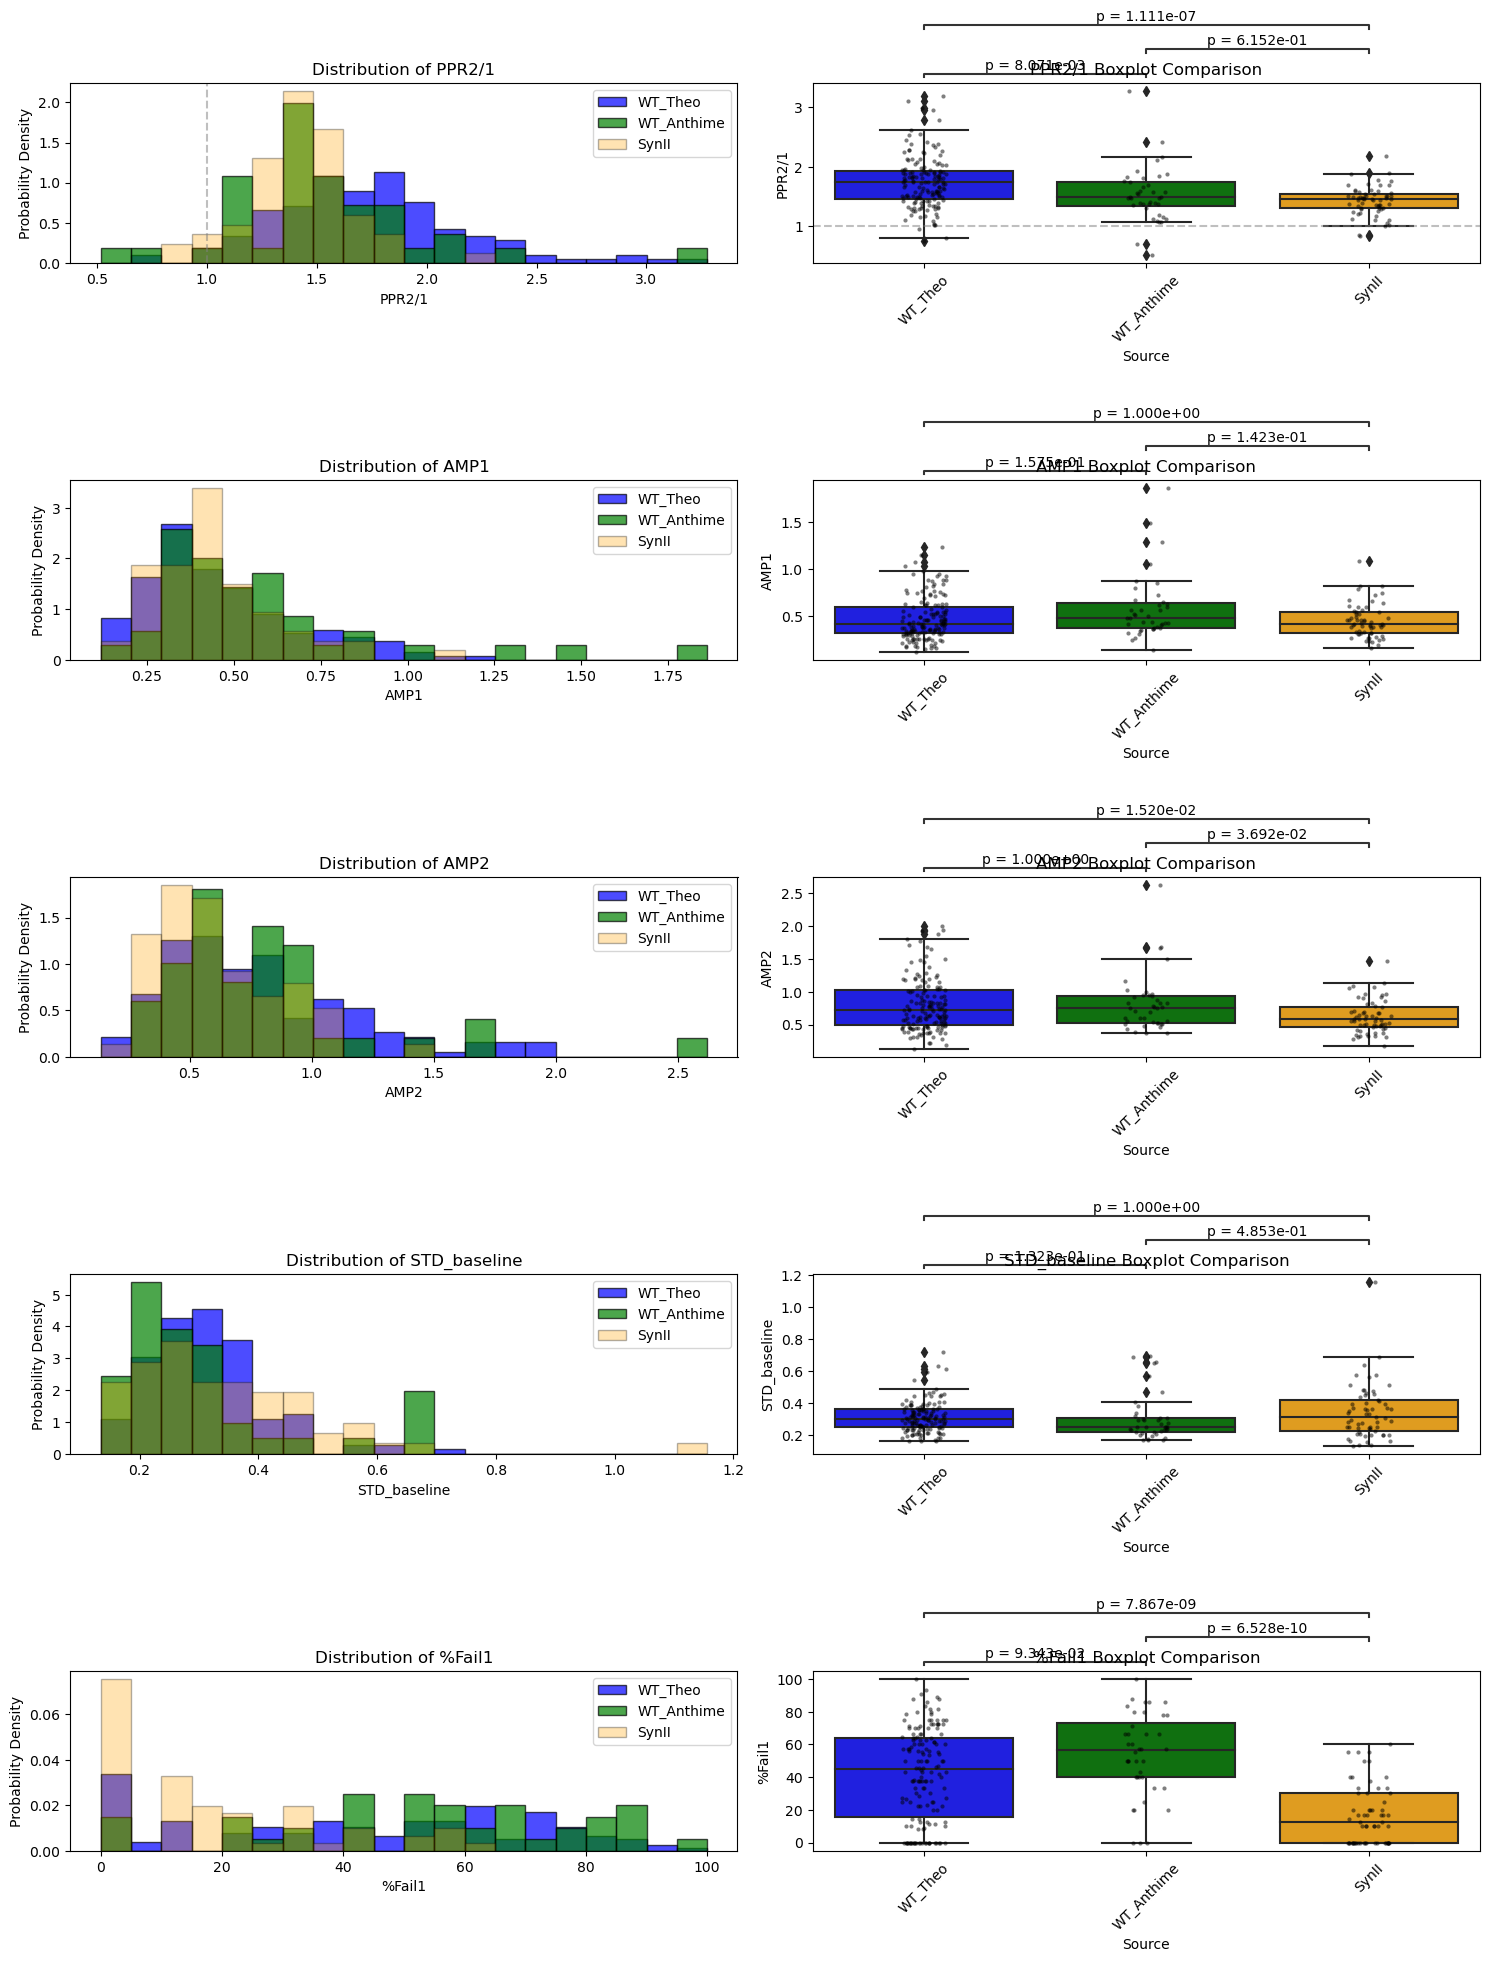

In [415]:
# Create a 5x2 subplot showing histograms (left) and boxplots (right) for different parameters
fig, axes = plt.subplots(5, 2, figsize=(15, 20))

# Use the already loaded datasets from the previous cell
datasets = {
    'WT_Theo': df_WT_Theo,
    'WT_Anthime': df_WT_Anthime, 
    'SynII': df_SynII
}
colors = ['blue', 'green', 'orange']

# Define parameters to analyze
parameters = ['PPR2/1', 'AMP1', 'AMP2', 'STD_baseline', '%Fail1']
special_lines = {'PPR2/1': 1}  # Parameters that need horizontal reference lines

# Define pairwise comparisons for statistical testing (will be reused for all params)
# NOTE: statannotations utilisera ces comparaisons pour des tests de Mann-Whitney pairwise (non-paramétrique)
comparisons = [
    ("WT_Theo", "SynII"),
    ("WT_Theo", "WT_Anthime"),
    ("WT_Anthime", "SynII"),
]

from itertools import combinations  # au cas où besoin dynamique plus tard

# Préparer le fichier texte pour sauvegarder les résultats statistiques
txt_path = os.path.join(output_dir, "0_parameter_comparison_histograms_boxplot.txt")
with open(txt_path, "w", encoding="utf-8") as f_txt:
    # Loop through each parameter
    for i, param in enumerate(parameters):
        # Calculate global range for this parameter
        all_data = []
        for dataset in datasets.values():
            all_data.extend(dataset[param].dropna())
        bins = np.linspace(min(all_data), max(all_data), 21)  # 20 bins
        
        # Histogram (left column)
        for j, (name, dataset) in enumerate(datasets.items()):
            axes[i, 0].hist(dataset[param].dropna(), bins=bins, 
                           edgecolor='black', alpha=0.7 if name != 'SynII' else 0.3, 
                           label=name, color=colors[j], density=True)
        
        axes[i, 0].set_xlabel(param)
        axes[i, 0].set_ylabel('Probability Density')
        axes[i, 0].set_title(f'Distribution of {param}')
        axes[i, 0].legend()
        
        # Add special horizontal lines if needed
        if param in special_lines:
            axes[i, 0].axvline(special_lines[param], color='gray', linestyle='--', alpha=0.5)
        
        # Boxplot with statistical annotations (right column)
        # Create combined DataFrame for this parameter
        param_frames = []
        for name, dataset in datasets.items():
            param_frames.append(dataset[[param]].assign(Source=name))
        param_combined_df = pd.concat(param_frames, ignore_index=True)
        
        ax = axes[i, 1]
        sns.boxplot(data=param_combined_df, x='Source', y=param, ax=ax, palette=colors)
        sns.stripplot(data=param_combined_df, x='Source', y=param, ax=ax, color='k', size=3, alpha=0.5)
        
        # Add special horizontal lines if needed
        if param in special_lines:
            ax.axhline(special_lines[param], color='gray', linestyle='--', alpha=0.5)
        
        # Apply statistical annotations: pairwise Mann-Whitney + correction Bonferroni, p-values affichées
        try:
            annotator = Annotator(ax, comparisons, data=param_combined_df, x='Source', y=param)
            annotator.configure(test='Mann-Whitney', text_format='full', loc='outside',
                               comparisons_correction='bonferroni', show_test_name=False)
            annotator.apply_and_annotate()
        except Exception as e:
            print(f"Warning: Could not add statistical annotations for {param}: {e}")
            f_txt.write(f"Warning: Could not add statistical annotations for {param}: {e}\n")
        
        ax.set_ylabel(param)
        ax.set_title(f'{param} Boxplot Comparison')
        ax.tick_params(axis='x', rotation=45)
        
        # Perform overall Kruskal-Wallis test
        param_groups = [datasets[name][param].dropna() for name in datasets.keys()]
        try:
            param_kruskal_stat, param_kruskal_p = kruskal(*param_groups)
            result_str = f"Kruskal-Wallis test for {param}: H = {param_kruskal_stat:.3f}, p = {param_kruskal_p:.6f}"
        except Exception as e:
            result_str = f"Kruskal-Wallis test for {param}: FAILED ({e})"
        print(result_str)
        f_txt.write(result_str + "\n")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "01_parameter_comparison_histograms_boxplot.pdf"))
plt.show()

### 1.C.b Checking of the mean PPR profile 

For SynII, WT Anthime, WT Théo. Without considering any cluster for now.

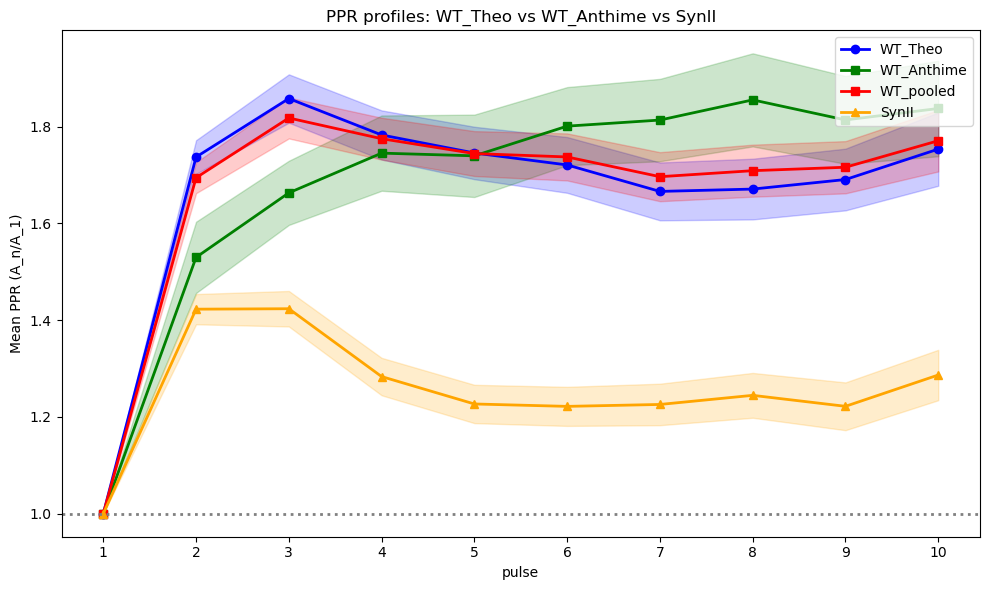

In [416]:
# Plot PPR profiles for WT_Theo and WT_Anthime with SEM
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_WT_Theo.columns]
x_pulses = list(range(1, len(ppr_cols)+2))  # 1 to 10

plt.figure(figsize=(10, 6))

# Use actual PPR1/1 value if NORMALIZE_PPR is True, else force to 1
def get_ppr_profile(df, ppr_cols):
    if NORMALIZE_PPR and 'PPR1/1' in df.columns:
        means = [df['PPR1/1'].mean()] + df[ppr_cols].mean().tolist()
        sems = [df['PPR1/1'].sem()] + df[ppr_cols].sem().tolist()
    else:
        means = [1] + df[ppr_cols].mean().tolist()
        sems = [0] + df[ppr_cols].sem().tolist()
    return means, sems

means_theo, sems_theo = get_ppr_profile(df_WT_Theo, ppr_cols)
means_anthime, sems_anthime = get_ppr_profile(df_WT_Anthime, ppr_cols)
means_pooled, sems_pooled = get_ppr_profile(df_WT_pooled, ppr_cols)
means_synii, sems_synii = get_ppr_profile(df_SynII, ppr_cols)

# Plot WT_Theo PPR profile
plt.plot(x_pulses, means_theo, marker='o', label='WT_Theo', color='blue', linewidth=2)
plt.fill_between(x_pulses, np.array(means_theo)-np.array(sems_theo), 
                 np.array(means_theo)+np.array(sems_theo), alpha=0.2, color='blue')

# Plot WT_Anthime PPR profile
plt.plot(x_pulses, means_anthime, marker='s', label='WT_Anthime', color='green', linewidth=2)
plt.fill_between(x_pulses, np.array(means_anthime)-np.array(sems_anthime), 
                 np.array(means_anthime)+np.array(sems_anthime), alpha=0.2, color='green')

# Plot pooled PPR profile
plt.plot(x_pulses, means_pooled, marker='s', label='WT_pooled', color='red', linewidth=2)
plt.fill_between(x_pulses, np.array(means_pooled)-np.array(sems_pooled), 
                 np.array(means_pooled)+np.array(sems_pooled), alpha=0.2, color='red')

# Plot SynII PPR profile
plt.plot(x_pulses, means_synii, marker='^', label='SynII', color='orange', linewidth=2)
plt.fill_between(x_pulses, np.array(means_synii)-np.array(sems_synii), 
                 np.array(means_synii)+np.array(sems_synii), alpha=0.2, color='orange')

plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('Mean PPR (A_n/A_1)')
plt.xlabel('pulse')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.title('PPR profiles: WT_Theo vs WT_Anthime vs SynII')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "02_WT_Theo_vs_Anthime_vs_SynII_PPR_profiles.pdf"))
plt.show()

### 1.C.c Checking the normalized traces
Each traces were cut to be 1scd long, with 0.5scd for the baseline. Since the sampling rate wasn't the same for each condition (from the fastest to the slowest : WT théo [small linescan], SynII [parallel linescan, 4 lines], WT anthime [long parallel linescan, 4 to 6 lines]) it has been decided to downsample everything to a fix value (here 300Hz) so the amplitudes could be on a comparable basis. Indeed, more points could lead to a sharper and taller peak.

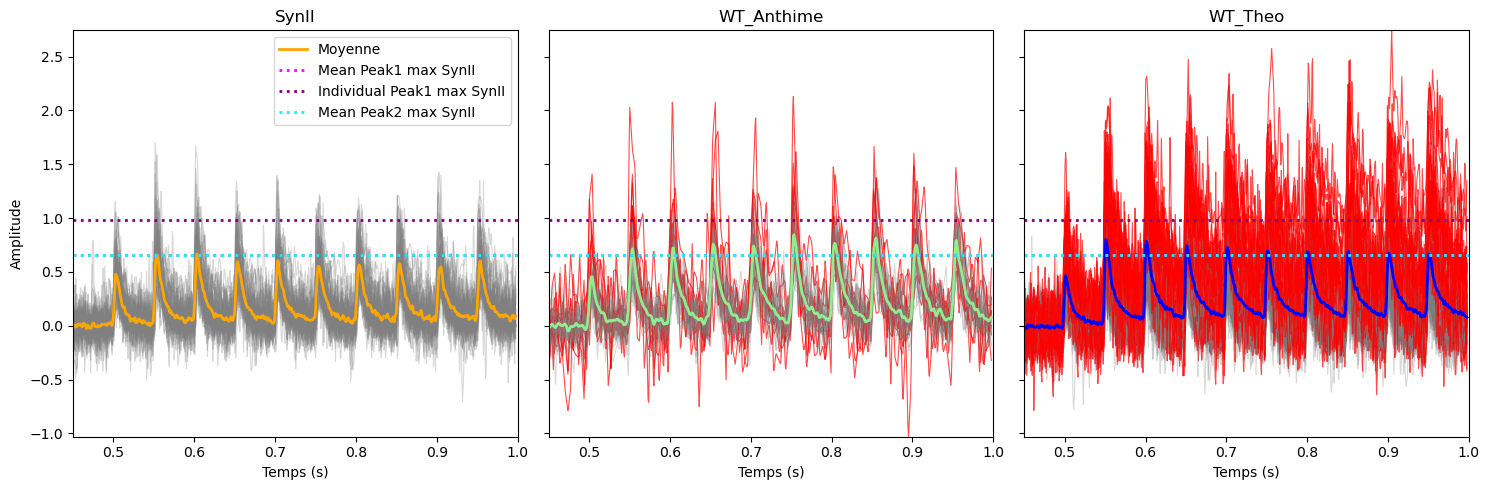


Traces WT_Anthime avec pic > seuil violet (n=10):
  241211_Fibre1_PortionA_bouton10
  241211_Fibre1_PortionA_bouton11
  241211_Fibre1_PortionA_bouton2
  241211_Fibre1_PortionA_bouton4
  241211_Fibre1_PortionA_bouton6
  241211_Fibre1_PortionA_bouton7
  241211_Fibre1_PortionA_bouton8
  241211_Fibre1_PortionA_bouton9
  241212_Fibre1_PortionB_bouton4
  241212_Fibre1_PortionD_bouton2

Traces WT_Theo avec pic > seuil violet (n=53):
  20201015_linescan2_20Hz_10pulses_2.5mMCa_bouton2
  20210125_linescan1_20Hz_10pulses_2.5mMCa_bouton2
  20210125_linescan2_20Hz_10pulses_2.5mMCa_bouton1
  20210125_linescan3_20Hz_10pulses_2.5mMCa_bouton1
  20210125_linescan3_20Hz_10pulses_2.5mMCa_bouton2
  20210125_linescan3_20Hz_10pulses_2.5mMCa_bouton3
  20210128_linescan1_20Hz_10pulses_2.5mMCa_bouton1
  20210128_linescan1_20Hz_10pulses_2.5mMCa_bouton2
  20210128_linescan1_20Hz_10pulses_2.5mMCa_bouton3
  20210128_linescan2_20Hz_10pulses_2.5mMCa_bouton3
  20210128_linescan2_20Hz_10pulses_2.5mMCa_bouton5
  202101

In [417]:
# Charger les traces
test_SynII = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx", sheet_name="SynII")
test_wt_anthime = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx", sheet_name="WT_Anthime")
test_wt_theo = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx", sheet_name="WT_Theo")

# Extraire le temps
time = test_SynII.iloc[1:, 0].values.astype(float)

# Extraire les traces (toutes sauf la colonne temps)
traces_synii = test_SynII.iloc[1:, 1:].astype(float).values
traces_wt_anthime = test_wt_anthime.iloc[1:, 1:].astype(float).values
traces_wt_theo = test_wt_theo.iloc[1:, 1:].astype(float).values

# Moyennes
mean_synii = np.mean(traces_synii, axis=1)
mean_wt_anthime = np.mean(traces_wt_anthime, axis=1)
mean_wt_theo = np.mean(traces_wt_theo, axis=1)

# Mesure du pic SynII entre 0.5s et 0.53s
mask_peak = (time >= 0.55) & (time <=0.58)
peak_amp_synii = mean_synii[mask_peak].max()

# Mesure du pic le plus haut des traces individuelles de SynII entre 0.5s et 0.53s
peak_synii_individual = np.percentile(traces_synii[mask_peak, :], 98)

# Mesure du pic 2 de la moyenne SynII entre 0.55s et 0.58s
mask_peak2 = (time >= 0.55) & (time <= 0.58)
peak_amp_synii_2 = mean_synii[mask_peak2].max()

# Détermination des bornes globales pour l'échelle
all_traces = np.concatenate([traces_synii, traces_wt_anthime, traces_wt_theo], axis=1)
ymin = np.min(all_traces)
ymax = np.max(all_traces)

# Création de la figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Plot SynII
for trace in traces_synii.T:
    axes[0].plot(time, trace, color='gray', alpha=0.3, linewidth=0.8)
axes[0].plot(time, mean_synii, color='orange', linewidth=2, label='Moyenne')
axes[0].axhline(peak_amp_synii, color='magenta', linestyle='dotted', linewidth=2, label='Mean Peak1 max SynII')
axes[0].axhline(peak_synii_individual, color='purple', linestyle='dotted', linewidth=2, label='Individual Peak1 max SynII')
axes[0].axhline(peak_amp_synii_2, color='cyan', linestyle='dotted', linewidth=2, label='Mean Peak2 max SynII')
axes[0].set_title('SynII')
axes[0].set_ylim(ymin, ymax)
axes[0].set_xlim(0.45, 1.0)
axes[0].legend()

# Plot WT_Anthime
red_traces_anthime = []
for i, trace in enumerate(traces_wt_anthime.T):
    trace_peak = trace[mask_peak].max()
    if trace_peak > peak_synii_individual:
        axes[1].plot(time, trace, color='red', alpha=0.7, linewidth=0.8)
        red_traces_anthime.append(test_wt_anthime.columns[i+1])  # +1 because first column is time
    else:
        axes[1].plot(time, trace, color='gray', alpha=0.3, linewidth=0.8)
axes[1].plot(time, mean_wt_anthime, color='lightgreen', linewidth=2, label='Moyenne')
axes[1].axhline(peak_amp_synii, color='magenta', linestyle='dotted', linewidth=2, label='Mean Peak1 max SynII')
axes[1].axhline(peak_synii_individual, color='purple', linestyle='dotted', linewidth=2, label='Individual Peak1 max SynII')
axes[1].axhline(peak_amp_synii_2, color='cyan', linestyle='dotted', linewidth=2, label='Mean Peak2 max SynII')
axes[1].set_title('WT_Anthime')
axes[1].set_ylim(ymin, ymax)
axes[1].set_xlim(0.45, 1.0)

# Plot WT_Theo
red_traces_theo = []
for i, trace in enumerate(traces_wt_theo.T):
    trace_peak = trace[mask_peak].max()
    if trace_peak > peak_synii_individual:
        axes[2].plot(time, trace, color='red', alpha=0.7, linewidth=0.8)
        red_traces_theo.append(test_wt_theo.columns[i+1])  # +1 because first column is time
    else:
        axes[2].plot(time, trace, color='gray', alpha=0.3, linewidth=0.8)
axes[2].plot(time, mean_wt_theo, color='blue', linewidth=2, label='Moyenne')
axes[2].axhline(peak_amp_synii, color='magenta', linestyle='dotted', linewidth=2, label='Mean Peak1 max SynII')
axes[2].axhline(peak_synii_individual, color='purple', linestyle='dotted', linewidth=2, label='Individual Peak1 max SynII')
axes[2].axhline(peak_amp_synii_2, color='cyan', linestyle='dotted', linewidth=2, label='Mean Peak2 max SynII')
axes[2].set_title('WT_Theo')
axes[2].set_ylim(ymin, ymax)
axes[2].set_xlim(0.45, 1.0)

for ax in axes:
    ax.set_xlabel('Temps (s)')
axes[0].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "03_Traces_SynII_WTAnthime_WTTheo.pdf"))
plt.show()

# Print and save the IDs of traces in red (above purple threshold) and the threshold value
txt_path = os.path.join(output_dir, "2_Traces_SynII_WTAnthime_WTTheo.txt")
with open(txt_path, "w", encoding="utf-8") as f_txt:
    f_txt.write(f"Traces WT_Anthime avec pic > seuil violet (n={len(red_traces_anthime)}):\n")
    for trace_id in red_traces_anthime:
        f_txt.write(f"  {trace_id}\n")
    f_txt.write(f"\nTraces WT_Theo avec pic > seuil violet (n={len(red_traces_theo)}):\n")
    for trace_id in red_traces_theo:
        f_txt.write(f"  {trace_id}\n")
    f_txt.write(f"\nSeuil violet (pic max traces SynII): {peak_synii_individual:.3f}\n")

print(f"\nTraces WT_Anthime avec pic > seuil violet (n={len(red_traces_anthime)}):")
for trace_id in red_traces_anthime:
    print(f"  {trace_id}")

print(f"\nTraces WT_Theo avec pic > seuil violet (n={len(red_traces_theo)}):")
for trace_id in red_traces_theo:
    print(f"  {trace_id}")

print(f"\nSeuil violet (pic max traces SynII): {peak_synii_individual:.3f}")


## 1.D. Prepare data for analyses

In [418]:
#Get rids of the un-used columns for the PCA
df_WT_pooled   = df_WT_pooled.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline', 'Target'], axis=1) 
df_WT_Theo     = df_WT_Theo.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline', 'Target'], axis=1)
df_WT_Anthime  = df_WT_Anthime.drop(['ID','AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline'], axis=1)
df_SynII       = df_SynII.drop(['ID','AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline'], axis=1)
df_WT_1_5Ca    = df_WT_1_5Ca .drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1)
df_WT_4Ca      = df_WT_4Ca.drop(['ID','AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1)
df_stab_before = df_stab_before.drop(['ID','AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1)
df_stab_after  = df_stab_after.drop(['ID','AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1)

#Extracts labels
labels = df_WT_pooled.columns

## 1.E. PCA preparation

### 1.E.a Normalization

Normalization is essential before applying PCA or UMAP because these algorithms are sensitive to the scale of the variables. If features have different units or variances, those with larger scales can dominate the analysis and distort the results. By standardizing all features to have zero mean and unit variance, we ensure that each variable contributes equally to the dimensionality reduction and clustering steps.

In [419]:
#Creates a standard scaler object to normalize data
scaler = StandardScaler() 

#Fits scaler on df_WT_pooled (for means and std)
scaled_data_WT_pooled = scaler.fit_transform(df_WT_pooled)

#Applies the same scaling to all other datasets. For same feature space for PCA comparison
scaled_data_WT_Theo     = scaler.transform(df_WT_Theo)
scaled_data_WT_Anthime  = scaler.transform(df_WT_Anthime)
scaled_data_SynII       = scaler.transform(df_SynII)
scaled_data_WT_1_5Ca    = scaler.transform(df_WT_1_5Ca)
scaled_data_WT_4Ca      = scaler.transform(df_WT_4Ca)
scaled_data_stab_before = scaler.transform(df_stab_before)
scaled_data_stab_after  = scaler.transform(df_stab_after)

### 1.E.b - PCA construction
PCA is performed on the entire WT_pooled dataset to capture the main axes of variation present in all samples. By using all available data, the principal components reflect the global structure and variability of the dataset, ensuring that the projection is representative and comparable across different experimental groups. PCA is a good choice because it reduces dimensionality while preserving as much variance as possible, making it easier to visualize complex data and identify patterns or clusters. Additionally, PCA provides orthogonal axes (principal components) that are uncorrelated, which simplifies downstream analyses and interpretation.

In [420]:
#Creates a PCA object that reduces the data to 2 principal components
reducer_PCA = PCA(n_components=2)

#Fits the PCA on scaled_data_WT_pooled (learns projection axes)
transformed_data_WT_pooled = reducer_PCA.fit_transform(scaled_data_WT_pooled)

# Projects all other scaled datasets into the same space defined by new_df
transformed_data_WT_Theo     = reducer_PCA.transform(scaled_data_WT_Theo)
transformed_data_WT_Anthime  = reducer_PCA.transform(scaled_data_WT_Anthime)
transformed_data_SynII       = reducer_PCA.transform(scaled_data_SynII)
transformed_data_WT_1_5Ca    = reducer_PCA.transform(scaled_data_WT_1_5Ca)
transformed_data_WT_4Ca      = reducer_PCA.transform(scaled_data_WT_4Ca)
transformed_data_stab_before = reducer_PCA.transform(scaled_data_stab_before)
transformed_data_stab_after  = reducer_PCA.transform(scaled_data_stab_after)

### 1.E.c Organisation

In [421]:
# Create a DataFrame with columns PC1 and PC2
transformed_WT_pooled  = pd.DataFrame(transformed_data_WT_pooled, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_Theo    = pd.DataFrame(transformed_data_WT_Theo, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_Anthime = pd.DataFrame(transformed_data_WT_Anthime, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_SynII      = pd.DataFrame(transformed_data_SynII, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_1_5Ca   = pd.DataFrame(transformed_data_WT_1_5Ca, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_4Ca     = pd.DataFrame(transformed_data_WT_4Ca, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_stab_before = pd.DataFrame(transformed_data_stab_before, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_stab_after  = pd.DataFrame(transformed_data_stab_after, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])

### 1.E.d Few checks

In [422]:
print(" explained variance: ", reducer_PCA.explained_variance_ratio_)

 explained variance:  [0.58077392 0.20221916]


In [423]:
#Creates a DataFrame showing how much each original feature contributes to PC1 and PC2.
df_components = pd.DataFrame(reducer_PCA.components_, columns = labels, index = ['PC_1', 'PC_2'])
df_components

,AMP1,AMP2,PPR2/1,PPR3/1,PPR4/1,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2
PC_1,-0.134111,-0.022245,0.238224,0.312341,0.337913,0.345887,0.345109,0.345045,0.340994,0.342977,0.340249,0.056819,-0.048210
PC_2,0.478081,0.556940,0.121508,0.048580,0.052692,0.033005,0.001942,0.003971,0.004762,0.019954,-0.005103,-0.483674,-0.453717


In [424]:
#Concatenates the PCA-transformed data (PC1, PC2) and the original features (new_df) into one table
full_table = pd.concat([transformed_WT_pooled, df_WT_pooled], axis=1, join='inner')

#Computes the correlation matrix between all columns in full_table. Shows how each principal component correlates with the original features
full_table_df = full_table.corr()

#Extracts only the correlations between PC1/PC2 and the original features
coeff_corr = full_table_df.iloc[0:2,2:]
coeff_corr

,AMP1,AMP2,PPR2/1,PPR3/1,PPR4/1,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2
PC1,-0.368503,-0.061124,0.654577,0.858231,0.928497,0.950407,0.948268,0.948093,0.936963,0.942410,0.934916,0.156123,-0.132469
PC2,0.775147,0.903007,0.197010,0.078766,0.085433,0.053514,0.003148,0.006439,0.007722,0.032353,-0.008273,-0.784216,-0.735645


# 2 - Classes of STP and glutamate release properties at GC boutons

## 2.A - PCA visualization

### 2.A.a - Hierarchical clustering on PCA
By performing hierarchical clustering (HC) on the PCA embedding, we can identify clusters that may not be visible in the linear PCA projection. The resulting cluster labels are then projected back onto the PCA space to visualize how these non-linear clusters are distributed in the principal component axes.

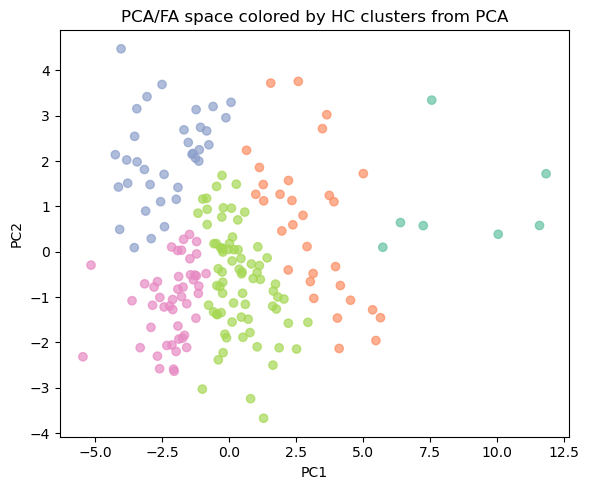

In [425]:
# Perform hierarchical clustering on PCA
Z         = linkage(transformed_data_WT_pooled, method='ward') 
hc_labels = fcluster(Z, n_clust, criterion='maxclust')

# Import again the pooled data for WT and add HC labels 
df_WT_poolclust  = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="WT_pooled")
df_WT_poolclust['HC_UMAP'] = hc_labels

# Use consistent colormap
cmap = cm.get_cmap('Set2')
colors_umap = [cmap(l-1) for l in hc_labels]

# Project HC cluster labels onto PCA/FA space
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(transformed_data_WT_pooled[:, 0], transformed_data_WT_pooled[:, 1], 
                    c=colors_umap, alpha=0.7)

"""
def draw_ellipse(position, covariance, ax, **kwargs):
    #Draw confidence ellipse for cluster visualization
    if covariance.shape == (2, 2):
        # Critical value for 95% confidence with 2 degrees of freedom
        chi2_val = chi2.ppf(0.95, df=2)
        # Singular value decomposition of covariance matrix
        U, s, _ = np.linalg.svd(covariance)
        # Rotation angle of the ellipse
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        # Width and height of the ellipse (principal axes)
        width, height = 2 * np.sqrt(chi2_val * s)
    else:
        # 1D case (shouldn't happen with PC1 and PC2)
        angle = 0
        chi2_val = chi2.ppf(0.95, df=1)
        width, height = 2 * np.sqrt(chi2_val * covariance), 2 * np.sqrt(chi2_val * covariance)
    
    ellipse = Ellipse(position, width, height, angle, **kwargs)
    ax.add_patch(ellipse)

# Add confidence ellipses for each cluster
for cluster_id in range(1, n_clust + 1):
    # Get points belonging to this cluster
    cluster_mask = hc_labels == cluster_id
    cluster_points = transformed_data_WT_pooled[cluster_mask]
    
    if len(cluster_points) > 2:  # Need at least 3 points for covariance
        # Calculate cluster center and covariance
        center = np.mean(cluster_points, axis=0)
        covariance = np.cov(cluster_points.T)
        
        # Draw 95% confidence ellipse
        draw_ellipse(center, covariance, ax, 
                    facecolor=cmap(cluster_id-1), alpha=0.2, 
                    edgecolor=cmap(cluster_id-1), linewidth=2)
"""

ax.set_title('PCA/FA space colored by HC clusters from PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "04_PCA_pooled.pdf"))

### 2.A.b Dendrogram 

A dendrogram is plotted here to visualize the hierarchical relationships between samples based on their similarity in the consensus UMAP embedding. This tree-like diagram allows us to see how clusters are formed at different levels of similarity, identify distinct groups, and assess the structure and separation of clusters. It provides an intuitive way to explore the results of hierarchical clustering and supports the selection of cluster boundaries for downstream analysis.

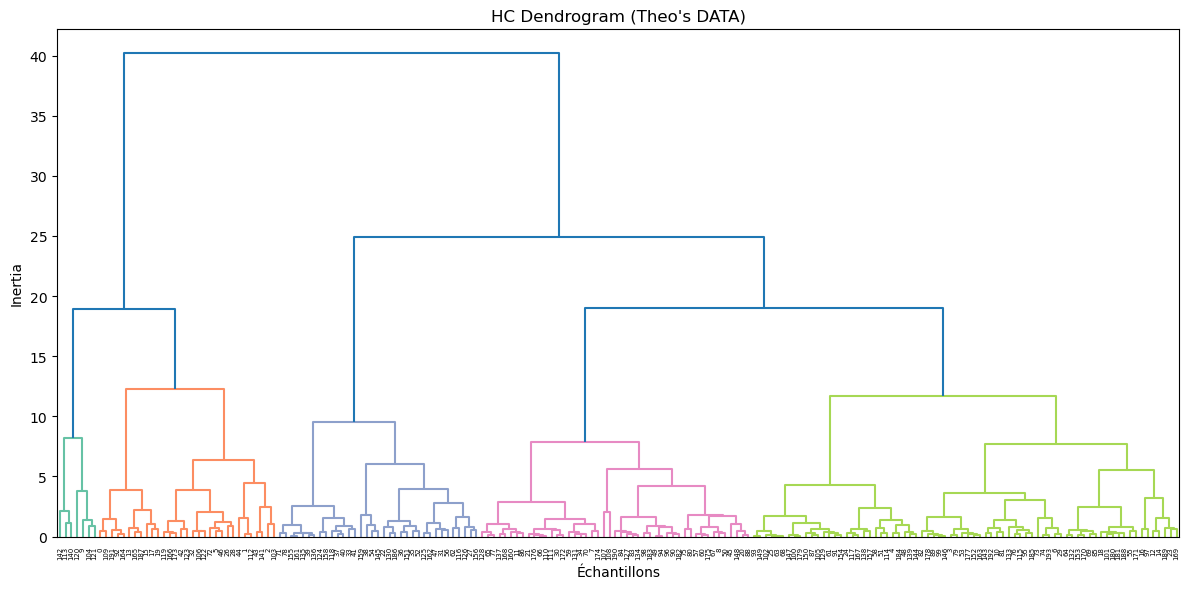

In [426]:
# Use the same colormap and number of clusters as before
cmap = cm.get_cmap('Set2')
hex_colors = [to_hex(cmap(i)) for i in range(n_clust)]
set_link_color_palette(hex_colors)

plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=Z[-n_clust+1, 2], labels=transformed_WT_pooled.index.to_list(), leaf_rotation=90, )
plt.title("HC Dendrogram (Theo's DATA)")
plt.xlabel("Échantillons")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "05_HC_Dendrogram.pdf"))

### 2.A.c Biplot PCA
A biplot is used here to visualize both the samples and the variable loadings in the principal component space. This allows us to interpret how each original feature contributes to the first two principal components and to see the relationships between variables and samples simultaneously. By plotting the variable vectors, we can identify which features are most influential in separating the data, and how clusters or trends in the data relate to specific experimental measurements. This enhances the interpretability of the PCA results and helps link biological meaning to the observed patterns.


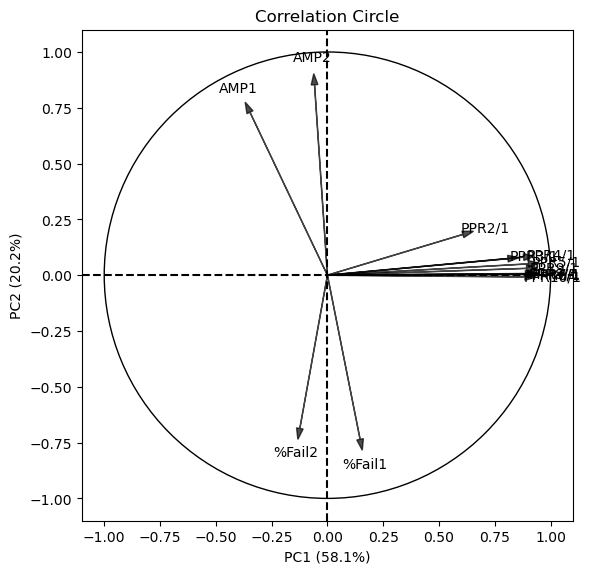

In [427]:
# PCA biplot: Visualize variable contributions to PC1 and PC2
# This uses the PCA object 'reducer' and its components_
# Update biplot to use correlation coefficients instead of loadings
# Get correlation coefficients between PCs and original variables
corr_coef = coeff_corr.T.values
scaling_factor = 1
corr_coef_scaled = corr_coef * scaling_factor

# Create the circle for correlation biplot
circle = plt.Circle((0, 0), 1, color='black', fill=False)
plt.figure(figsize=(6,6))
plt.axhline(0, color='black', linestyle='dashed')
plt.axvline(0, color='black', linestyle='dashed')
plt.gca().add_artist(circle)

# Plot correlation vectors
for i, var in enumerate(df_WT_pooled.columns):
    plt.arrow(0, 0, corr_coef_scaled[i, 0], corr_coef_scaled[i, 1],
              color='black', alpha=0.7, head_width=0.03, head_length=0.05, length_includes_head=True)
    plt.text(corr_coef_scaled[i, 0]*1.08, corr_coef_scaled[i, 1]*1.08, var, ha='center', va='center')

plt.xlabel(f"PC1 ({reducer_PCA.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({reducer_PCA.explained_variance_ratio_[1]*100:.1f}%)")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal')
plt.title('Correlation Circle')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "06_correlation_circle.pdf"))
plt.show()

### 2.A.d CONTROL - WT Anthime projection on PCA
To ensure that Anthime's data is well represented among the PCA.

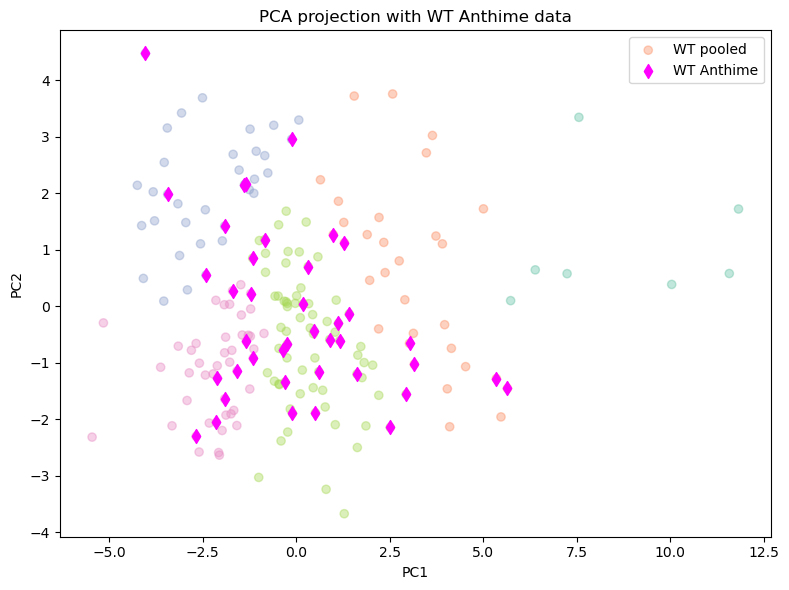

In [428]:
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
plt.scatter(transformed_WT_Anthime['PC1'], transformed_WT_Anthime['PC2'], marker='d', s=50, c='magenta', label='WT Anthime')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection with WT Anthime data')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "07_PCA_WT_Anthime.pdf"))
plt.show()

### 2.A.e BONUS #1 - PCA with PC/IN projected

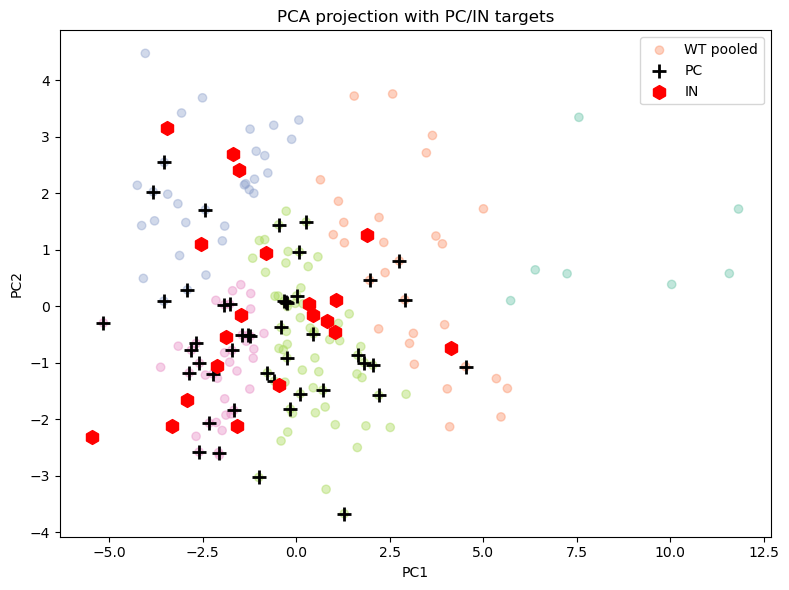

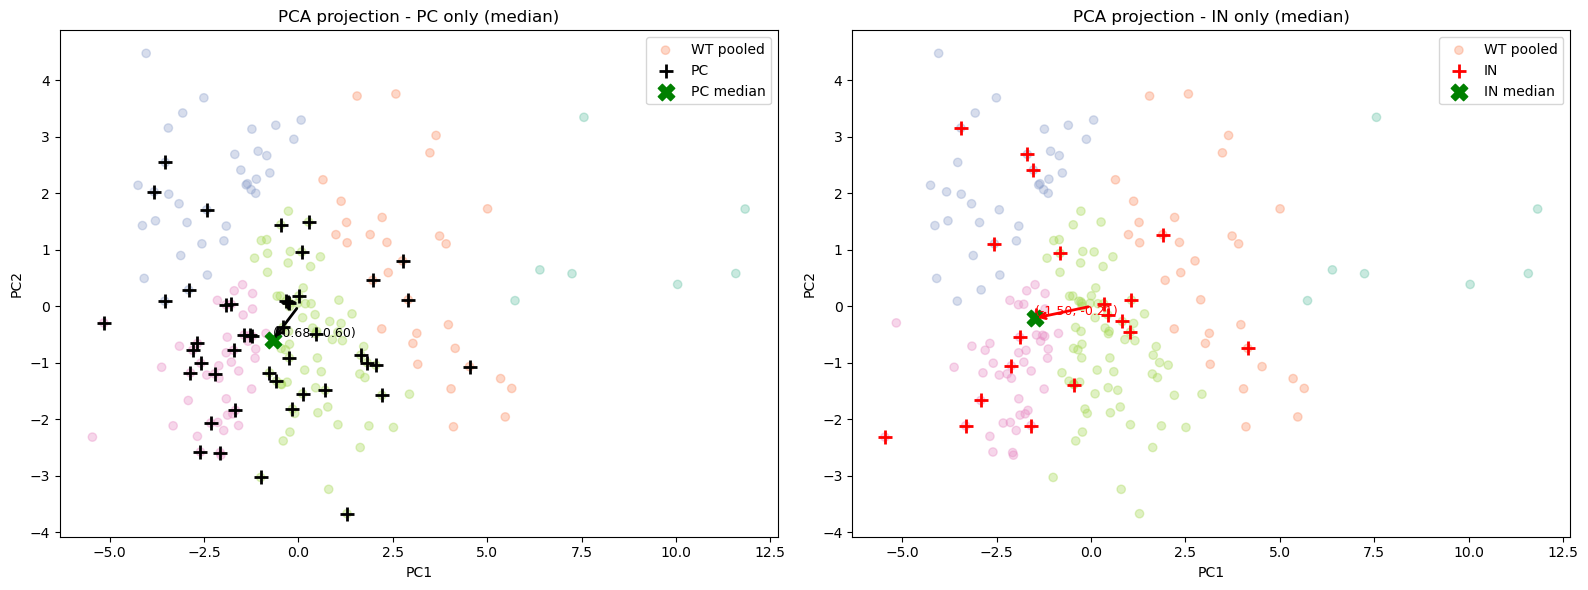

In [429]:
# Reload full WT_Theo only if Target column is missing (it was dropped earlier)
if 'Target' not in locals().get('df_WT_Theo', pd.DataFrame()).columns:
    df_WT_Theo_full = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="WT_Theo")
else:
    df_WT_Theo_full = df_WT_Theo  # already present with Target

# Filter PC / IN
pc_data = df_WT_Theo_full[df_WT_Theo_full['Target'] == 'PC']
in_data = df_WT_Theo_full[df_WT_Theo_full['Target'] == 'IN']

pc_indices = pc_data.index
in_indices = in_data.index

# Use existing PCA-transformed data (numpy array)
pc_transformed = transformed_data_WT_Theo[pc_indices]
in_transformed = transformed_data_WT_Theo[in_indices]

# Medians (coordinate-wise)
pc_median = np.median(pc_transformed, axis=0)
in_median = np.median(in_transformed, axis=0)

# Combined plot
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
plt.scatter(pc_transformed[:, 0], pc_transformed[:, 1], marker='+', s=100, c='black', linewidths=2, label='PC')
plt.scatter(in_transformed[:, 0], in_transformed[:, 1], marker='h', s=100, c='red', label='IN')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection with PC/IN targets')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "08_PCA_PC_IN.pdf"))
plt.show()

# Separate plots with medians + vectors (origin -> median)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PC only
ax1.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.35, label='WT pooled')
ax1.scatter(pc_transformed[:, 0], pc_transformed[:, 1], marker='+', s=100, c='black', linewidths=2, label='PC')
ax1.scatter(pc_median[0], pc_median[1], c='green', marker='X', s=140, label='PC median')
ax1.annotate('', xy=pc_median, xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax1.text(pc_median[0], pc_median[1],
         f'({pc_median[0]:.2f}, {pc_median[1]:.2f})',
         color='black', ha='left', va='bottom', fontsize=9)
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.set_title('PCA projection - PC only (median)')
ax1.legend()

# IN only
ax2.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.35, label='WT pooled')
ax2.scatter(in_transformed[:, 0], in_transformed[:, 1], marker='+', s=100, c='red', linewidths=2, label='IN')
ax2.scatter(in_median[0], in_median[1], c='green', marker='X', s=140, label='IN median')
ax2.annotate('', xy=in_median, xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax2.text(in_median[0], in_median[1],
         f'({in_median[0]:.2f}, {in_median[1]:.2f})',
         color='red', ha='left', va='bottom', fontsize=9)
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.set_title('PCA projection - IN only (median)')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "09_PCA_PC_IN_separate_with_medians.pdf"))
plt.show()


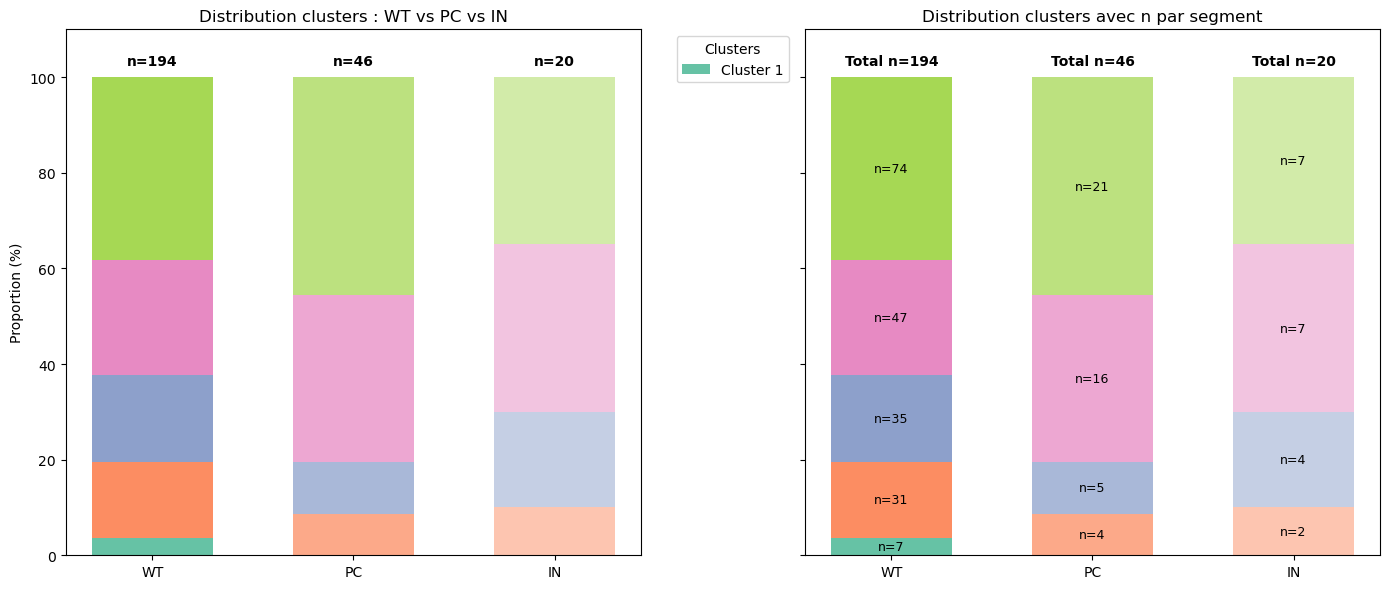

In [430]:
# --- New figure: WT vs PC vs IN (normalized stacked bar) + duplicate with per-cluster n inside segments ---

def assign_clusters_robust(X_existing, labels_existing, X_new, method='centroid'):
    unique_labels = np.unique(labels_existing)
    assigned_labels = []

    if method == 'centroid':
        # Compute centroids of existing clusters
        centroids = np.array([X_existing[labels_existing == label].mean(axis=0) for label in unique_labels])
        # Assign each new point to the nearest centroid
        distances = cdist(X_new, centroids)
        assigned_labels = unique_labels[np.argmin(distances, axis=1)]

    elif method == 'single':
        for x in X_new:
            min_dist = float('inf')
            best_label = None
            for label in unique_labels:
                cluster_points = X_existing[labels_existing == label]
                dist = np.min(cdist([x], cluster_points))
                if dist < min_dist:
                    min_dist = dist
                    best_label = label
            assigned_labels.append(best_label)

    elif method == 'average':
        for x in X_new:
            best_label = None
            best_dist = float('inf')
            for label in unique_labels:
                cluster_points = X_existing[labels_existing == label]
                dist = np.mean(cdist([x], cluster_points))
                if dist < best_dist:
                    best_dist = dist
                    best_label = label
            assigned_labels.append(best_label)

    return np.array(assigned_labels)

# Attribution des clusters (robuste) si pas déjà fait dans cette session
clusters_PC = assign_clusters_robust(transformed_data_WT_pooled, hc_labels, pc_transformed, method='single')
clusters_IN = assign_clusters_robust(transformed_data_WT_pooled, hc_labels, in_transformed, method='single')

all_clusters_range = range(1, n_clust + 1)


wt_counts = pd.Series(hc_labels).value_counts().sort_index()
wt_counts = pd.DataFrame({
    'Cluster': wt_counts.index,
    'Count': wt_counts.values,
    'Percentage': 100 * wt_counts.values / len(hc_labels),
    'Dataset': 'WT'
})

# Comptages PC
pc_counts_series = pd.Series(clusters_PC).value_counts()
pc_counts = pd.DataFrame({
    'Cluster': list(all_clusters_range),
    'Count'  : [pc_counts_series.get(c, 0) for c in all_clusters_range],
    'Percentage': [100 * pc_counts_series.get(c, 0) / len(clusters_PC) for c in all_clusters_range],
    'Dataset': 'PC'
})
# Comptages IN
in_counts_series = pd.Series(clusters_IN).value_counts()
in_counts = pd.DataFrame({
    'Cluster': list(all_clusters_range),
    'Count'  : [in_counts_series.get(c, 0) for c in all_clusters_range],
    'Percentage': [100 * in_counts_series.get(c, 0) / len(clusters_IN) for c in all_clusters_range],
    'Dataset': 'IN'
})

# Ordre cohérent
wt_sorted = wt_counts.sort_values('Cluster')
pc_sorted = pc_counts.sort_values('Cluster')
in_sorted = in_counts.sort_values('Cluster')

wt_props = wt_sorted['Percentage'].values
pc_props = pc_sorted['Percentage'].values
in_props = in_sorted['Percentage'].values

wt_counts_vals = wt_sorted['Count'].values
pc_counts_vals = pc_sorted['Count'].values
in_counts_vals = in_sorted['Count'].values

bar_width = 0.6
x_positions = [0, 1, 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --------- Sous-figure 1 : identique à l'original ---------
ax1 = axes[0]
bottoms1 = [0, 0, 0]
for i in range(n_clust):
    color = cmap(i)
    ax1.bar(x_positions[0], wt_props[i], bar_width, bottom=bottoms1[0], color=color,
            label=f'Cluster {i+1}' if i == 0 else None)
    bottoms1[0] += wt_props[i]
    ax1.bar(x_positions[1], pc_props[i], bar_width, bottom=bottoms1[1], color=color, alpha=0.75)
    bottoms1[1] += pc_props[i]
    ax1.bar(x_positions[2], in_props[i], bar_width, bottom=bottoms1[2], color=color, alpha=0.5)
    bottoms1[2] += in_props[i]

ax1.text(x_positions[0], 102, f"n={wt_counts_vals.sum()}", ha='center', va='bottom', fontweight='bold')
ax1.text(x_positions[1], 102, f"n={pc_counts_vals.sum()}", ha='center', va='bottom', fontweight='bold')
ax1.text(x_positions[2], 102, f"n={in_counts_vals.sum()}", ha='center', va='bottom', fontweight='bold')

ax1.set_ylabel('Proportion (%)')
ax1.set_title('Distribution clusters : WT vs PC vs IN')
ax1.set_xticks(x_positions)
ax1.set_xticklabels(['WT', 'PC', 'IN'])
ax1.set_ylim(0, 110)
ax1.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

# --------- Sous-figure 2 : mêmes barres + n de chaque segment ---------
ax2 = axes[1]
bottoms2 = [0, 0, 0]

def luminance(rgb):
    r, g, b = rgb[:3]
    return 0.2126*r + 0.7152*g + 0.0722*b

for i in range(n_clust):
    color = cmap(i)
    # WT
    h_wt = wt_props[i]
    ax2.bar(x_positions[0], h_wt, bar_width, bottom=bottoms2[0], color=color)
    if h_wt > 0:
        y_text = bottoms2[0] + h_wt / 2
        txt_color = 'white' if luminance(color) < 0.55 else 'black'
        ax2.text(x_positions[0], y_text, f"n={wt_counts_vals[i]}", ha='center', va='center',
                 fontsize=9, color=txt_color)
    bottoms2[0] += h_wt
    # PC
    h_pc = pc_props[i]
    ax2.bar(x_positions[1], h_pc, bar_width, bottom=bottoms2[1], color=color, alpha=0.75)
    if h_pc > 0:
        y_text = bottoms2[1] + h_pc / 2
        txt_color = 'white' if luminance(color) < 0.55 else 'black'
        ax2.text(x_positions[1], y_text, f"n={pc_counts_vals[i]}", ha='center', va='center',
                 fontsize=9, color=txt_color)
    bottoms2[1] += h_pc
    # IN
    h_in = in_props[i]
    ax2.bar(x_positions[2], h_in, bar_width, bottom=bottoms2[2], color=color, alpha=0.5)
    if h_in > 0:
        y_text = bottoms2[2] + h_in / 2
        txt_color = 'white' if luminance(color) < 0.55 else 'black'
        ax2.text(x_positions[2], y_text, f"n={in_counts_vals[i]}", ha='center', va='center',
                 fontsize=9, color=txt_color)
    bottoms2[2] += h_in

# Totaux en haut
ax2.text(x_positions[0], 102, f"Total n={wt_counts_vals.sum()}", ha='center', va='bottom', fontweight='bold')
ax2.text(x_positions[1], 102, f"Total n={pc_counts_vals.sum()}", ha='center', va='bottom', fontweight='bold')
ax2.text(x_positions[2], 102, f"Total n={in_counts_vals.sum()}", ha='center', va='bottom', fontweight='bold')

ax2.set_title('Distribution clusters avec n par segment')
ax2.set_xticks(x_positions)
ax2.set_xticklabels(['WT', 'PC', 'IN'])
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "10_stacked_bar_WT_PC_IN_normalized_side_by_side_counts.pdf"))
plt.show()


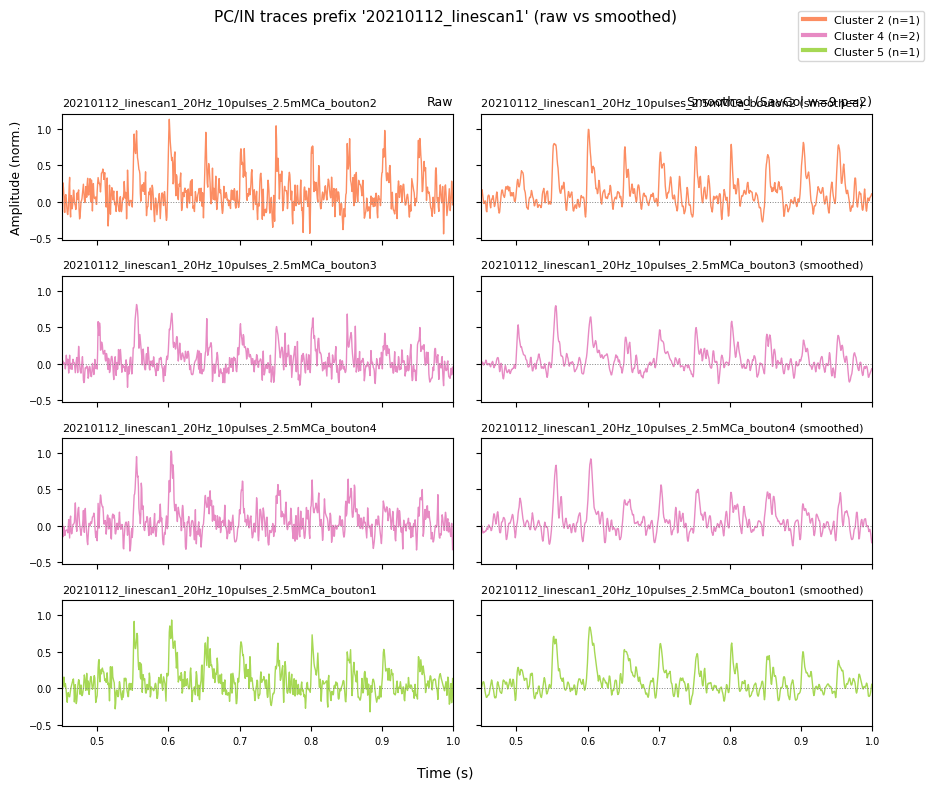

Figure saved: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\10_B_traces_20210112_linescan1_raw_vs_smooth.pdf
Cluster summary: {2: 1, 4: 2, 5: 1}


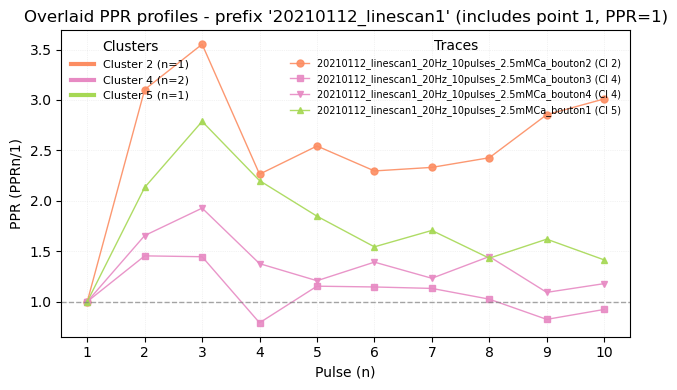

Overlaid PPR figure saved: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\10_B_traces_20210112_linescan1_PPR_profiles_overlaid.pdf


In [431]:
from scipy.signal import savgol_filter

# Plot selected traces in two columns: raw (col 1) and Savitzky-Golay smoothed (col 2)
prefix = "20210112_linescan1"

if 'df_WT_Theo_full' not in globals():
    df_WT_Theo_full = pd.read_excel(
        r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx",
        sheet_name="WT_Theo"
    )
if 'test_wt_theo' not in globals():
    test_wt_theo = pd.read_excel(
        r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx',
        sheet_name="WT_Theo"
    )

missing_vars = [v for v in ['pc_indices', 'in_indices', 'clusters_PC', 'clusters_IN'] if v not in globals()]
if missing_vars:
    raise RuntimeError(f"Missing variables (run the PC/IN cell first): {missing_vars}")

pc_map = pd.DataFrame({
    'Index': pc_indices,
    'ID': df_WT_Theo_full.loc[pc_indices, 'ID'].values,
    'Target': 'PC',
    'Cluster': clusters_PC
})
in_map = pd.DataFrame({
    'Index': in_indices,
    'ID': df_WT_Theo_full.loc[in_indices, 'ID'].values,
    'Target': 'IN',
    'Cluster': clusters_IN
})
id_cluster_df = pd.concat([pc_map, in_map], ignore_index=True)

selected = id_cluster_df[id_cluster_df['ID'].str.startswith(prefix)]
if selected.empty:
    print(f"No ID starting with '{prefix}' among PC/IN.")
else:
    time_vec = test_wt_theo.iloc[1:, 0].astype(float).values
    cmap_local = cm.get_cmap('Set2')
    cluster_colors = {c: cmap_local(c-1) for c in sorted(selected['Cluster'].unique())}

    trace_data = []
    all_vals = []
    for _, row in selected.iterrows():
        trace_id = row['ID']
        if trace_id in test_wt_theo.columns:
            vals = test_wt_theo.loc[1:, trace_id].astype(float).values
            trace_data.append((row['Cluster'], trace_id, vals))
            all_vals.append(vals)
    if not trace_data:
        print("No matching columns found in the trace file.")
    else:
        all_vals = np.concatenate(all_vals)
        y_min = np.nanmin(all_vals)
        y_max = np.nanmax(all_vals)
        y_pad = 0.05 * (y_max - y_min)
        y_min_plot = y_min - y_pad
        y_max_plot = y_max + y_pad

        n_traces = len(trace_data)
        ncols = 2  # raw + smoothed
        nrows = n_traces

        # Ensure savgol_filter is available
        try:
            savgol_filter
        except NameError:
            raise ImportError("savgol_filter not found. Make sure scipy is installed and imported.")

        fig_height = max(2.0, min(2.0 * n_traces, 40))
        fig, axes = plt.subplots(nrows, ncols, figsize=(10, fig_height), sharex=True, sharey=True)
        if nrows == 1:
            axes = np.atleast_2d(axes)

        counts_per_cluster = {}
        for r, (cl, trace_id, vals) in enumerate(trace_data):
            color = cluster_colors[cl]

            # Column 1: raw trace
            ax_raw = axes[r, 0]
            ax_raw.plot(time_vec, vals, color=color, lw=1.0)
            ax_raw.axhline(0, color='gray', ls='dotted', lw=0.7)
            ax_raw.set_xlim(0.45, 1.0)
            ax_raw.set_ylim(y_min_plot, y_max_plot)
            ax_raw.set_title(trace_id, fontsize=8, loc='left')
            ax_raw.tick_params(labelsize=7)

            # Column 2: smoothed trace
            ax_smooth = axes[r, 1]
            win = 9
            if len(vals) < win:
                # Adjust window (odd >=3)
                win = len(vals) if len(vals) % 2 == 1 else len(vals) - 1
                if win < 3:
                    smooth_vals = vals.copy()
                else:
                    smooth_vals = savgol_filter(vals, win, 2, mode='interp')
            else:
                smooth_vals = savgol_filter(vals, 9, 2, mode='interp')
            ax_smooth.plot(time_vec, smooth_vals, color=color, lw=1.0)
            ax_smooth.axhline(0, color='gray', ls='dotted', lw=0.7)
            ax_smooth.set_xlim(0.45, 1.0)
            ax_smooth.set_ylim(y_min_plot, y_max_plot)
            ax_smooth.set_title(f"{trace_id} (smoothed)", fontsize=8, loc='left')
            ax_smooth.tick_params(labelsize=7)

            counts_per_cluster[cl] = counts_per_cluster.get(cl, 0) + 1

        # Column headers
        axes[0, 0].set_ylabel('Amplitude (norm.)', fontsize=9)
        axes[0, 0].set_title("Raw", fontsize=9, loc='right')
        axes[0, 1].set_title("Smoothed (SavGol w=9 p=2)", fontsize=9, loc='right')

        fig.suptitle(f"PC/IN traces prefix '{prefix}' (raw vs smoothed)", fontsize=11)
        fig.text(0.5, 0.02, 'Time (s)', ha='center')

        legend_handles = [
            plt.Line2D([0], [0], color=cluster_colors[c], lw=3,
                       label=f'Cluster {c} (n={counts_per_cluster.get(c,0)})')
            for c in sorted(counts_per_cluster.keys())
        ]
        fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.985, 0.985), fontsize=8)

        plt.tight_layout(rect=[0.05, 0.04, 0.95, 0.93])
        out_path = os.path.join(output_dir, f"10_B_traces_{prefix}_raw_vs_smooth.pdf")
        plt.savefig(out_path)
        plt.show()
        print(f"Figure saved: {out_path}")
        print("Cluster summary:", counts_per_cluster)

        # --- Figure 2 (modified): All PPR traces (PPRn/1) overlaid in one plot ---
        ppr_cols = [f"PPR{i}/1" for i in range(2, 11)]
        ppr_existing = [c for c in ppr_cols if c in df_WT_Theo_full.columns]

        if not ppr_existing:
            print("PPR columns absent in df_WT_Theo_full -> PPR figure not generated.")
        else:
            ppr_traces = []
            for _, row in selected.iterrows():
                trace_id = row['ID']
                row_df = df_WT_Theo_full[df_WT_Theo_full['ID'] == trace_id]
                if row_df.empty:
                    continue
                vals_ppr = row_df.iloc[0][ppr_existing].values
                try:
                    vals_ppr = vals_ppr.astype(float)
                except Exception:
                    vals_ppr = np.array([np.nan] * len(ppr_existing))
                ppr_traces.append((row['Cluster'], trace_id, vals_ppr))

            if not ppr_traces:
                print("No corresponding PPR data found for selected IDs.")
            else:
                # Pulses extracted from column names (PPR2/1 -> 2 ... 10)
                x_ppr = [int(c.split('PPR')[1].split('/')[0]) for c in ppr_existing]

                # Add artificial point (pulse=1, PPR=1) at start of each trace
                x_ppr_full = [1] + x_ppr  # becomes 1..10
                fig_ppr, ax = plt.subplots(figsize=(6.5, 4))
                counts_cl = {}

                # Global limits (including added value 1)
                all_vals = np.concatenate(
                    [np.concatenate(([1.0], vp)) for _, _, vp in ppr_traces if vp.size]
                )
                finite_vals = all_vals[np.isfinite(all_vals)]
                if finite_vals.size:
                    ppr_ymin = np.nanmin(finite_vals)
                    ppr_ymax = np.nanmax(finite_vals)
                else:
                    ppr_ymin, ppr_ymax = 0.0, 1.0
                margin = 0.05 * (ppr_ymax - ppr_ymin if ppr_ymax > ppr_ymin else 1)
                ppr_ymin_plot = ppr_ymin - margin
                ppr_ymax_plot = ppr_ymax + margin

                marker_cycle = ['o', 's', 'v', '^', 'D', 'P', 'X']
                for i, (cl, trace_id, pvals) in enumerate(ppr_traces):
                    color = cluster_colors.get(cl, (0.3, 0.3, 0.3))
                    marker = marker_cycle[i % len(marker_cycle)]
                    pvals_full = np.concatenate(([1.0], pvals))  # prepend PPR1/1 = 1
                    ax.plot(
                        x_ppr_full,
                        pvals_full,
                        marker=marker,
                        ms=5,
                        lw=1.0,
                        alpha=0.9,
                        color=color,
                        label=f"{trace_id} (Cl {cl})"
                    )
                    counts_cl[cl] = counts_cl.get(cl, 0) + 1

                # Horizontal line y = 1 (PPR = 1)
                ax.axhline(1.0, color='gray', ls='--', lw=1.0, alpha=0.7)

                ax.set_xticks(x_ppr_full)
                ax.set_xlabel('Pulse (n)')
                ax.set_ylabel('PPR (PPRn/1)')
                ax.set_ylim(ppr_ymin_plot, ppr_ymax_plot)
                ax.grid(alpha=0.3, linestyle=':', linewidth=0.5)
                ax.set_title(f"Overlaid PPR profiles - prefix '{prefix}' (includes point 1, PPR=1)")

                # Cluster legend (summary)
                cluster_handles = [
                    plt.Line2D([0], [0], color=cluster_colors[c], lw=3,
                               label=f'Cluster {c} (n={counts_cl.get(c,0)})')
                    for c in sorted(counts_cl.keys())
                ]
                leg1 = ax.legend(handles=cluster_handles, loc='upper left', fontsize=8, frameon=False, title="Clusters")
                ax.add_artist(leg1)

                # ID legend (if few)
                if len(ppr_traces) <= 12:
                    ax.legend(loc='upper right', fontsize=7, frameon=False, title="Traces")

                plt.tight_layout()
                out_ppr = os.path.join(output_dir, f"10_B_traces_{prefix}_PPR_profiles_overlaid.pdf")
                fig_ppr.savefig(out_ppr)
                plt.show()
                print(f"Overlaid PPR figure saved: {out_ppr}")

### 2.A.f BONUS #2- Big amplitude boutons
Here are projected the WT boutons that show a bigger than the biggest Amp1 bouton of SynII.

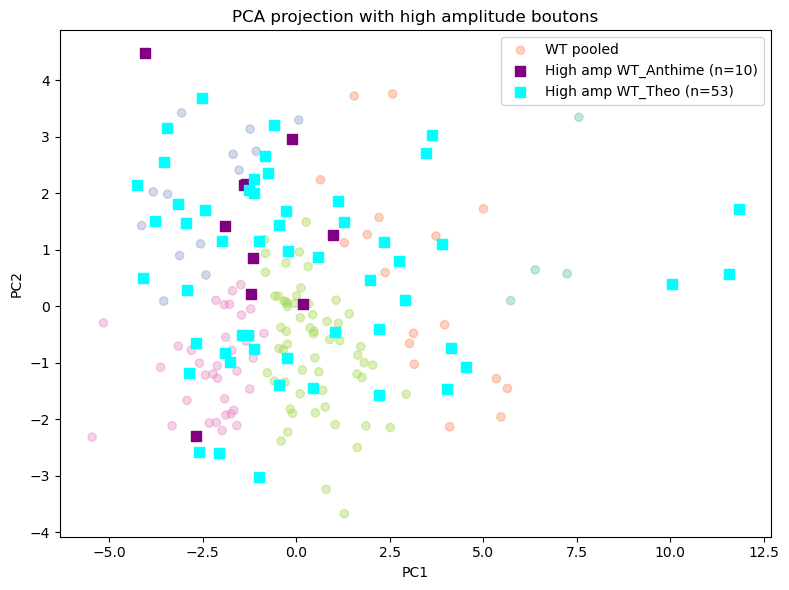

Nombre total de boutons haute amplitude projetés: 63
WT_Anthime: 10 boutons
WT_Theo: 53 boutons


In [432]:
# Get the list of red traces (high amplitude traces) from both WT datasets
red_traces_combined = red_traces_anthime + red_traces_theo

# Extract the corresponding data points from the transformed datasets
high_amp_indices_anthime = []
high_amp_indices_theo = []

# For WT_Anthime - find indices of red traces
for trace_id in red_traces_anthime:
    # Find the column index in the original dataset (subtract 1 because first column is time)
    col_index = list(test_wt_anthime.columns).index(trace_id) - 1
    if col_index >= 0:
        high_amp_indices_anthime.append(col_index)

# For WT_Theo - find indices of red traces  
for trace_id in red_traces_theo:
    # Find the column index in the original dataset (subtract 1 because first column is time)
    col_index = list(test_wt_theo.columns).index(trace_id) - 1
    if col_index >= 0:
        high_amp_indices_theo.append(col_index)

# Extract the corresponding transformed data points
high_amp_anthime_transformed = transformed_data_WT_Anthime[high_amp_indices_anthime]
high_amp_theo_transformed = transformed_data_WT_Theo[high_amp_indices_theo]

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
plt.scatter(high_amp_anthime_transformed[:, 0], high_amp_anthime_transformed[:, 1], 
           marker='s', s=50, c='purple', label=f'High amp WT_Anthime (n={len(high_amp_anthime_transformed)})')
plt.scatter(high_amp_theo_transformed[:, 0], high_amp_theo_transformed[:, 1], 
           marker='s', s=50, c='cyan', label=f'High amp WT_Theo (n={len(high_amp_theo_transformed)})')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection with high amplitude boutons')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Nombre total de boutons haute amplitude projetés: {len(high_amp_anthime_transformed) + len(high_amp_theo_transformed)}")
print(f"WT_Anthime: {len(high_amp_anthime_transformed)} boutons")
print(f"WT_Theo: {len(high_amp_theo_transformed)} boutons")

## 2.B - Average profile by classes

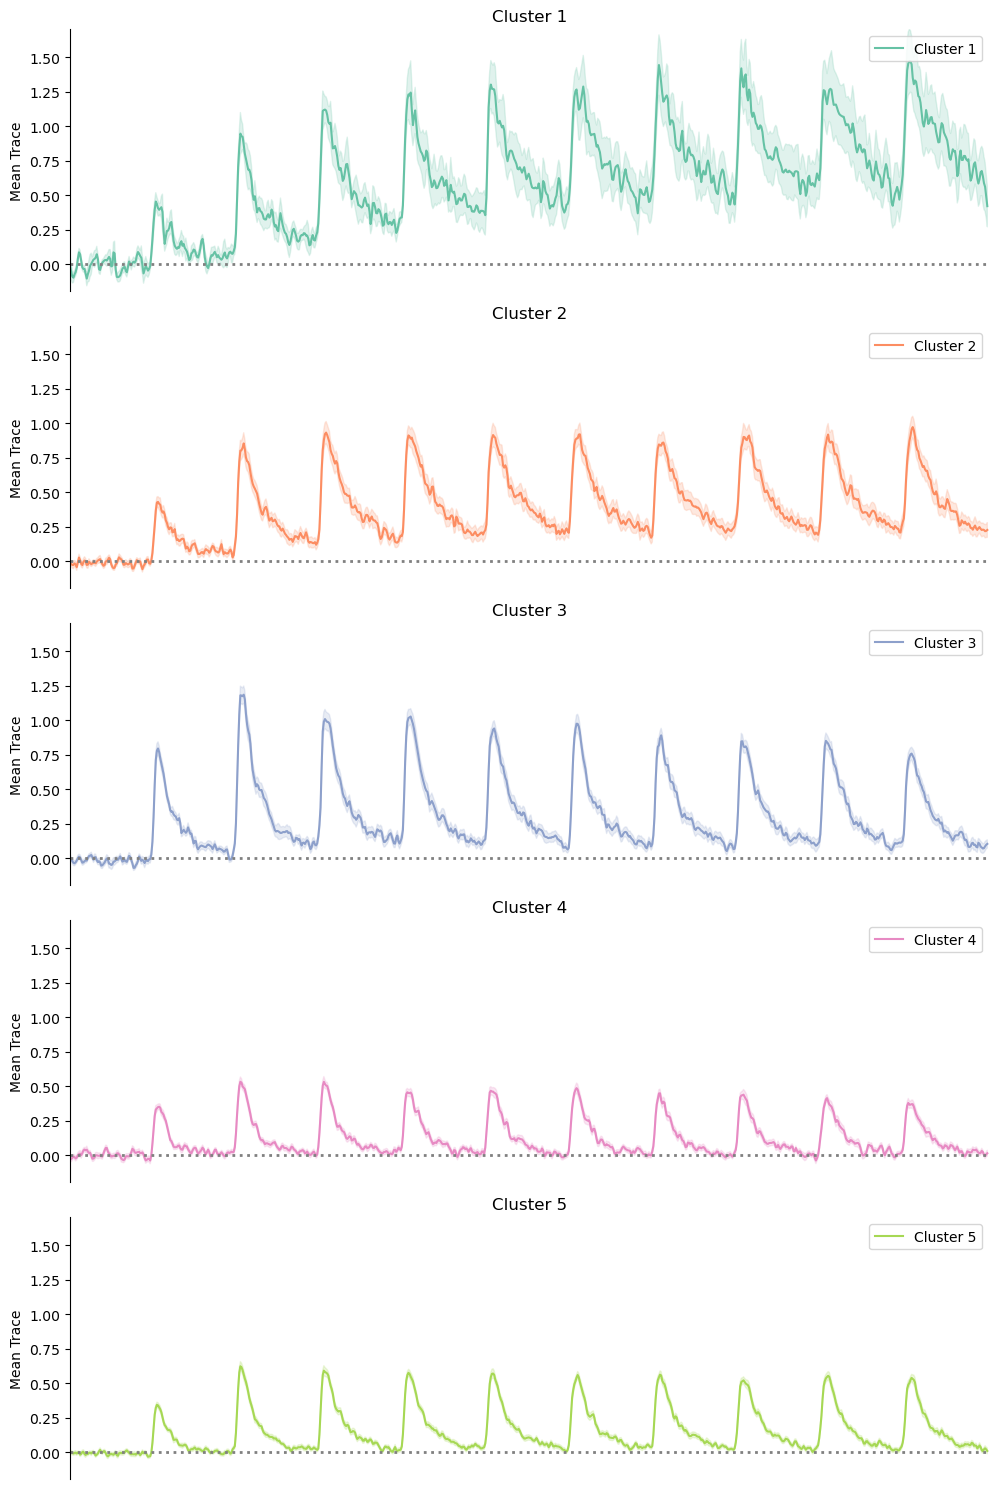

In [433]:
test  = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name=3)

# Extract time from the first column (ignoring the first row if it's an ID)
time = test.iloc[1:, 0].values
trace_ids = test.columns[1:]

# Associate each ID to its cluster via df_WT_poolclust
id_to_cluster = dict(zip(df_WT_poolclust['ID'], df_WT_poolclust['HC_UMAP']))
clusters = sorted(set(id_to_cluster.values()))
cmap = cm.get_cmap('Set2')

# Calculate global y-axis limits across all clusters
all_mean_traces = []
all_sem_traces = []
for cluster in clusters:
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    if len(cluster_ids) > 0:
        traces = test.loc[1:, cluster_ids].astype(float).values
        mean_trace = np.mean(traces, axis=1)
        sem_trace = np.std(traces, axis=1) / np.sqrt(traces.shape[1])
        all_mean_traces.extend(mean_trace)
        all_sem_traces.extend(sem_trace)

# Calculate global y-limits
global_min = np.min(np.array(all_mean_traces) - np.array(all_sem_traces))
global_max = np.max(np.array(all_mean_traces) + np.array(all_sem_traces))

# Create a figure with one subplot per cluster
fig, axes = plt.subplots(len(clusters), 1, figsize=(10, 3*len(clusters)), sharex=True)

# Verification of IDs associated with each cluster
for cluster in sorted(set(id_to_cluster.values())):
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    #print(f"Cluster {cluster}: {cluster_ids}")

plotted = False
for idx, cluster in enumerate(clusters):
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    if len(cluster_ids) > 0:
        traces = test.loc[1:, cluster_ids].astype(float).values
        mean_trace = np.mean(traces, axis=1)
        sem_trace = np.std(traces, axis=1) / np.sqrt(traces.shape[1])
        color = cmap(idx)
        axes[idx].plot(time, mean_trace, color=color, label=f'Cluster {cluster}')
        axes[idx].fill_between(time, mean_trace-sem_trace, mean_trace+sem_trace, color=color, alpha=0.2)
        axes[idx].axhline(0, color='gray', linestyle='dotted', linewidth=2)
        axes[idx].set_ylabel('Mean Trace')
        axes[idx].set_xlim(0.45, 1.0)
        axes[idx].legend(loc='upper right')
        axes[idx].set_title(f'Cluster {cluster}')
        
        # Set consistent y-axis limits for all subplots
        axes[idx].set_ylim(global_min, global_max)
        
        # Remove frame and x-axis
        axes[idx].spines['top'].set_visible(False)
        axes[idx].spines['right'].set_visible(False)
        axes[idx].spines['bottom'].set_visible(False)
        axes[idx].get_xaxis().set_visible(False)
        
        plotted = True
    else:
        axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "11_Traces_clust.pdf"))
if plotted:
    plt.show()
else:
    print('No traces found for any cluster.')



## 2.C - Release properties
Here are ploted the different properties of each classes of boutons.

### 2.C.a PPR profiles

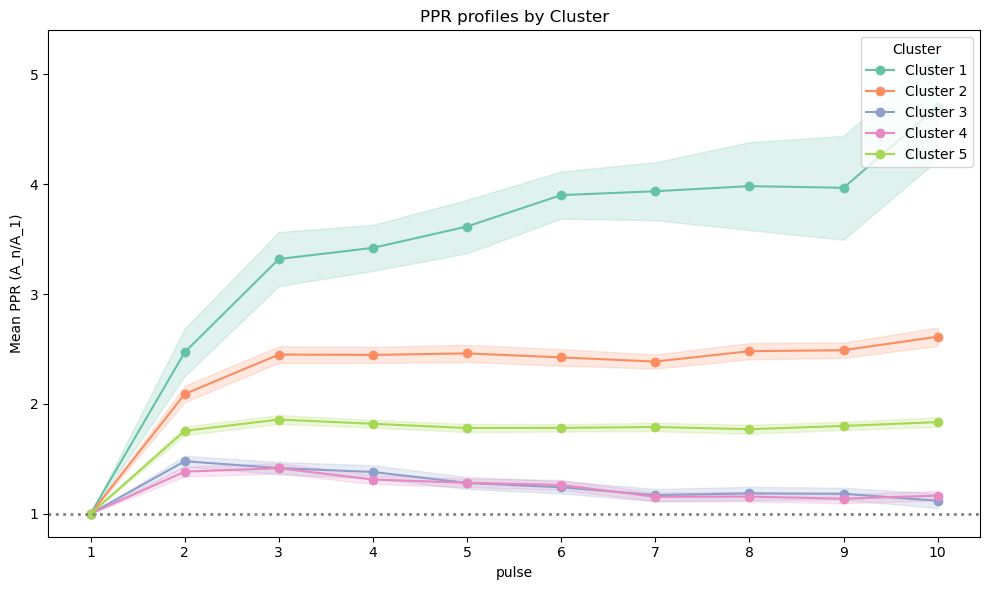

In [434]:
# Plot PPR profiles for each cluster with SEM and custom x-axis, using consistent Set2 colors
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_WT_poolclust.columns]
x_pulses = list(range(1, len(ppr_cols)+2))  # 1 to 10
clusters = sorted(df_WT_poolclust['HC_UMAP'].unique())
cmap = cm.get_cmap('Set2')
plt.figure(figsize=(10, 6))
for idx, cluster in enumerate(clusters):
    cluster_data = df_WT_poolclust[df_WT_poolclust['HC_UMAP'] == cluster]
    means = [1] + cluster_data[ppr_cols].mean().tolist()  # pulse 1 is always 1
    sems = [0] + cluster_data[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0
    color = cmap(idx)
    plt.plot(x_pulses, means, marker='o', label=f'Cluster {cluster}', color=color)
    plt.fill_between(x_pulses, np.array(means)-np.array(sems), np.array(means)+np.array(sems), alpha=0.2, color=color)
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('Mean PPR (A_n/A_1)')
plt.xlabel('pulse')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.title('PPR profiles by Cluster')
plt.legend(title='Cluster', loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "12_WT_clust_PPR_profiles.pdf"))
plt.show()

### 2.C.b PPR2 (A2/A1)

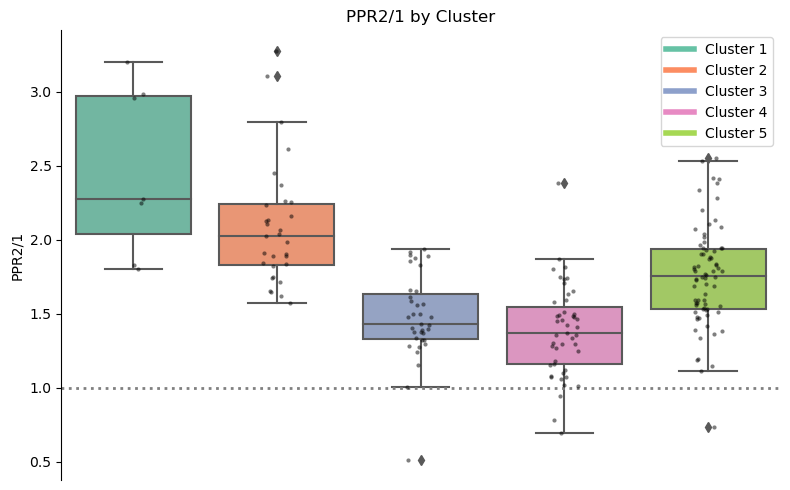

Tests sauvegardés dans: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\13_WT_clust_PPR2_1_stats.txt


In [435]:
from scipy.stats import mannwhitneyu, kruskal
import itertools

# Boxplot PPR2/1 par cluster (sans barres de significativité) + sauvegarde des tests

plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='PPR2/1', data=df_WT_poolclust, palette='Set2')
sns.stripplot(x='HC_UMAP', y='PPR2/1', data=df_WT_poolclust, color='k', size=3, alpha=0.5, ax=ax)
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('PPR2/1')
plt.title('PPR2/1 by Cluster')

# Nettoyage axes / cadre
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)

# Légende clusters
n_cl = df_WT_poolclust['HC_UMAP'].nunique()
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(n_cl)]
labels = [f'Cluster {i+1}' for i in range(n_cl)]
plt.legend(handles, labels, loc='upper right')

# ------------------ Tests statistiques (sans affichage) ------------------
clusters = sorted(df_WT_poolclust['HC_UMAP'].unique())
data_per_cluster = {
    c: df_WT_poolclust.loc[df_WT_poolclust['HC_UMAP'] == c, 'PPR2/1'].dropna().values
    for c in clusters
}

# Test global Kruskal-Wallis
kw_stat, kw_p = kruskal(*data_per_cluster.values())

# Tests pairwise Mann-Whitney (bilatéral) + Bonferroni
pairs = list(itertools.combinations(clusters, 2))
results = []
for a, b in pairs:
    x = data_per_cluster[a]
    y = data_per_cluster[b]
    try:
        stat, p = mannwhitneyu(x, y, alternative='two-sided')
    except ValueError:
        stat, p = float('nan'), float('nan')
    results.append({
        'C_A': a,
        'C_B': b,
        'n_A': len(x),
        'n_B': len(y),
        'U_stat': stat,
        'p_raw': p
    })

m = len(results)
for r in results:
    if np.isnan(r['p_raw']):
        r['p_corr'] = np.nan
    else:
        r['p_corr'] = min(r['p_raw'] * m, 1.0)

results.sort(key=lambda d: (d['p_corr'] if not np.isnan(d['p_corr']) else 1))

stats_path = os.path.join(output_dir, "13_WT_clust_PPR2_1_stats.txt")
with open(stats_path, "w", encoding="utf-8") as f:
    f.write("PPR2/1 - Analyses statistiques par cluster\n")
    f.write(f"Test global Kruskal-Wallis: H = {kw_stat:.4f}, p = {kw_p:.6g}\n")
    f.write(f"Nombre de comparaisons (Bonferroni): {m}\n\n")
    f.write("Comparaisons pairwise (Mann-Whitney, two-sided):\n")
    # En-têtes modifiés: C_A et C_B au lieu de ClusterA / ClusterB
    f.write("C_A\tC_B\tnA\tnB\tU_stat\tp_raw\tp_corr\n")
    for r in results:
        f.write(f"{r['C_A']}\t{r['C_B']}\t{r['n_A']}\t{r['n_B']}\t"
                f"{r['U_stat']:.4f}\t{r['p_raw']:.6g}\t{r['p_corr']:.6g}\n")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "13_WT_clust_PPR2_1.pdf"))
plt.show()

print(f"Tests sauvegardés dans: {stats_path}")

### 2.C.c PPR3 (A3/A1)

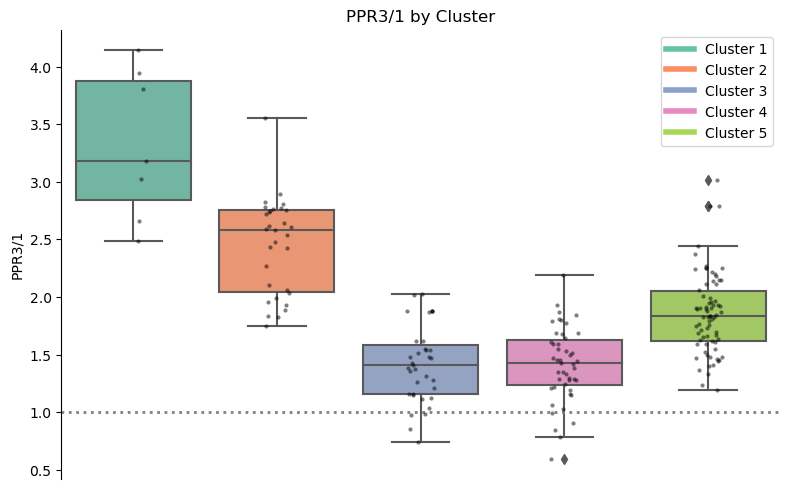

Tests sauvegardés dans: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\14_WT_clust_PPR3_1_stats.txt


In [436]:
# Create a boxplot for PPR3/1 by cluster (same style as PPR2/1 cell) + save stats (no on-plot annotations)
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='PPR3/1', data=df_WT_poolclust, palette='Set2')
sns.stripplot(x='HC_UMAP', y='PPR3/1', data=df_WT_poolclust, color='k', size=3, alpha=0.5, ax=ax)
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('PPR3/1')
plt.title('PPR3/1 by Cluster')

# Clean axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)

# Legend (clusters)
n_cl = df_WT_poolclust['HC_UMAP'].nunique()
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(n_cl)]
labels = [f'Cluster {i+1}' for i in range(n_cl)]
plt.legend(handles, labels, loc='upper right')

# ------------------ Statistical tests (global + pairwise) ------------------
clusters = sorted(df_WT_poolclust['HC_UMAP'].unique())
data_per_cluster = {
    c: df_WT_poolclust.loc[df_WT_poolclust['HC_UMAP'] == c, 'PPR3/1'].dropna().values
    for c in clusters
}

# Global Kruskal-Wallis
try:
    kw_stat, kw_p = kruskal(*data_per_cluster.values())
except ValueError:
    kw_stat, kw_p = float('nan'), float('nan')

# Pairwise Mann-Whitney + Bonferroni
pairs = list(itertools.combinations(clusters, 2))
results = []
for a, b in pairs:
    x = data_per_cluster[a]
    y = data_per_cluster[b]
    try:
        stat, p = mannwhitneyu(x, y, alternative='two-sided')
    except ValueError:
        stat, p = float('nan'), float('nan')
    results.append({
        'C_A': a,
        'C_B': b,
        'n_A': len(x),
        'n_B': len(y),
        'U_stat': stat,
        'p_raw': p
    })

m = len(results)
for r in results:
    if np.isnan(r['p_raw']):
        r['p_corr'] = np.nan
    else:
        r['p_corr'] = min(r['p_raw'] * m, 1.0)

results.sort(key=lambda d: (d['p_corr'] if not np.isnan(d['p_corr']) else 1))

stats_path = os.path.join(output_dir, "14_WT_clust_PPR3_1_stats.txt")
with open(stats_path, "w", encoding="utf-8") as f:
    f.write("PPR3/1 - Analyses statistiques par cluster\n")
    f.write(f"Test global Kruskal-Wallis: H = {kw_stat:.4f}, p = {kw_p:.6g}\n")
    f.write(f"Nombre de comparaisons (Bonferroni): {m}\n\n")
    f.write("Comparaisons pairwise (Mann-Whitney, two-sided):\n")
    f.write("C_A\tC_B\tnA\tnB\tU_stat\tp_raw\tp_corr\n")
    for r in results:
        f.write(f"{r['C_A']}\t{r['C_B']}\t{r['n_A']}\t{r['n_B']}\t"
                f"{r['U_stat']:.4f}\t{r['p_raw']:.6g}\t{r['p_corr']:.6g}\n")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "14_WT_clust_PPR3_1.pdf"))
plt.show()

print(f"Tests sauvegardés dans: {stats_path}")

### 2.C.d AMP1

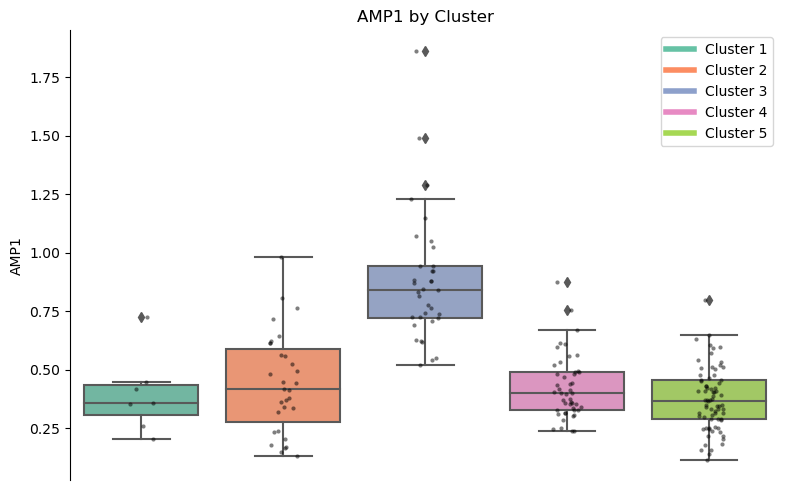

Tests sauvegardés dans: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\15_WT_clust_AMP1_stats.txt


In [437]:
# Boxplot AMP1 par cluster (même style que PPR2/1 et PPR3/1) + sauvegarde stats (pas d'annotations sur la figure)
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='AMP1', data=df_WT_poolclust, palette='Set2')
sns.stripplot(x='HC_UMAP', y='AMP1', data=df_WT_poolclust, color='k', size=3, alpha=0.5, ax=ax)
plt.ylabel('AMP1')
plt.title('AMP1 by Cluster')

# Nettoyage axes / cadre
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)

# Légende clusters
n_cl = df_WT_poolclust['HC_UMAP'].nunique()
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(n_cl)]
labels = [f'Cluster {i+1}' for i in range(n_cl)]
plt.legend(handles, labels, loc='upper right')

# ------------------ Tests statistiques (global + pairwise) ------------------
clusters = sorted(df_WT_poolclust['HC_UMAP'].unique())
data_per_cluster = {
    c: df_WT_poolclust.loc[df_WT_poolclust['HC_UMAP'] == c, 'AMP1'].dropna().values
    for c in clusters
}

# Kruskal-Wallis global
try:
    kw_stat, kw_p = kruskal(*data_per_cluster.values())
except ValueError:
    kw_stat, kw_p = float('nan'), float('nan')

# Pairwise Mann-Whitney + Bonferroni
pairs = list(itertools.combinations(clusters, 2))
results = []
for a, b in pairs:
    x = data_per_cluster[a]
    y = data_per_cluster[b]
    try:
        stat, p = mannwhitneyu(x, y, alternative='two-sided')
    except ValueError:
        stat, p = float('nan'), float('nan')
    results.append({
        'C_A': a,
        'C_B': b,
        'n_A': len(x),
        'n_B': len(y),
        'U_stat': stat,
        'p_raw': p
    })

m = len(results)
for r in results:
    if np.isnan(r['p_raw']):
        r['p_corr'] = np.nan
    else:
        r['p_corr'] = min(r['p_raw'] * m, 1.0)

# Tri par p corrigé
results.sort(key=lambda d: (d['p_corr'] if not np.isnan(d['p_corr']) else 1))

stats_path = os.path.join(output_dir, "15_WT_clust_AMP1_stats.txt")
with open(stats_path, "w", encoding="utf-8") as f:
    f.write("AMP1 - Analyses statistiques par cluster\n")
    f.write(f"Test global Kruskal-Wallis: H = {kw_stat:.4f}, p = {kw_p:.6g}\n")
    f.write(f"Nombre de comparaisons (Bonferroni): {m}\n\n")
    f.write("Comparaisons pairwise (Mann-Whitney, two-sided):\n")
    f.write("C_A\tC_B\tnA\tnB\tU_stat\tp_raw\tp_corr\n")
    for r in results:
        f.write(f"{r['C_A']}\t{r['C_B']}\t{r['n_A']}\t{r['n_B']}\t"
                f"{r['U_stat']:.4f}\t{r['p_raw']:.6g}\t{r['p_corr']:.6g}\n")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "15_WT_clust_AMP1.pdf"))
plt.show()

print(f"Tests sauvegardés dans: {stats_path}")

### 2.C.e %Fail1

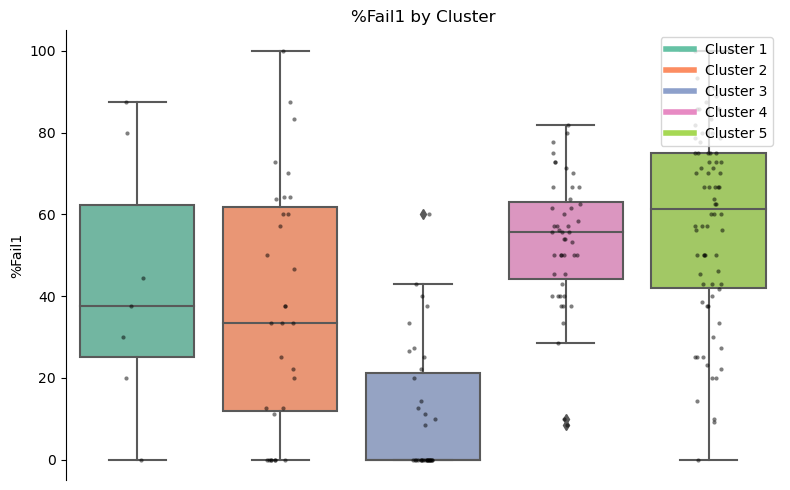

Tests sauvegardés dans: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\16_WT_clust_Fail1_stats.txt


In [438]:
# Boxplot %Fail1 par cluster (même style que PPR2/1, PPR3/1, AMP1) + sauvegarde stats (pas d'annotations sur la figure)
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='%Fail1', data=df_WT_poolclust, palette='Set2')
sns.stripplot(x='HC_UMAP', y='%Fail1', data=df_WT_poolclust, color='k', size=3, alpha=0.5, ax=ax)
plt.ylabel('%Fail1')
plt.title('%Fail1 by Cluster')

# Nettoyage axes / cadre
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)

# Légende (clusters)
n_cl = df_WT_poolclust['HC_UMAP'].nunique()
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(n_cl)]
labels = [f'Cluster {i+1}' for i in range(n_cl)]
plt.legend(handles, labels, loc='upper right')

# ------------------ Analyses statistiques (Kruskal + Mann-Whitney pairwise) ------------------
clusters = sorted(df_WT_poolclust['HC_UMAP'].unique())
data_per_cluster = {
    c: df_WT_poolclust.loc[df_WT_poolclust['HC_UMAP'] == c, '%Fail1'].dropna().values
    for c in clusters
}

# Test global Kruskal-Wallis
try:
    kw_stat, kw_p = kruskal(*data_per_cluster.values())
except ValueError:
    kw_stat, kw_p = float('nan'), float('nan')

# Comparaisons pairwise (Mann-Whitney bilatéral) + correction Bonferroni
pairs = list(itertools.combinations(clusters, 2))
results = []
for a, b in pairs:
    x = data_per_cluster[a]
    y = data_per_cluster[b]
    try:
        stat, p = mannwhitneyu(x, y, alternative='two-sided')
    except ValueError:
        stat, p = float('nan'), float('nan')
    results.append({
        'C_A': a,
        'C_B': b,
        'n_A': len(x),
        'n_B': len(y),
        'U_stat': stat,
        'p_raw': p
    })

m = len(results)
for r in results:
    if np.isnan(r['p_raw']):
        r['p_corr'] = np.nan
    else:
        r['p_corr'] = min(r['p_raw'] * m, 1.0)

# Tri par p corrigée
results.sort(key=lambda d: (d['p_corr'] if not np.isnan(d['p_corr']) else 1))

stats_path = os.path.join(output_dir, "16_WT_clust_Fail1_stats.txt")
with open(stats_path, "w", encoding="utf-8") as f:
    f.write("%Fail1 - Analyses statistiques par cluster\n")
    f.write(f"Test global Kruskal-Wallis: H = {kw_stat:.4f}, p = {kw_p:.6g}\n")
    f.write(f"Nombre de comparaisons (Bonferroni): {m}\n\n")
    f.write("Comparaisons pairwise (Mann-Whitney, two-sided):\n")
    f.write("C_A\tC_B\tnA\tnB\tU_stat\tp_raw\tp_corr\n")
    for r in results:
        f.write(f"{r['C_A']}\t{r['C_B']}\t{r['n_A']}\t{r['n_B']}\t"
                f"{r['U_stat']:.4f}\t{r['p_raw']:.6g}\t{r['p_corr']:.6g}\n")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "16_WT_clust_Fail1.pdf"))
plt.show()

print(f"Tests sauvegardés dans: {stats_path}")

# 3 - SynII

## 3.A SynII data projected on the PCA

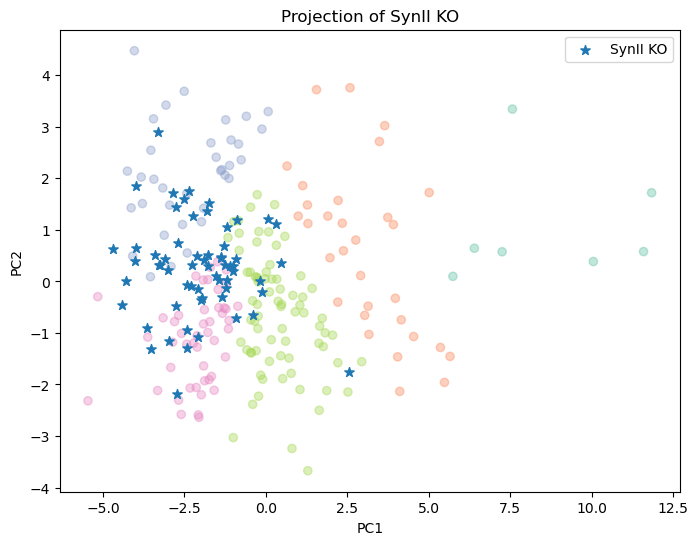

In [439]:
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=.4)
plt.scatter(transformed_SynII['PC1'], transformed_SynII['PC2'],marker='*', s=50, label='SynII KO')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projection of SynII KO')
plt.legend()
plt.savefig(os.path.join(output_dir, "17_PCA_synII.pdf"))
plt.show()


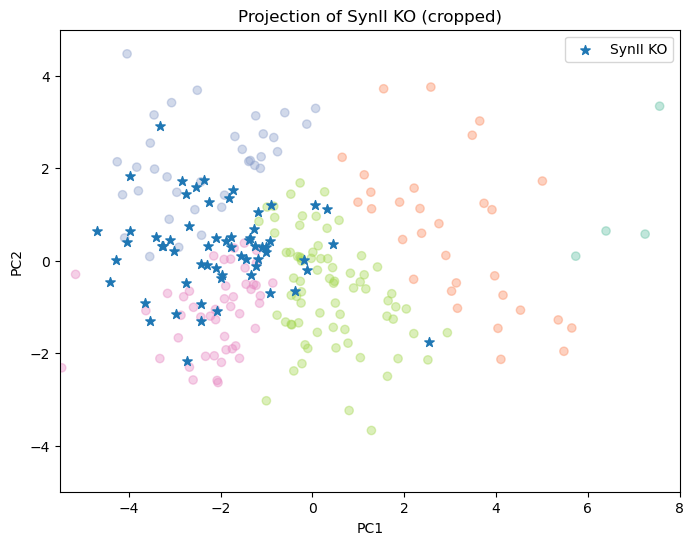

In [440]:
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=.4)
plt.scatter(transformed_SynII['PC1'], transformed_SynII['PC2'],marker='*', s=50, label='SynII KO')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.xlim(-5.5, 8)
plt.ylim(-5, 5)
plt.title('Projection of SynII KO (cropped)')
plt.legend()
plt.show()

## 3.B Proportion of SynII in the different clusters

### 3.B.a Barplot WT vs SynII

This analysis explores the distribution of SynII knockout data points across the clusters previously identified in wild-type (WT) samples. 

The visualization in the previous cell reveals that SynII knockout boutons have a distinct distribution pattern among the five functional classes identified in WT boutons. This suggests that the absence of Synapsin II alters specific aspects of synaptic transmission, potentially affecting some functional clusters more than others.

The bar chart compares the percentage of boutons belonging to each cluster between WT and SynII samples, highlighting shifts in the functional profile caused by the Synapsin II knockout. This comparison helps identify which specific functional classes of synaptic transmission are most affected by the loss of Synapsin II.

La meilleure méthode pour l'attribution des clusters SynII (ou autres nouveaux points) est "single" (distance au point le plus proche dans chaque cluster). Cela correspond le mieux à la logique du clustering hiérarchique utilisé pour les WT, car le HC a été fait avec linkage "ward" sur la PCA, ce qui regroupe les points selon leur proximité réelle dans l'espace projeté. "Single" permet de respecter la frontière réelle des clusters, contrairement à "centroid" qui peut être trompeur si les clusters sont allongés ou multimodaux. "Average" est un compromis mais moins précis pour des clusters non sphériques.

En résumé : utilise "single" pour l'attribution robuste, car c'est le plus cohérent avec le clustering hiérarchique ward utilisé pour les WT.

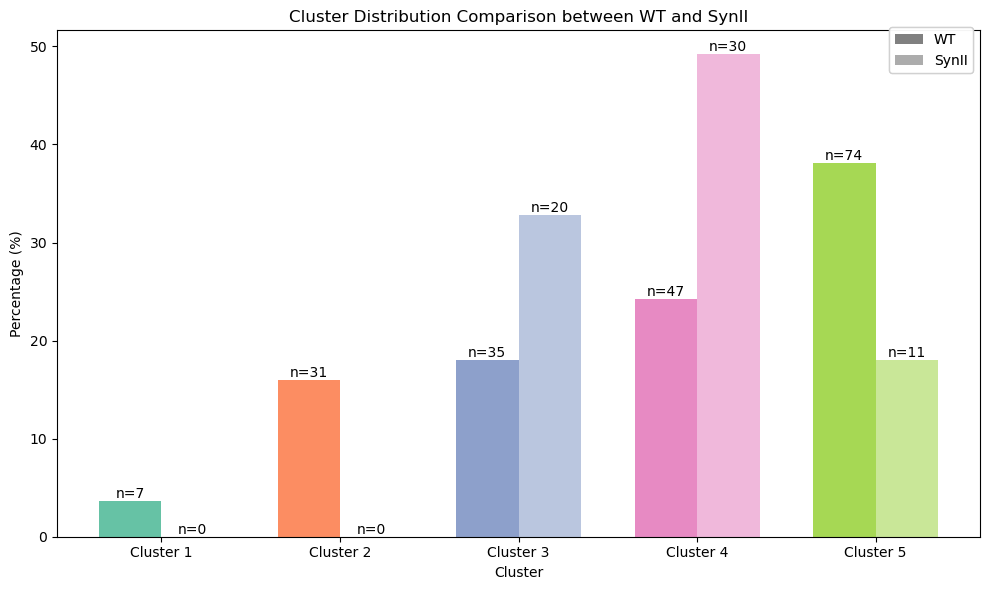

Cluster distribution in WT samples:
Cluster 1: 3.6% (n=7)
Cluster 2: 16.0% (n=31)
Cluster 3: 18.0% (n=35)
Cluster 4: 24.2% (n=47)
Cluster 5: 38.1% (n=74)

Cluster distribution in SynII samples:
Cluster 1: 0.0% (n=0)
Cluster 2: 0.0% (n=0)
Cluster 3: 32.8% (n=20)
Cluster 4: 49.2% (n=30)
Cluster 5: 18.0% (n=11)


In [441]:
def assign_clusters_robust(X_existing, labels_existing, X_new, method='centroid'):
    """
    Assigne à chaque point de X_new un label de cluster existant (labels_existing) selon
    une des trois heuristiques de liaison (linkage) inspirées des approches de clustering hiérarchique.

    Paramètres
    ----------
    X_existing : ndarray (n_samples_exist, n_features)
        Données déjà clusterisées.
    labels_existing : array-like (n_samples_exist,)
        Labels de clusters (entiers) associés à X_existing.
    X_new : ndarray (n_samples_new, n_features)
        Nouvelles données à affecter à l’un des clusters existants.
    method : {'centroid', 'single', 'average'}, défaut 'centroid'
        Stratégie d’affectation :
        - 'centroid' : distance euclidienne au centroïde (moyenne) de chaque cluster.
                       Rapide, résume globalement le cluster, mais peut masquer une structure interne multimodale.
        - 'single'   : distance du point au voisin (point) le plus proche dans chaque cluster (min distance).
                       Très sensible aux outliers mais favorise des frontières serrées autour des points.
        - 'average'  : distance moyenne du point à tous les points du cluster.
                       Compromis entre 'centroid' (global) et 'single' (extrême), moins sensible aux outliers que 'single'.

    Différences essentielles
    ------------------------
    centroid : compare aux représentants "moyens" → rapide, robuste au bruit aléatoire mais sensible si forme allongée.
    single   : compare aux points les plus proches → peut créer des effets de chaînes et suivre des formes fines.
    average  : lisse l’information de distance → compromis, atténue l’influence des extrêmes sans réduire le cluster à un seul centroïde.

    Retour
    ------
    labels_new : ndarray (n_samples_new,)
        Labels assignés, choisis parmi np.unique(labels_existing).
    """
    unique_labels = np.unique(labels_existing)

    if method == 'centroid':
        # Calcul des centroïdes (moyenne par dimension pour chaque cluster)
        centroids = np.vstack([
            X_existing[labels_existing == lbl].mean(axis=0) for lbl in unique_labels
        ])
        # Distances point–centroïde
        distances = cdist(X_new, centroids)  # shape: (n_new, n_clusters)
        labels_new = unique_labels[np.argmin(distances, axis=1)]

    elif method in ('single', 'average'):
        # Pour single / average on calcule soit min, soit moyenne des distances
        agg_funcs = {
            'single': np.min,
            'average': np.mean
        }
        agg = agg_funcs[method]
        # On construit une matrice (n_new, n_clusters) des distances agrégées
        dist_matrix = np.empty((X_new.shape[0], unique_labels.size), dtype=float)
        for j, lbl in enumerate(unique_labels):
            cluster_points = X_existing[labels_existing == lbl]
            # Distances de tous les X_new aux points du cluster courant
            d = cdist(X_new, cluster_points)  # (n_new, n_points_cluster)
            dist_matrix[:, j] = agg(d, axis=1)
        labels_new = unique_labels[np.argmin(dist_matrix, axis=1)]

    else:
        raise ValueError("method doit être 'centroid', 'single' ou 'average'.")

    return labels_new

clusters_SynII = assign_clusters_robust(transformed_data_WT_pooled, hc_labels, transformed_data_SynII, method='single')

# Calculate counts and percentages for both datasets
wt_counts = pd.Series(hc_labels).value_counts().sort_index()
wt_counts = pd.DataFrame({
    'Cluster': wt_counts.index,
    'Count': wt_counts.values,
    'Percentage': 100 * wt_counts.values / len(hc_labels),
    'Dataset': 'WT'
})

# Ensure all clusters are represented in synii_counts
all_clusters = range(1, n_clust + 1)
synii_counts_series = pd.Series(clusters_SynII).value_counts()
synii_counts = pd.DataFrame({
    'Cluster': all_clusters,
    'Count': [synii_counts_series.get(c, 0) for c in all_clusters],
    'Percentage': [100 * synii_counts_series.get(c, 0) / len(clusters_SynII) for c in all_clusters],
    'Dataset': 'SynII'
})
synii_counts = synii_counts.sort_values('Cluster').reset_index(drop=True)

# Create figure and axis objects
plt.figure(figsize=(10, 6))

# Create color palette for clusters using Set2
cmap = cm.get_cmap('Set2')
n_clusters = len(wt_counts)
cluster_colors = [cmap(i) for i in range(n_clusters)]

# Setup for grouped bar plot
bar_width = 0.35
x = np.arange(n_clusters)

# Plot WT bars - solid colors
bars_wt = plt.bar(x - bar_width/2, wt_counts['Percentage'], bar_width,
                  label='WT', color=cluster_colors)

# Plot SynII bars - same colors but transparent
bars_synii = plt.bar(x + bar_width/2, synii_counts['Percentage'], bar_width,
                     label='SynII', color=cluster_colors, alpha=0.6)

# Add count labels on the bars
for bars, counts in [(bars_wt, wt_counts), (bars_synii, synii_counts)]:
    for bar, count in zip(bars, counts['Count']):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                f'n={int(count)}',
                ha='center', va='bottom')

plt.title('Cluster Distribution Comparison between WT and SynII')
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.xticks(x, [f'Cluster {i}' for i in wt_counts['Cluster']])

# Add dataset type legend
wt_patch = plt.Rectangle((0,0),1,1, fc='gray')
synii_patch = plt.Rectangle((0,0),1,1, fc='gray', alpha=0.6)
l1 = plt.legend([wt_patch, synii_patch], ['WT', 'SynII'], 
                loc='upper right', bbox_to_anchor=(1, 1.02))
plt.gca().add_artist(l1)


plt.tight_layout()
plt.show()

# Print the distribution summary
print("Cluster distribution in WT samples:")
for i, row in wt_counts.iterrows():
    print(f"Cluster {row['Cluster']}: {row['Percentage']:.1f}% (n={int(row['Count'])})")

print("\nCluster distribution in SynII samples:")
for i, row in synii_counts.iterrows():
    print(f"Cluster {row['Cluster']}: {row['Percentage']:.1f}% (n={int(row['Count'])})")


### 3.B.b Customize barplot WT vs SynII

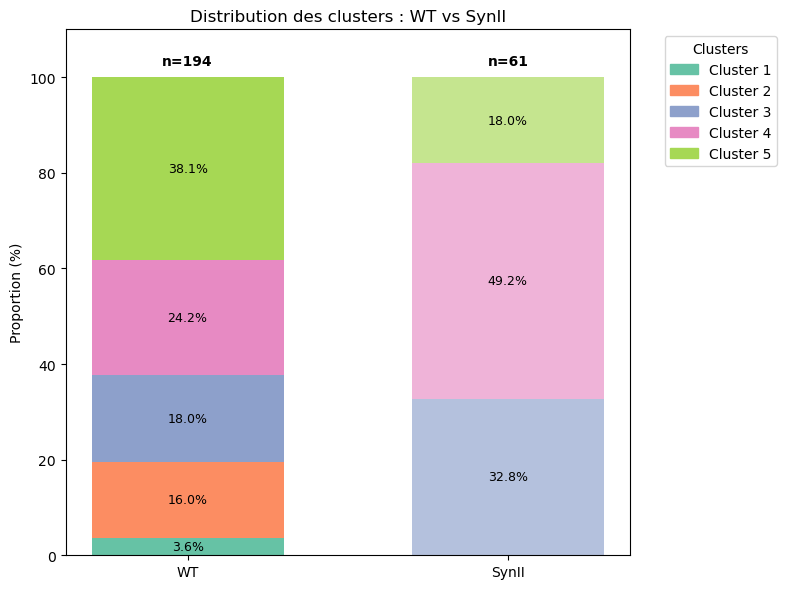

In [442]:
# Stacked barplot avec pourcentages internes pour chaque cluster (WT vs SynII)
fig, ax = plt.subplots(figsize=(8, 6))

wt_proportions    = wt_counts['Percentage'].values
synii_proportions = synii_counts['Percentage'].values
bar_width = 0.6

cmap = cm.get_cmap('Set2')
n_clusters = len(wt_counts)

bottom_wt = 0
bottom_syn = 0

def text_color(rgb):
    r, g, b = rgb[:3]
    # Luminance simple
    lum = 0.2126*r + 0.7152*g + 0.0722*b
    return 'white' if lum < 0.55 else 'black'

for i in range(n_clusters):
    color = cmap(i)
    val_wt = wt_proportions[i]
    val_syn = synii_proportions[i]

    # WT
    ax.bar(0, val_wt, bar_width, bottom=bottom_wt, color=color,
           label=f'Cluster {i+1}' if i == 0 else None)
    if val_wt > 0:
        ax.text(0, bottom_wt + val_wt/2, f"{val_wt:.1f}%", ha='center', va='center',
                color=text_color(color), fontsize=9)
    bottom_wt += val_wt

    # SynII
    ax.bar(1, val_syn, bar_width, bottom=bottom_syn, color=color, alpha=0.65)
    if val_syn > 0:
        ax.text(1, bottom_syn + val_syn/2, f"{val_syn:.1f}%", ha='center', va='center',
                color=text_color(color), fontsize=9)
    bottom_syn += val_syn

# Totaux en haut
ax.text(0, 102, f"n={int(wt_counts['Count'].sum())}", ha='center', va='bottom', fontweight='bold')
ax.text(1, 102, f"n={int(synii_counts['Count'].sum())}", ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Proportion (%)')
ax.set_title('Distribution des clusters : WT vs SynII')
ax.set_xticks([0, 1])
ax.set_xticklabels(['WT', 'SynII'])
ax.set_ylim(0, 110)

# Légende (clusters) une seule entrée par couleur
handles = [plt.Rectangle((0,0),1,1, color=cmap(i)) for i in range(n_clusters)]
ax.legend(handles, [f'Cluster {i+1}' for i in range(n_clusters)],
          title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "18_stacked_bar_WT_SynII_normalized.pdf"))
plt.show()


## 3.C Means values of the different parameters

In [443]:
# Calculate mean ± SD for Amp1, Amp2, and %Fail1 in SynII data
print("Mean ± SD for SynII data:")
print(f"AMP1: {df_SynII['AMP1'].mean():.3f} ± {df_SynII['AMP1'].std():.3f}")
print(f"AMP2: {df_SynII['AMP2'].mean():.3f} ± {df_SynII['AMP2'].std():.3f}")
print(f"%Fail1: {df_SynII['%Fail1'].mean():.3f} ± {df_SynII['%Fail1'].std():.3f}")

Mean ± SD for SynII data:
AMP1: 0.443 ± 0.179
AMP2: 0.622 ± 0.251
%Fail1: 16.532 ± 17.765


## 3.D SynII comparison against WT

### 3.D.a SynII PPR profile with the corresponding major WT clusters

Clusters enriched in SynII: [3, 4]


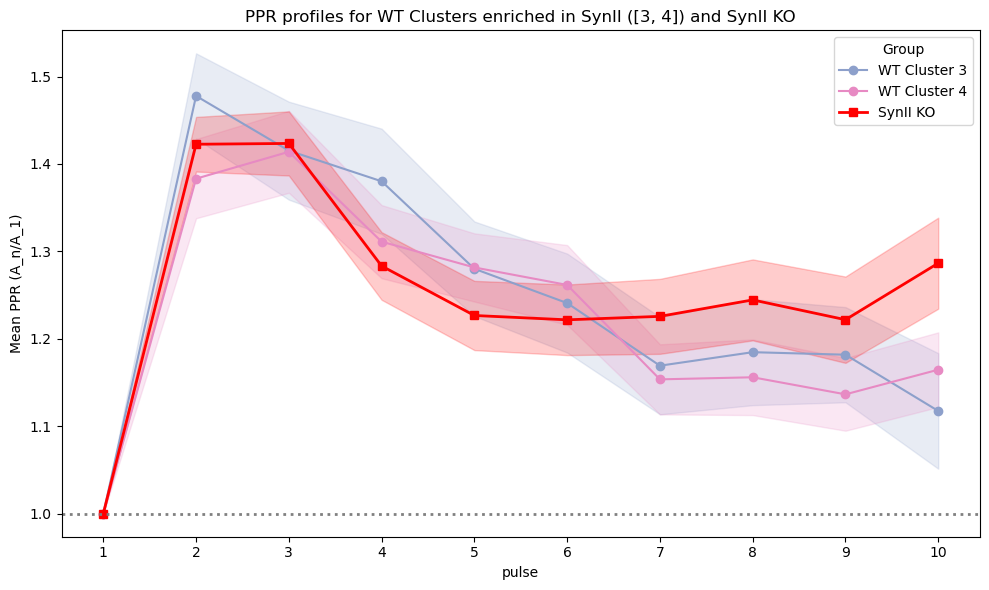

In [444]:
# Identify clusters where SynII percentage is higher than WT percentage
enriched_clusters = []
for i in range(len(wt_counts)):
    wt_pct = wt_counts.iloc[i]['Percentage']
    synii_pct = synii_counts.iloc[i]['Percentage']
    if synii_pct > wt_pct:
        enriched_clusters.append(wt_counts.iloc[i]['Cluster'])

print(f"Clusters enriched in SynII: {enriched_clusters}")

# Plot PPR profiles for enriched clusters and SynII KO
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_WT_poolclust.columns]
x_pulses = list(range(1, len(ppr_cols)+2))  # 1 to 10
cmap = cm.get_cmap('Set2')

plt.figure(figsize=(10, 6))

# Plot WT clusters that are enriched in SynII
for cluster in enriched_clusters:
    cluster_data = df_WT_poolclust[df_WT_poolclust['HC_UMAP'] == cluster]
    means = [1] + cluster_data[ppr_cols].mean().tolist()  # pulse 1 is always 1
    sems = [0] + cluster_data[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0
    color = cmap(cluster-1)  # Use cluster-1 for proper color indexing
    plt.plot(x_pulses, means, marker='o', label=f'WT Cluster {cluster}', color=color)
    plt.fill_between(x_pulses, np.array(means)-np.array(sems), np.array(means)+np.array(sems), alpha=0.2, color=color)

# Add SynII data
synii_means = [1] + df_SynII[ppr_cols].mean().tolist()  # pulse 1 is always 1
synii_sems = [0] + df_SynII[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0
plt.plot(x_pulses, synii_means, marker='s', label='SynII KO', color='red', linewidth=2)
plt.fill_between(x_pulses, np.array(synii_means)-np.array(synii_sems), np.array(synii_means)+np.array(synii_sems), alpha=0.2, color='red')

plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('Mean PPR (A_n/A_1)')
plt.xlabel('pulse')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.title(f'PPR profiles for WT Clusters enriched in SynII ({enriched_clusters}) and SynII KO')
plt.legend(title='Group', loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "19_WT_enriched_clusters_SynII_PPR_profiles.pdf"))
plt.show()

### 3.D.a-bis

Stats sauvegardées: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\20_stats_AMP1_SynII_vs_top2_4_3.txt
Stats sauvegardées: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\20_stats_PPR2-1_SynII_vs_top2_4_3.txt
Stats sauvegardées: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\20_stats_PPR3-1_SynII_vs_top2_4_3.txt
Stats sauvegardées: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\20_stats_%Fail1_SynII_vs_top2_4_3.txt


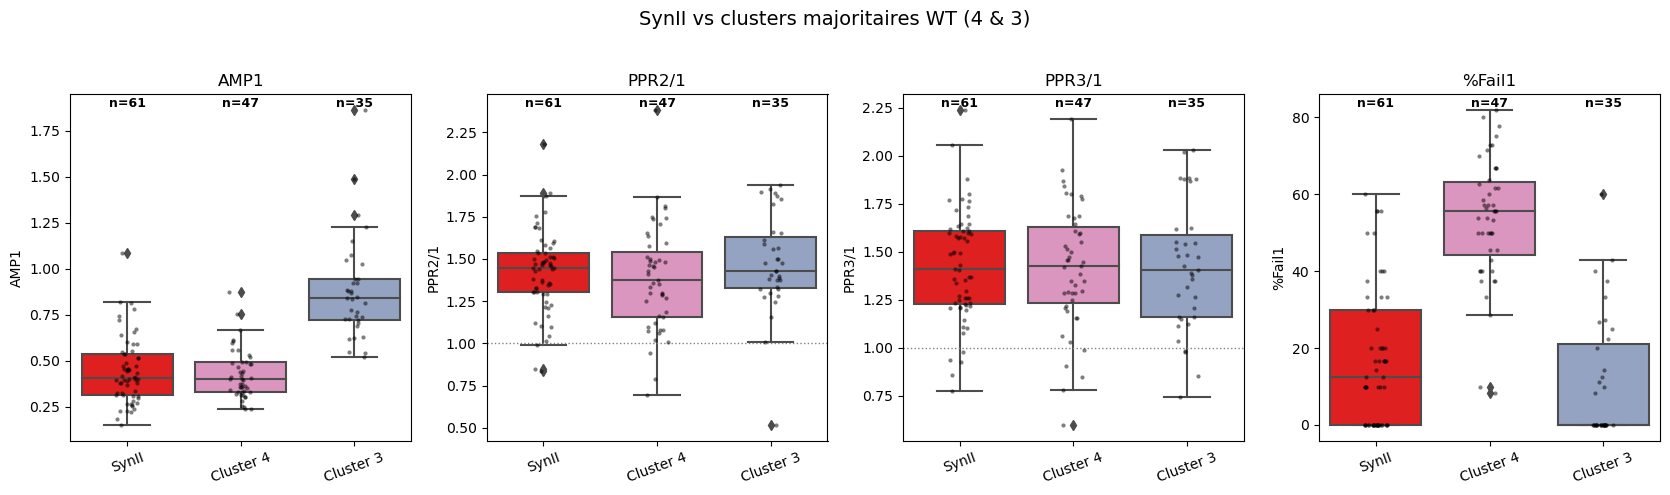

Figure sauvegardée: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\20_SynII_vs_top2_clusters_4_3.pdf


In [445]:
from scipy.stats import kruskal, mannwhitneyu

# Figure: SynII vs 2 clusters majoritaires (parmi SynII) pour AMP1, PPR2/1, PPR3/1, %Fail1
# + Tests statistiques: Kruskal-Wallis global + Mann-Whitney pairwise (Bonferroni)
required_vars = ['df_SynII', 'df_WT_poolclust']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Variables manquantes: {missing}")

# Assigner les clusters SynII si colonne absente
if 'cluster_synII' not in df_SynII.columns:
    if 'clusters_SynII' not in globals():
        clusters_SynII = assign_clusters_robust(transformed_data_WT_pooled, hc_labels,
                                                transformed_data_SynII, method='single')
    df_SynII['cluster_synII'] = clusters_SynII

# Top 2 clusters SynII
synii_cluster_counts = df_SynII['cluster_synII'].value_counts().sort_values(ascending=False)
top2_clusters = synii_cluster_counts.index.tolist()[:2]
if len(top2_clusters) < 2:
    raise RuntimeError("Moins de 2 clusters trouvés dans SynII.")
c1, c2 = top2_clusters

variables = ['AMP1', 'PPR2/1', 'PPR3/1', '%Fail1']
present_vars = [v for v in variables if v in df_SynII.columns and v in df_WT_poolclust.columns]
if len(present_vars) == 0:
    raise RuntimeError("Aucun des paramètres demandés n'est disponible.")

cmap_set2 = cm.get_cmap('Set2')
color_cluster_1 = cmap_set2(c1 - 1)
color_cluster_2 = cmap_set2(c2 - 1)
color_synii = 'red'

fig, axes = plt.subplots(1, len(present_vars), figsize=(4.2*len(present_vars), 5), sharey=False)
if len(present_vars) == 1:
    axes = [axes]

# Boucle tracé + statistiques
for ax, var in zip(axes, present_vars):
    # Construire DataFrame combiné
    df_list = []
    synii_sub = df_SynII[[var]].copy()
    synii_sub['Group'] = 'SynII'
    df_list.append(synii_sub)

    cl1_sub = df_WT_poolclust[df_WT_poolclust['HC_UMAP'] == c1][[var]].copy()
    cl1_sub['Group'] = f'Cluster {c1}'
    df_list.append(cl1_sub)

    cl2_sub = df_WT_poolclust[df_WT_poolclust['HC_UMAP'] == c2][[var]].copy()
    cl2_sub['Group'] = f'Cluster {c2}'
    df_list.append(cl2_sub)

    combo = pd.concat(df_list, axis=0, ignore_index=True)
    order = ['SynII', f'Cluster {c1}', f'Cluster {c2}']
    palette = [color_synii, color_cluster_1, color_cluster_2]

    sns.boxplot(data=combo, x='Group', y=var, order=order, palette=palette, ax=ax)
    sns.stripplot(data=combo, x='Group', y=var, order=order, color='k', size=3,
                  alpha=0.5, dodge=False, ax=ax)

    if var.startswith('PPR'):
        ax.axhline(1, color='gray', ls='dotted', lw=1)

    ax.set_xlabel('')
    ax.set_title(var)
    ax.tick_params(axis='x', rotation=20)

    # Annotation n (ok, pas de stats sur la figure)
    for xtick, grp in enumerate(order):
        y_top = combo[var].max()
        ax.text(xtick, y_top, f"n={int((combo['Group']==grp).sum())}", ha='center', va='bottom',
                fontsize=9, fontweight='bold')

    # ---- Statistiques ----
    # Kruskal-Wallis global
    group_values = [combo.loc[combo['Group'] == g, var].dropna().values for g in order]
    if all(len(gv) >= 2 for gv in group_values):
        kw_stat, kw_p = kruskal(*group_values)
    else:
        kw_stat, kw_p = float('nan'), float('nan')

    # Pairwise Mann-Whitney avec Bonferroni
    comparisons = [
        ('SynII', f'Cluster {c1}'),
        ('SynII', f'Cluster {c2}'),
        (f'Cluster {c1}', f'Cluster {c2}')
    ]
    mw_results = []
    m = len(comparisons)
    for g1, g2 in comparisons:
        v1 = combo.loc[combo['Group'] == g1, var].dropna().values
        v2 = combo.loc[combo['Group'] == g2, var].dropna().values
        if len(v1) >= 2 and len(v2) >= 2:
            stat, p = mannwhitneyu(v1, v2, alternative='two-sided')
        else:
            stat, p = float('nan'), float('nan')
        p_adj = min(p * m, 1.0) if not np.isnan(p) else float('nan')
        mw_results.append((g1, g2, stat, p, p_adj, len(v1), len(v2),
                           np.median(v1) if len(v1) else np.nan,
                           np.median(v2) if len(v2) else np.nan))

    # Export texte
    stats_outfile = os.path.join(
        output_dir,
        f"20_stats_{var.replace('/','-')}_SynII_vs_top2_{c1}_{c2}.txt"
    )
    with open(stats_outfile, 'w', encoding='utf-8') as f:
        f.write(f"Variable: {var}\n")
        f.write(f"Group order: {order}\n\n")
        f.write("Kruskal-Wallis global:\n")
        f.write(f"Statistic: {kw_stat:.6g}\nP-value: {kw_p:.6g}\n\n")
        f.write("Pairwise Mann-Whitney (two-sided) avec correction Bonferroni:\n")
        f.write("Comparaison\tU_stat\tp_raw\tp_bonf\tN1\tN2\tMedian1\tMedian2\n")
        for g1, g2, stat, p, p_adj, n1, n2, med1, med2 in mw_results:
            f.write(f"{g1} vs {g2}\t{stat:.6g}\t{p:.6g}\t{p_adj:.6g}\t{n1}\t{n2}\t{med1:.6g}\t{med2:.6g}\n")
    print(f"Stats sauvegardées: {stats_outfile}")

fig.suptitle(f"SynII vs clusters majoritaires WT ({c1} & {c2})", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
outfile = os.path.join(output_dir, f"20_SynII_vs_top2_clusters_{c1}_{c2}.pdf")
plt.savefig(outfile)
plt.show()
print(f"Figure sauvegardée: {outfile}")

### 3.D.b SynII traces with the corresponding major WT traces

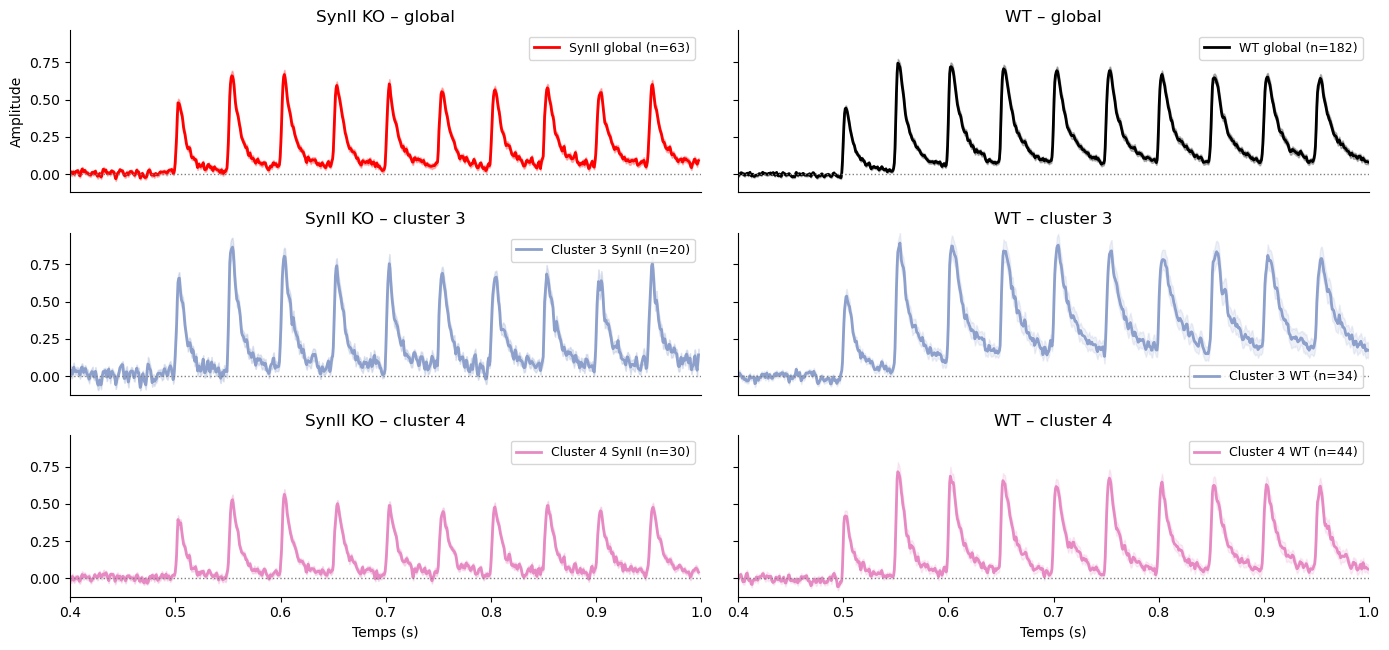

Figure sauvegardée: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\21_SynII_enriched_clusters_mean_traces_with_WT.pdf


In [446]:
df_SynII = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="SynII")

# Assign SynII clusters (robuste)
if 'clusters_SynII' not in locals():
    clusters_SynII = assign_clusters_robust(transformed_data_WT_pooled, hc_labels, transformed_data_SynII, method='single')

if len(df_SynII) != len(clusters_SynII):
    raise ValueError(f"Row mismatch: df_SynII ({len(df_SynII)}) vs clusters_SynII ({len(clusters_SynII)})")

df_SynII['cluster_synII'] = clusters_SynII

# Vérifs variables nécessaires
if 'enriched_clusters' not in locals():
    raise RuntimeError("Variable 'enriched_clusters' absente (exécuter la cellule identifiant enriched_clusters).")

if 'test_SynII' not in locals():
    test_SynII = pd.read_excel(
        r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx",
        sheet_name="SynII"
    )

# Extraction temps + traces SynII
time_syn = test_SynII.iloc[1:, 0].astype(float).values
syn_traces = test_SynII.iloc[1:, 1:].astype(float).values  # (T, N_syn)

# Moyenne / SEM SynII global
syn_mean = syn_traces.mean(axis=1)
syn_sem = syn_traces.std(axis=1) / np.sqrt(syn_traces.shape[1])

# --- Préparation WT ---
wt_trace_data = test.iloc[1:, 1:].astype(float).values  # (T, N_wt)
time_wt = test.iloc[1:, 0].astype(float).values

wt_mean = wt_trace_data.mean(axis=1)
wt_sem  = wt_trace_data.std(axis=1)/np.sqrt(wt_trace_data.shape[1])

# Assignations de clusters WT si nécessaire
if 'clusters_WT' not in locals():
    if 'hc_labels' in locals() and len(hc_labels) >= wt_trace_data.shape[1]:
        clusters_WT = np.array(hc_labels[:wt_trace_data.shape[1]])
    else:
        clusters_WT = np.ones(wt_trace_data.shape[1], dtype=int)

if len(clusters_WT) != wt_trace_data.shape[1]:
    raise ValueError(f"clusters_WT length ({len(clusters_WT)}) != WT traces ({wt_trace_data.shape[1]})")

# --- Stats par cluster enrichi (SynII + WT) ---
cluster_trace_stats_syn = []
cluster_trace_stats_wt  = []
for cl in enriched_clusters:
    # SynII
    mask_syn = (df_SynII['cluster_synII'] == cl)
    idx_syn = mask_syn.values.nonzero()[0]
    if len(idx_syn) > 0:
        cl_traces_syn = syn_traces[:, idx_syn]
        cl_mean_syn = cl_traces_syn.mean(axis=1)
        cl_sem_syn  = cl_traces_syn.std(axis=1)/np.sqrt(cl_traces_syn.shape[1])
        cluster_trace_stats_syn.append((cl, cl_mean_syn, cl_sem_syn, len(idx_syn)))
    else:
        cluster_trace_stats_syn.append((cl, None, None, 0))

    # WT
    idx_wt = np.where(clusters_WT == cl)[0]
    if len(idx_wt) > 0:
        cl_traces_wt = wt_trace_data[:, idx_wt]
        cl_mean_wt = cl_traces_wt.mean(axis=1)
        cl_sem_wt  = cl_traces_wt.std(axis=1)/np.sqrt(cl_traces_wt.shape[1])
        cluster_trace_stats_wt.append((cl, cl_mean_wt, cl_sem_wt, len(idx_wt)))
    else:
        cluster_trace_stats_wt.append((cl, None, None, 0))

usable = any(m is not None for (_, m, _, _) in cluster_trace_stats_syn)
if not usable:
    print("Aucun cluster enrichi chez SynII pour afficher des traces spécifiques.")
else:
    # Limites Y
    all_means = [syn_mean, wt_mean] + [m for (_, m, _, _) in cluster_trace_stats_syn if m is not None] + \
                [m for (_, m, _, _) in cluster_trace_stats_wt if m is not None]
    all_sems  = [syn_sem, wt_sem] + [s for (_, _, s, _) in cluster_trace_stats_syn if s is not None] + \
                [s for (_, _, s, _) in cluster_trace_stats_wt if s is not None]
    y_min = min((m - s).min() for m, s in zip(all_means, all_sems))
    y_max = max((m + s).max() for m, s in zip(all_means, all_sems))

    # Limites X fixes demandées
    x_min_fixed, x_max_fixed = 0.4, 1.0

    n_rows = 1 + len(enriched_clusters)
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 2.2 * n_rows), sharex=True, sharey=True)
    if n_rows == 1:
        axes = np.array([[axes[0], axes[1]]]) if axes.ndim == 1 else axes
    cmap_local = cm.get_cmap('Set2')

    # Ligne globale
    ax_syn = axes[0, 0]; ax_wt = axes[0, 1]

    ax_syn.plot(time_syn, syn_mean, color='red', lw=2, label=f"SynII global (n={syn_traces.shape[1]})")
    ax_syn.fill_between(time_syn, syn_mean - syn_sem, syn_mean + syn_sem, color='red', alpha=0.25)
    ax_syn.axhline(0, color='gray', ls='dotted', lw=1)
    ax_syn.set_xlim(x_min_fixed, x_max_fixed)
    ax_syn.set_ylim(y_min, y_max)
    ax_syn.set_title('SynII KO – global')
    ax_syn.set_ylabel('Amplitude')
    ax_syn.spines['top'].set_visible(False)
    ax_syn.spines['right'].set_visible(False)
    ax_syn.get_xaxis().set_visible(False)
    ax_syn.legend(fontsize=9)

    ax_wt.plot(time_wt, wt_mean, color='black', lw=2, label=f"WT global (n={wt_trace_data.shape[1]})")
    ax_wt.fill_between(time_wt, wt_mean - wt_sem, wt_mean + wt_sem, color='black', alpha=0.25)
    ax_wt.axhline(0, color='gray', ls='dotted', lw=1)
    ax_wt.set_xlim(x_min_fixed, x_max_fixed)
    ax_wt.set_ylim(y_min, y_max)
    ax_wt.set_title('WT – global')
    ax_wt.spines['top'].set_visible(False)
    ax_wt.spines['right'].set_visible(False)
    ax_wt.get_xaxis().set_visible(False)
    ax_wt.legend(fontsize=9)

    # Clusters enrichis
    for r, cl in enumerate(enriched_clusters, start=1):
        ax_s = axes[r, 0]
        cl_syn = next((t for t in cluster_trace_stats_syn if t[0] == cl), None)
        color = cmap_local(cl - 1)
        if cl_syn[1] is not None:
            ax_s.plot(time_syn, cl_syn[1], color=color, lw=2, label=f"Cluster {cl} SynII (n={cl_syn[3]})")
            ax_s.fill_between(time_syn, cl_syn[1] - cl_syn[2], cl_syn[1] + cl_syn[2], color=color, alpha=0.25)
        ax_s.axhline(0, color='gray', ls='dotted', lw=1)
        ax_s.set_xlim(x_min_fixed, x_max_fixed)
        ax_s.set_ylim(y_min, y_max)
        ax_s.set_title(f"SynII KO – cluster {cl}")
        ax_s.spines['top'].set_visible(False)
        ax_s.spines['right'].set_visible(False)
        if r < n_rows - 1:
            ax_s.get_xaxis().set_visible(False)
        ax_s.legend(fontsize=9)

        ax_w = axes[r, 1]
        cl_wt = next((t for t in cluster_trace_stats_wt if t[0] == cl), None)
        if cl_wt[1] is not None:
            ax_w.plot(time_wt, cl_wt[1], color=color, lw=2, label=f"Cluster {cl} WT (n={cl_wt[3]})")
            ax_w.fill_between(time_wt, cl_wt[1] - cl_wt[2], cl_wt[1] + cl_wt[2], color=color, alpha=0.15)
        else:
            ax_w.text(0.5, 0.5, "Absent WT", ha='center', va='center', transform=ax_w.transAxes, fontsize=9)
        ax_w.axhline(0, color='gray', ls='dotted', lw=1)
        ax_w.set_xlim(x_min_fixed, x_max_fixed)
        ax_w.set_ylim(y_min, y_max)
        ax_w.set_title(f"WT – cluster {cl}")
        ax_w.spines['top'].set_visible(False)
        ax_w.spines['right'].set_visible(False)
        if r < n_rows - 1:
            ax_w.get_xaxis().set_visible(False)
        else:
            ax_s.set_xlabel('Temps (s)')
            ax_w.set_xlabel('Temps (s)')
        ax_w.legend(fontsize=9)

    plt.tight_layout()
    fig_path = os.path.join(output_dir, "21_SynII_enriched_clusters_mean_traces_with_WT.pdf")
    plt.savefig(fig_path)
    plt.show()
    print(f"Figure sauvegardée: {fig_path}")


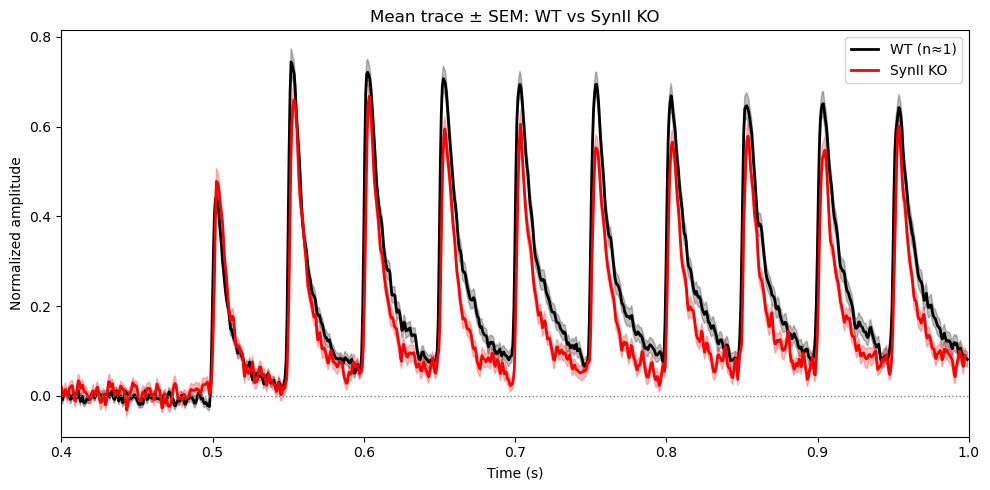

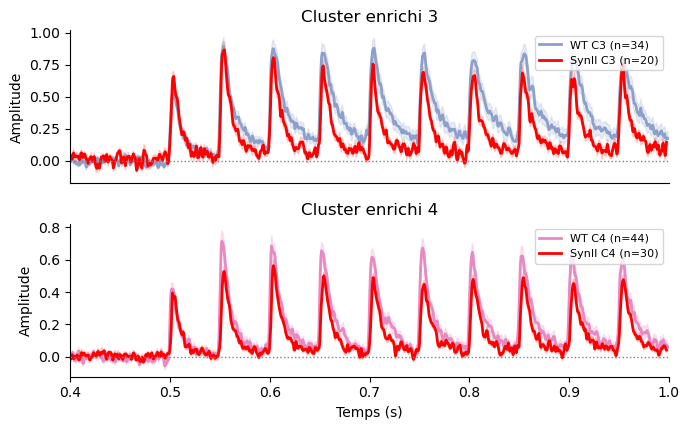

In [447]:
# Plot WT vs SynII mean traces with SEM shading

plt.figure(figsize=(10,5))
plt.plot(time_wt, wt_mean, color='black', lw=2, label=f'WT (n≈{int((wt_sem[0] != 0))})')
plt.fill_between(time_wt, wt_mean - wt_sem, wt_mean + wt_sem, color='black', alpha=0.25)

plt.plot(time_syn, syn_mean, color='red', lw=2, label='SynII KO')
plt.fill_between(time_syn, syn_mean - syn_sem, syn_mean + syn_sem, color='red', alpha=0.25)

plt.axhline(0, color='gray', ls='dotted', lw=1)
plt.xlabel('Time (s)' if 'time_syn' in locals() else 'Sample')
plt.ylabel('Normalized amplitude')
plt.title('Mean trace ± SEM: WT vs SynII KO')
plt.xlim(0.4, 1)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "22_WT_vs_SynII_mean_traces.pdf"))
plt.show()

# Overlay WT vs SynII mean traces (± SEM) for enriched clusters on same axes

if 'enriched_clusters' not in locals() or len(enriched_clusters) == 0:
    print("Aucun cluster enrichi disponible.")
else:
    # Ensure stats lists exist (they were created in cell 76)
    if 'cluster_trace_stats_syn' not in locals() or 'cluster_trace_stats_wt' not in locals():
        print("Statistiques de clusters absentes (exécuter la cellule 76 avant).")
    else:
        cmap_local = cm.get_cmap('Set2')
        n_rows = len(enriched_clusters)
        fig, axes = plt.subplots(n_rows, 1, figsize=(7, 2.2 * n_rows), sharex=True)

        if n_rows == 1:
            axes = [axes]

        for ax, cl in zip(axes, enriched_clusters):
            syn_entry = next((t for t in cluster_trace_stats_syn if t[0] == cl), None)
            wt_entry  = next((t for t in cluster_trace_stats_wt  if t[0] == cl), None)

            if syn_entry is None or wt_entry is None or syn_entry[1] is None or wt_entry[1] is None:
                ax.text(0.5, 0.5, f"Cluster {cl} indisponible", ha='center', va='center', transform=ax.transAxes)
                ax.set_axis_off()
                continue

            cl_color = cmap_local(cl - 1)

            # WT mean ± SEM
            ax.plot(time_wt, wt_entry[1], color=cl_color, lw=2, label=f"WT C{cl} (n={wt_entry[3]})")
            ax.fill_between(time_wt, wt_entry[1] - wt_entry[2], wt_entry[1] + wt_entry[2],
                            color=cl_color, alpha=0.20)

            # SynII mean ± SEM
            ax.plot(time_syn, syn_entry[1], color='red', lw=2,
                    label=f"SynII C{cl} (n={syn_entry[3]})")
            ax.fill_between(time_syn, syn_entry[1] - syn_entry[2], syn_entry[1] + syn_entry[2],
                            color='red', alpha=0.15)

            ax.axhline(0, color='gray', ls='dotted', lw=1)
            ax.set_xlim(0.4, 1.0)
            ax.set_title(f'Cluster enrichi {cl}')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if ax != axes[-1]:
                ax.get_xaxis().set_visible(False)
            else:
                ax.set_xlabel('Temps (s)')
            ax.set_ylabel('Amplitude')
            ax.legend(fontsize=8, loc='upper right')

        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "23_enriched_clusters_WT_vs_SynII_overlay.pdf"))
        plt.show()


## 3.E Syn correspondance to nonPC and PC synapses

### 3.E.a Syn correspondance to nonPC synapses

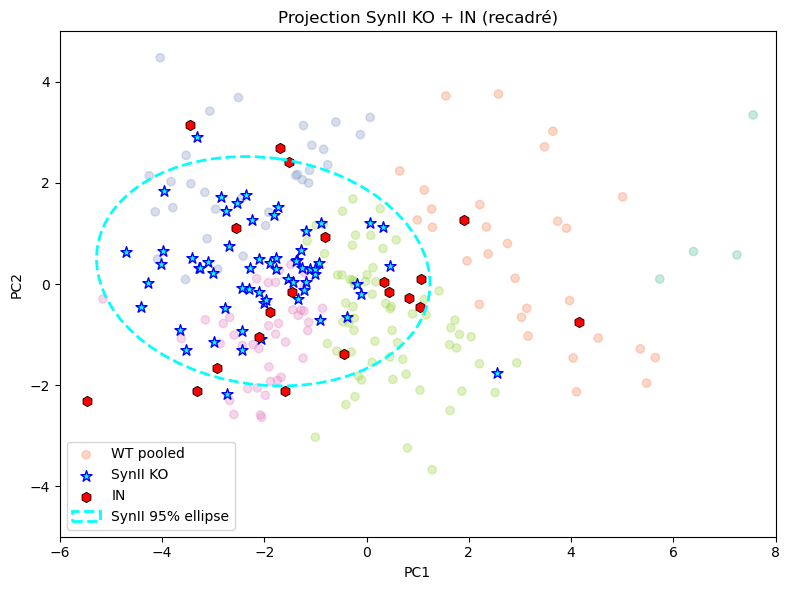

IN à l'intérieur de l'ellipse (SynII 95%):
['20210112_linescan1_20Hz_10pulses_2.5mMCa_bouton1', '20210125_linescan2_20Hz_10pulses_2.5mMCa_bouton1', '20210303_linescan1_20Hz_10pulses_2.5mMCa_bouton1', '20210303_linescan1_20Hz_10pulses_2.5mMCa_bouton2', '20210303_linescan1_20Hz_10pulses_2.5mMCa_bouton3', '20210303_linescan3_20Hz_10pulses_2.5mMCa_bouton3', '20210304_linescan1_20Hz_10pulses_2.5mMCa_bouton1', '20210304_linescan4_20Hz_10pulses_2.5mMCa_bouton2', '20210308_linescan1_20Hz_10pulses_2.5mMCa_bouton3', '20210308_linescan3_20Hz_10pulses_2.5mMCa_bouton4', '20210309_linescan3_20Hz_10pulses_2.5mMCa_bouton3', '20210310_linescan2_20Hz_10pulses_2.5mMCa_bouton3', '20210310_linescan3_20Hz_10pulses_2.5mMCa_bouton2']

IN à l'extérieur de l'ellipse (SynII 95%):
['20210301_linescan3_20Hz_10pulses_2.5mMCa_bouton5', '20210304_linescan3_20Hz_10pulses_2.5mMCa_bouton1', '20210308_linescan2_20Hz_10pulses_2.5mMCa_bouton2', '20210308_linescan3_20Hz_10pulses_2.5mMCa_bouton1', '20210310_linescan4_20Hz_10

In [448]:
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=.35, label='WT pooled')
plt.scatter(transformed_SynII['PC1'], transformed_SynII['PC2'],
            marker='*', s=70, label='SynII KO', c='cyan', edgecolors='blue')

# Ajout des points IN (déjà calculés dans in_transformed)
if 'in_transformed' in locals():
    plt.scatter(in_transformed[:, 0], in_transformed[:, 1],
                marker='h', s=55, c='red', edgecolors='black', linewidths=0.6, label='IN')
else:
    print("Variable in_transformed introuvable (exécuter la cellule de projection PC/IN).")

# Ellipse 95% SynII + classification IN dedans/dehors
inside_ids, outside_ids = [], []
_synii_pts = transformed_SynII[['PC1', 'PC2']].values
if _synii_pts.shape[0] > 2:
    _center = _synii_pts.mean(axis=0)
    _cov = np.cov(_synii_pts.T)
    _chi2_val = chi2.ppf(0.95, df=2)
    _U, _s, _ = np.linalg.svd(_cov)
    _angle = np.degrees(np.arctan2(_U[1, 0], _U[0, 0]))
    _width, _height = 2 * np.sqrt(_chi2_val * _s)
    _ellipse = Ellipse(_center, _width, _height, _angle,
                       facecolor='none', edgecolor='cyan', lw=2, ls='--',
                       label='SynII 95% ellipse')
    ax = plt.gca()
    ax.add_patch(_ellipse)

    # Inversion covariance pour distances de Mahalanobis
    _cov_inv = np.linalg.inv(_cov)
    if 'in_transformed' in locals():
        # Récupération des IDs (si disponibles)
        if 'df_WT_Theo_full' in locals() and 'ID' in df_WT_Theo_full.columns:
            in_ids_all = df_WT_Theo_full.loc[in_indices, 'ID'].tolist()
        else:
            in_ids_all = list(in_indices)

        for _pt, _id in zip(in_transformed, in_ids_all):
            diff = _pt - _center
            md2 = diff @ _cov_inv @ diff.T
            if md2 <= _chi2_val:
                inside_ids.append(_id)
            else:
                outside_ids.append(_id)
else:
    print("Pas assez de points SynII pour construire l'ellipse (n<=2).")

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.xlim(-6, 8)
plt.ylim(-5, 5)
plt.title('Projection SynII KO + IN (recadré)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "24_projection_SynII_KO_plus_IN.pdf"))
plt.show()

# Impression des résultats
print("IN à l'intérieur de l'ellipse (SynII 95%):")
print(inside_ids if inside_ids else "Aucun")
print("\nIN à l'extérieur de l'ellipse (SynII 95%):")
print(outside_ids if outside_ids else "Aucun")

Attention: vecteurs temps différents entre SynII et IN – on utilise time_syn uniquement.


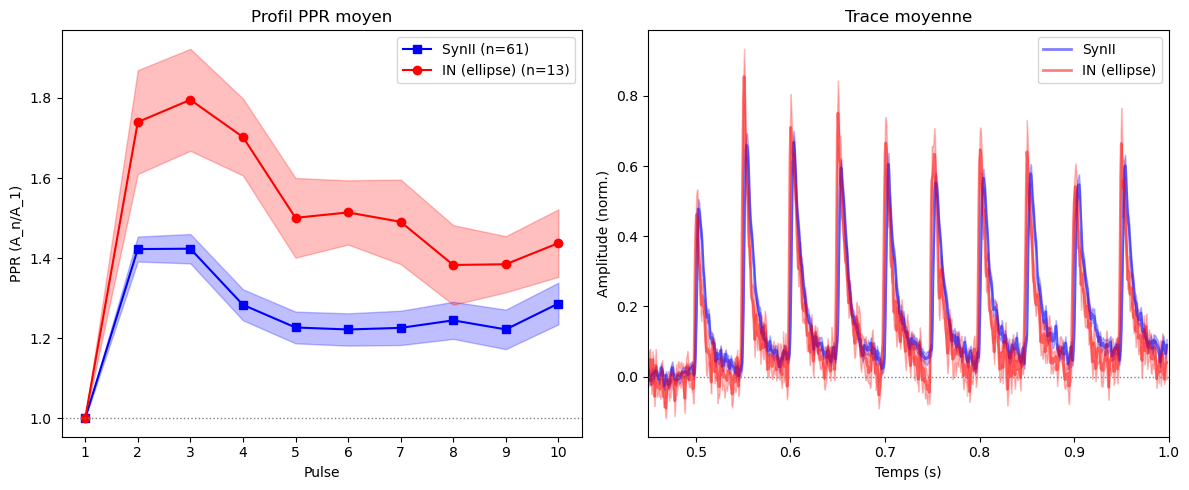

Figure sauvegardée: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\21_SynII_enriched_clusters_mean_traces_with_WT.pdf
IN dans ellipse: 13   SynII: 61


In [449]:
# PPR & trace comparison: SynII vs IN (inside SynII 95% ellipse)

# Vérifications préalables
if 'inside_ids' not in locals():
    raise RuntimeError("La liste inside_ids n'existe pas. Exécuter la cellule 79 d'abord.")
if 'df_WT_Theo_full' not in locals():
    raise RuntimeError("df_WT_Theo_full absent (voir cellule 44).")

# --- 1. Profil PPR moyen ---
# Colonnes PPR disponibles (on force l'ordre 2->10)
ppr_cols = [c for c in [f'PPR{i}/1' for i in range(2,11)] if c in df_SynII.columns and c in df_WT_Theo_full.columns]

# Sous-ensemble IN à l'intérieur de l'ellipse
in_inside_df = df_WT_Theo_full[(df_WT_Theo_full['Target'] == 'IN') & (df_WT_Theo_full['ID'].isin(inside_ids))]

if in_inside_df.empty:
    print("Aucun IN à l'intérieur de l'ellipse – figure non générée.")
else:
    # Moyennes + SEM
    synii_means = [1.0] + df_SynII[ppr_cols].mean().tolist()
    synii_sems  = [0.0] + df_SynII[ppr_cols].sem().tolist()

    in_means = [1.0] + in_inside_df[ppr_cols].mean().tolist()
    in_sems  = [0.0] + in_inside_df[ppr_cols].sem().tolist()

    x_pulses = list(range(1, len(ppr_cols)+2))

    # --- 2. Traces moyennes ---
    # Traces SynII
    if 'test_SynII' not in locals() or 'test_wt_theo' not in locals():
        raise RuntimeError("Les DataFrames de traces (test_SynII / test_wt_theo) manquent (voir cellule 19).")

    time_syn = test_SynII.iloc[1:, 0].astype(float).values
    synii_traces = test_SynII.iloc[1:, 1:].astype(float).values  # (T, n_synii)
    synii_trace_mean = synii_traces.mean(axis=1)
    synii_trace_sem  = synii_traces.std(axis=1) / np.sqrt(synii_traces.shape[1])

    # Traces IN (sélection des colonnes dont l'entête est dans inside_ids)
    in_cols = [c for c in test_wt_theo.columns[1:] if c in inside_ids]
    if len(in_cols) == 0:
        print("Aucune trace IN correspondante trouvée dans test_wt_theo.")
    else:
        in_traces = test_wt_theo.loc[1:, in_cols].astype(float).values
        in_trace_mean = in_traces.mean(axis=1)
        in_trace_sem  = in_traces.std(axis=1) / np.sqrt(in_traces.shape[1])

        # Vérifier alignement temporel
        time_in = test_wt_theo.iloc[1:, 0].astype(float).values
        if len(time_in) != len(time_syn) or not np.allclose(time_in, time_syn):
            print("Attention: vecteurs temps différents entre SynII et IN – on utilise time_syn uniquement.")
        
        # --- 3. Figure ---
        fig, axes = plt.subplots(1, 2, figsize=(12,5))

        # (A) PPR profile
        ax0 = axes[0]
        ax0.plot(x_pulses, synii_means, marker='s', color='blue', label=f"SynII (n={len(df_SynII)})")
        ax0.fill_between(x_pulses,
                         np.array(synii_means)-np.array(synii_sems),
                         np.array(synii_means)+np.array(synii_sems),
                         color='blue', alpha=0.25)
        ax0.plot(x_pulses, in_means, marker='o', color='red', label=f"IN (ellipse) (n={len(in_inside_df)})")
        ax0.fill_between(x_pulses,
                         np.array(in_means)-np.array(in_sems),
                         np.array(in_means)+np.array(in_sems),
                         color='red', alpha=0.25)
        ax0.axhline(1, color='gray', linestyle='dotted', linewidth=1)
        ax0.set_xlabel('Pulse')
        ax0.set_ylabel('PPR (A_n/A_1)')
        ax0.set_xticks(x_pulses)
        ax0.set_title('Profil PPR moyen')
        ax0.legend()
        plt.savefig(os.path.join(output_dir, "25_meanPPR_SynIIKO_vs_IN.pdf"))


        # (B) Traces moyennes
        ax1 = axes[1]
        ax1.plot(time_syn, synii_trace_mean, color='blue', linewidth=2, alpha=0.5, label='SynII')
        ax1.fill_between(time_syn,
                         synii_trace_mean - synii_trace_sem,
                         synii_trace_mean + synii_trace_sem,
                         color='blue', alpha=0.25)
        ax1.plot(time_syn, in_trace_mean, color='red', linewidth=2, alpha=0.5, label='IN (ellipse)')
        ax1.fill_between(time_syn,
                         in_trace_mean - in_trace_sem,
                         in_trace_mean + in_trace_sem,
                         color='red', alpha=0.25)
        ax1.axhline(0, color='gray', linestyle='dotted', linewidth=1)
        ax1.set_xlim(0.45, 1.0)
        ax1.set_xlabel('Temps (s)')
        ax1.set_ylabel('Amplitude (norm.)')
        ax1.set_title('Trace moyenne')
        ax1.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "26_meantraces_SynIIKO_vs_IN.pdf"))
        plt.show()

        print(f"Figure sauvegardée: {fig_path}")
        print(f"IN dans ellipse: {len(in_inside_df)}   SynII: {len(df_SynII)}")

### 3.E.b Syn correspondance to PC synapses

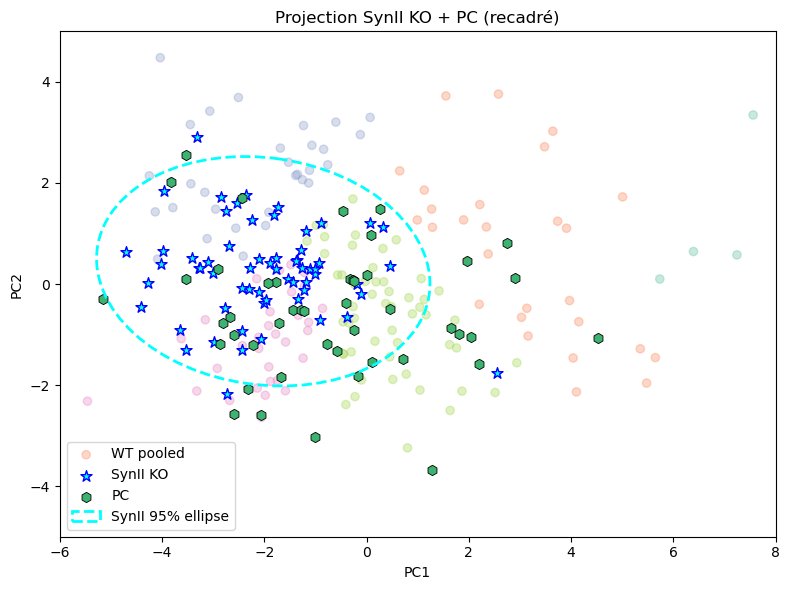

PC à l'intérieur de l'ellipse (SynII 95%):
['20210112_linescan1_20Hz_10pulses_2.5mMCa_bouton3', '20210112_linescan1_20Hz_10pulses_2.5mMCa_bouton4', '20210125_linescan2_20Hz_10pulses_2.5mMCa_bouton2', '20210125_linescan3_20Hz_10pulses_2.5mMCa_bouton2', '20210301_linescan1_20Hz_10pulses_2.5mMCa_bouton1', '20210301_linescan1_20Hz_10pulses_2.5mMCa_bouton2', '20210301_linescan2_20Hz_10pulses_2.5mMCa_bouton3', '20210301_linescan2_20Hz_10pulses_2.5mMCa_bouton4', '20210301_linescan3_20Hz_10pulses_2.5mMCa_bouton2', '20210301_linescan3_20Hz_10pulses_2.5mMCa_bouton3', '20210303_linescan3_20Hz_10pulses_2.5mMCa_bouton2', '20210303_linescan3_20Hz_10pulses_2.5mMCa_bouton5', '20210304_linescan1_20Hz_10pulses_2.5mMCa_bouton2', '20210304_linescan1_20Hz_10pulses_2.5mMCa_bouton3', '20210304_linescan1_20Hz_10pulses_2.5mMCa_bouton5', '20210304_linescan1_20Hz_10pulses_2.5mMCa_bouton6', '20210304_linescan2_20Hz_10pulses_2.5mMCa_bouton1', '20210304_linescan2_20Hz_10pulses_2.5mMCa_bouton3', '20210304_linescan2_

In [450]:
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=.35, label='WT pooled')
plt.scatter(transformed_SynII['PC1'], transformed_SynII['PC2'],
            marker='*', s=70, label='SynII KO', c='cyan', edgecolors='blue')

# Ajout des points PC (déjà calculés dans pc_transformed)
if 'pc_transformed' in locals():
    plt.scatter(pc_transformed[:, 0], pc_transformed[:, 1],
                marker='h', s=55, c='mediumseagreen', edgecolors='black', linewidths=0.6, label='PC')
else:
    print("Variable pc_transformed introuvable (exécuter la cellule de projection PC/IN).")

# Ellipse 95% SynII + classification PC dedans/dehors
pc_inside_ids, pc_outside_ids = [], []
_synii_pts = transformed_SynII[['PC1', 'PC2']].values
if _synii_pts.shape[0] > 2:
    _center = _synii_pts.mean(axis=0)
    _cov = np.cov(_synii_pts.T)
    _chi2_val = chi2.ppf(0.95, df=2)
    _U, _s, _ = np.linalg.svd(_cov)
    _angle = np.degrees(np.arctan2(_U[1, 0], _U[0, 0]))
    _width, _height = 2 * np.sqrt(_chi2_val * _s)
    _ellipse = Ellipse(_center, _width, _height, _angle,
                       facecolor='none', edgecolor='cyan', lw=2, ls='--',
                       label='SynII 95% ellipse')
    ax = plt.gca()
    ax.add_patch(_ellipse)

    _cov_inv = np.linalg.inv(_cov)
    if 'pc_transformed' in locals():
        if 'df_WT_Theo_full' in locals() and 'ID' in df_WT_Theo_full.columns:
            pc_ids_all = df_WT_Theo_full.loc[pc_indices, 'ID'].tolist()
        else:
            pc_ids_all = list(pc_indices)

        for _pt, _id in zip(pc_transformed, pc_ids_all):
            diff = _pt - _center
            md2 = diff @ _cov_inv @ diff.T
            if md2 <= _chi2_val:
                pc_inside_ids.append(_id)
            else:
                pc_outside_ids.append(_id)
else:
    print("Pas assez de points SynII pour construire l'ellipse (n<=2).")

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.xlim(-6, 8)
plt.ylim(-5, 5)
plt.title('Projection SynII KO + PC (recadré)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "27_projection_SynII_KO_plus_PC.pdf"))
plt.show()

print("PC à l'intérieur de l'ellipse (SynII 95%):")
print(pc_inside_ids if pc_inside_ids else "Aucun")
print("\nPC à l'extérieur de l'ellipse (SynII 95%):")
print(pc_outside_ids if pc_outside_ids else "Aucun")



Attention: vecteurs temps différents – utilisation de time_syn uniquement.


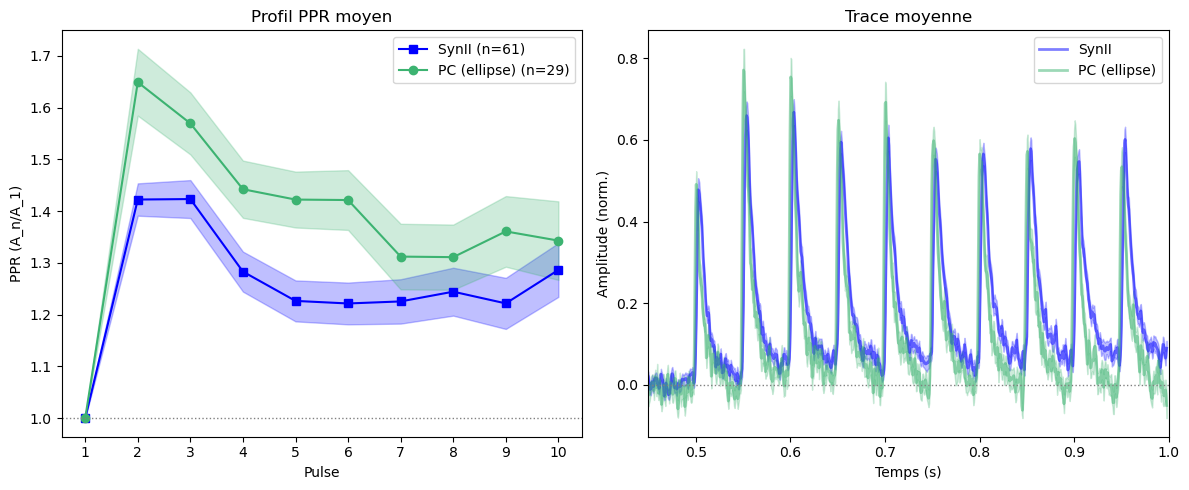

Figure sauvegardée: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\21_SynII_enriched_clusters_mean_traces_with_WT.pdf
PC dans ellipse: 29   SynII: 61


In [451]:
# PPR & trace comparison: SynII vs PC (inside SynII 95% ellipse)

# Vérifications préalables
if 'pc_inside_ids' not in locals():
    raise RuntimeError("La liste pc_inside_ids n'existe pas. Exécuter la cellule générant pc_inside_ids d'abord.")
if 'df_WT_Theo_full' not in locals():
    raise RuntimeError("df_WT_Theo_full absent (voir cellule correspondante).")

# --- 1. Profil PPR moyen ---
ppr_cols = [c for c in [f'PPR{i}/1' for i in range(2,11)] if c in df_SynII.columns and c in df_WT_Theo_full.columns]

# Sous-ensemble PC à l'intérieur de l'ellipse
pc_inside_df = df_WT_Theo_full[(df_WT_Theo_full['Target'] == 'PC') & (df_WT_Theo_full['ID'].isin(pc_inside_ids))]

if pc_inside_df.empty:
    print("Aucun PC à l'intérieur de l'ellipse – figure non générée.")
else:
    synii_means = [1.0] + df_SynII[ppr_cols].mean().tolist()
    synii_sems  = [0.0] + df_SynII[ppr_cols].sem().tolist()

    pc_means = [1.0] + pc_inside_df[ppr_cols].mean().tolist()
    pc_sems  = [0.0] + pc_inside_df[ppr_cols].sem().tolist()

    x_pulses = list(range(1, len(ppr_cols)+2))

    # --- 2. Traces moyennes ---
    if 'test_SynII' not in locals() or 'test_wt_theo' not in locals():
        raise RuntimeError("DataFrames de traces manquants (test_SynII / test_wt_theo).")

    time_syn = test_SynII.iloc[1:, 0].astype(float).values
    synii_traces = test_SynII.iloc[1:, 1:].astype(float).values
    synii_trace_mean = synii_traces.mean(axis=1)
    synii_trace_sem  = synii_traces.std(axis=1) / np.sqrt(synii_traces.shape[1])

    pc_cols = [c for c in test_wt_theo.columns[1:] if c in pc_inside_ids]
    if len(pc_cols) == 0:
        print("Aucune trace PC correspondante trouvée dans test_wt_theo.")
    else:
        pc_traces = test_wt_theo.loc[1:, pc_cols].astype(float).values
        pc_trace_mean = pc_traces.mean(axis=1)
        pc_trace_sem  = pc_traces.std(axis=1) / np.sqrt(pc_traces.shape[1])

        time_pc = test_wt_theo.iloc[1:, 0].astype(float).values
        if len(time_pc) != len(time_syn) or not np.allclose(time_pc, time_syn):
            print("Attention: vecteurs temps différents – utilisation de time_syn uniquement.")

        # --- 3. Figure ---
        fig, axes = plt.subplots(1, 2, figsize=(12,5))

        # (A) PPR profile
        ax0 = axes[0]
        ax0.plot(x_pulses, synii_means, marker='s', color='blue', label=f"SynII (n={len(df_SynII)})")
        ax0.fill_between(x_pulses,
                         np.array(synii_means)-np.array(synii_sems),
                         np.array(synii_means)+np.array(synii_sems),
                         color='blue', alpha=0.25)
        ax0.plot(x_pulses, pc_means, marker='o', color='mediumseagreen', label=f"PC (ellipse) (n={len(pc_inside_df)})")
        ax0.fill_between(x_pulses,
                         np.array(pc_means)-np.array(pc_sems),
                         np.array(pc_means)+np.array(pc_sems),
                         color='mediumseagreen', alpha=0.25)
        ax0.axhline(1, color='gray', linestyle='dotted', linewidth=1)
        ax0.set_xlabel('Pulse')
        ax0.set_ylabel('PPR (A_n/A_1)')
        ax0.set_xticks(x_pulses)
        ax0.set_title('Profil PPR moyen')
        ax0.legend()
        plt.savefig(os.path.join(output_dir, "28_meanPPR_SynIIKO_vs_PC.pdf"))

        # (B) Traces moyennes
        ax1 = axes[1]
        ax1.plot(time_syn, synii_trace_mean, color='blue', linewidth=2, alpha=0.5, label='SynII')
        ax1.fill_between(time_syn,
                         synii_trace_mean - synii_trace_sem,
                         synii_trace_mean + synii_trace_sem,
                         color='blue', alpha=0.25)
        ax1.plot(time_syn, pc_trace_mean, color='mediumseagreen', linewidth=2, alpha=0.5, label='PC (ellipse)')
        ax1.fill_between(time_syn,
                         pc_trace_mean - pc_trace_sem,
                         pc_trace_mean + pc_trace_sem,
                         color='mediumseagreen', alpha=0.25)
        ax1.axhline(0, color='gray', linestyle='dotted', linewidth=1)
        ax1.set_xlim(0.45, 1.0)
        ax1.set_xlabel('Temps (s)')
        ax1.set_ylabel('Amplitude (norm.)')
        ax1.set_title('Trace moyenne')
        ax1.legend()

        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "29_meantraces_SynIIKO_vs_PC.pdf"))
        plt.show()

        print(f"Figure sauvegardée: {fig_path}")
        print(f"PC dans ellipse: {len(pc_inside_df)}   SynII: {len(df_SynII)}")


# 4 - Diversity along a fiber

## 4.A Barpplot of the proportion of PFs displaying 1 to 4 classes of boutons

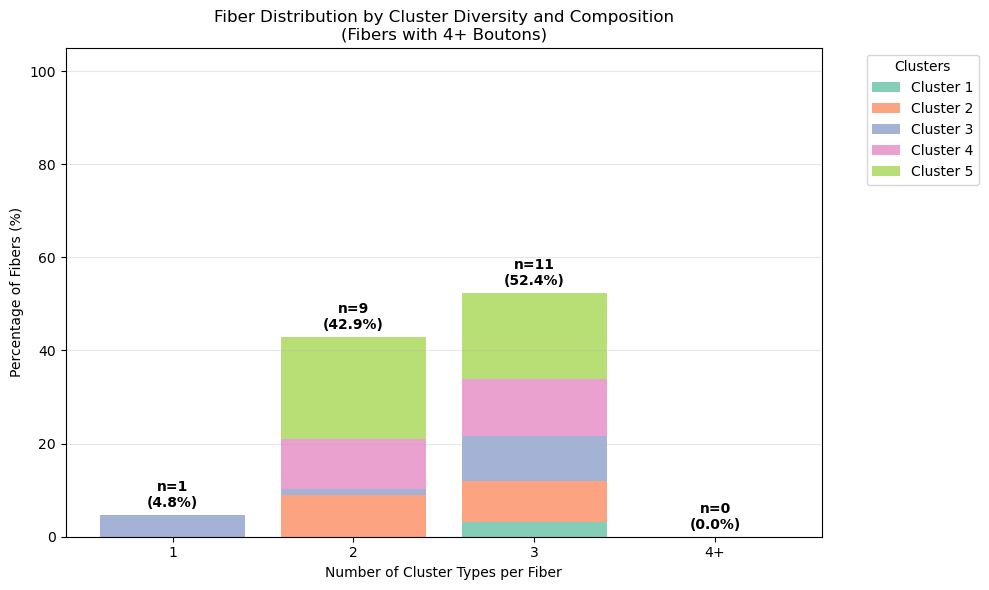

Fiber cluster diversity composition summary (fibers with 4+ boutons only):

Fibers with 1 cluster type(s): 1 fibers (4.8%)
  Cluster 3: 100.0% average proportion (1.0 fiber-equivalents)

Fibers with 2 cluster type(s): 9 fibers (42.9%)
  Cluster 2: 21.1% average proportion (1.9 fiber-equivalents)
  Cluster 3: 2.8% average proportion (0.2 fiber-equivalents)
  Cluster 4: 25.0% average proportion (2.2 fiber-equivalents)
  Cluster 5: 51.1% average proportion (4.6 fiber-equivalents)

Fibers with 3 cluster type(s): 11 fibers (52.4%)
  Cluster 1: 5.9% average proportion (0.7 fiber-equivalents)
  Cluster 2: 17.1% average proportion (1.9 fiber-equivalents)
  Cluster 3: 18.2% average proportion (2.0 fiber-equivalents)
  Cluster 4: 23.4% average proportion (2.6 fiber-equivalents)
  Cluster 5: 35.4% average proportion (3.9 fiber-equivalents)

Total number of fibers analyzed: 21
(filtered from 54 total fibers)
Average boutons per fiber in filtered dataset: 5.5

List of fibers with exactly 3 cluster 

In [452]:
# Extract fiber ID from the full ID (first 22 characters)
df_WT_poolclust['Fiber_ID'] = df_WT_poolclust['ID'].str[:22]

# Count total number of boutons per fiber
fiber_bouton_counts = df_WT_poolclust.groupby('Fiber_ID').size().reset_index(name='Bouton_Count')

# Filter to keep only fibers with 4 or more boutons
fibers_with_enough_boutons = fiber_bouton_counts[fiber_bouton_counts['Bouton_Count'] >= 4]['Fiber_ID'].tolist()
df_filtered = df_WT_poolclust[df_WT_poolclust['Fiber_ID'].isin(fibers_with_enough_boutons)]

# Count number of different clusters per fiber
fiber_cluster_diversity = df_filtered.groupby('Fiber_ID')['HC_UMAP'].nunique().reset_index()
fiber_cluster_diversity.columns = ['Fiber_ID', 'Num_Cluster_Types']

# Add bouton count information
fiber_cluster_diversity = fiber_cluster_diversity.merge(
    fiber_bouton_counts, on='Fiber_ID', how='left'
)

# Categorize fibers by number of cluster types (cap at 4+)
fiber_cluster_diversity['Cluster_Diversity'] = fiber_cluster_diversity['Num_Cluster_Types'].apply(
    lambda x: f'{x}' if x <= 3 else '4+'
)

# Calculate cluster distribution for each diversity category
diversity_cluster_data = {}
for fiber_id in df_filtered['Fiber_ID'].unique():
    fiber_data = df_filtered[df_filtered['Fiber_ID'] == fiber_id]
    num_clusters = len(fiber_data['HC_UMAP'].unique())
    diversity_key = str(num_clusters) if num_clusters <= 3 else '4+'
    
    if diversity_key not in diversity_cluster_data:
        diversity_cluster_data[diversity_key] = []
    
    # Count clusters for this fiber
    cluster_counts = fiber_data['HC_UMAP'].value_counts()
    total_boutons = len(fiber_data)
    cluster_props = {cluster: count/total_boutons for cluster, count in cluster_counts.items()}
    diversity_cluster_data[diversity_key].append(cluster_props)

# Calculate average proportions and absolute counts for each cluster in each diversity category
diversity_order = ['1', '2', '3', '4+']
cmap = cm.get_cmap('Set2')
n_clusters_total = 5  # Total number of clusters

# Calculate mean proportions and fiber counts
diversity_means = {}
diversity_counts = {}
total_fibers = len(fiber_cluster_diversity)

for diversity in diversity_order:
    if diversity in diversity_cluster_data:
        diversity_counts[diversity] = len(diversity_cluster_data[diversity])
        cluster_means = {}
        for cluster in range(1, n_clusters_total + 1):
            proportions = [fiber_data.get(cluster, 0) for fiber_data in diversity_cluster_data[diversity]]
            cluster_means[cluster] = np.mean(proportions)
        diversity_means[diversity] = cluster_means
    else:
        diversity_counts[diversity] = 0
        diversity_means[diversity] = {cluster: 0 for cluster in range(1, n_clusters_total + 1)}

# Create stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))

x_positions = np.arange(len(diversity_order))
bottom = np.zeros(len(diversity_order))

# Create stacked bars with cluster colors - height = percentage of fibers * proportion
for cluster in range(1, n_clusters_total + 1):
    # Calculate percentage values: (number of fibers / total fibers) * 100 * proportion of that cluster
    percentage_values = [(diversity_counts[div] / total_fibers) * 100 * diversity_means[div][cluster] for div in diversity_order]
    bars = ax.bar(x_positions, percentage_values, bottom=bottom, 
                  color=cmap(cluster-1), label=f'Cluster {cluster}', alpha=0.8)
    bottom += percentage_values

# Add count and percentage labels on top of bars
for i, (diversity, count) in enumerate(zip(diversity_order, [diversity_counts[d] for d in diversity_order])):
    percentage_total = (count / total_fibers) * 100
    ax.text(i, percentage_total + 1, f'n={count}\n({percentage_total:.1f}%)', 
            ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Number of Cluster Types per Fiber')
ax.set_ylabel('Percentage of Fibers (%)')
ax.set_title('Fiber Distribution by Cluster Diversity and Composition\n(Fibers with 4+ Boutons)')
ax.set_xticks(x_positions)
ax.set_xticklabels(diversity_order)
ax.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Set y-axis to start at 0 and go to 100%
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "30_fiber_cluster_diversity_composition_4plus_boutons.pdf"))
plt.show()

# Print detailed summary statistics
print("Fiber cluster diversity composition summary (fibers with 4+ boutons only):")
for diversity in diversity_order:
    if diversity in diversity_counts and diversity_counts[diversity] > 0:
        percentage_of_total = (diversity_counts[diversity] / total_fibers) * 100
        print(f"\nFibers with {diversity} cluster type(s): {diversity_counts[diversity]} fibers ({percentage_of_total:.1f}%)")
        for cluster in range(1, n_clusters_total + 1):
            prop = diversity_means[diversity][cluster]
            if prop > 0:
                absolute_count = diversity_counts[diversity] * prop
                print(f"  Cluster {cluster}: {prop:.1%} average proportion ({absolute_count:.1f} fiber-equivalents)")

print(f"\nTotal number of fibers analyzed: {total_fibers}")
print(f"(filtered from {len(fiber_bouton_counts)} total fibers)")

# Calculate average number of boutons per fiber in the filtered dataset
avg_boutons = fiber_cluster_diversity['Bouton_Count'].mean()
print(f"Average boutons per fiber in filtered dataset: {avg_boutons:.1f}")

# Print list of fibers with exactly 3 cluster types
fibers_with_3_clusters = fiber_cluster_diversity[fiber_cluster_diversity['Num_Cluster_Types'] == 3]['Fiber_ID'].tolist()
print(f"\nList of fibers with exactly 3 cluster types ({len(fibers_with_3_clusters)} fibers):")
for fiber_id in fibers_with_3_clusters:
    print(f"  {fiber_id}")

## 4.B Exemple of fiber 

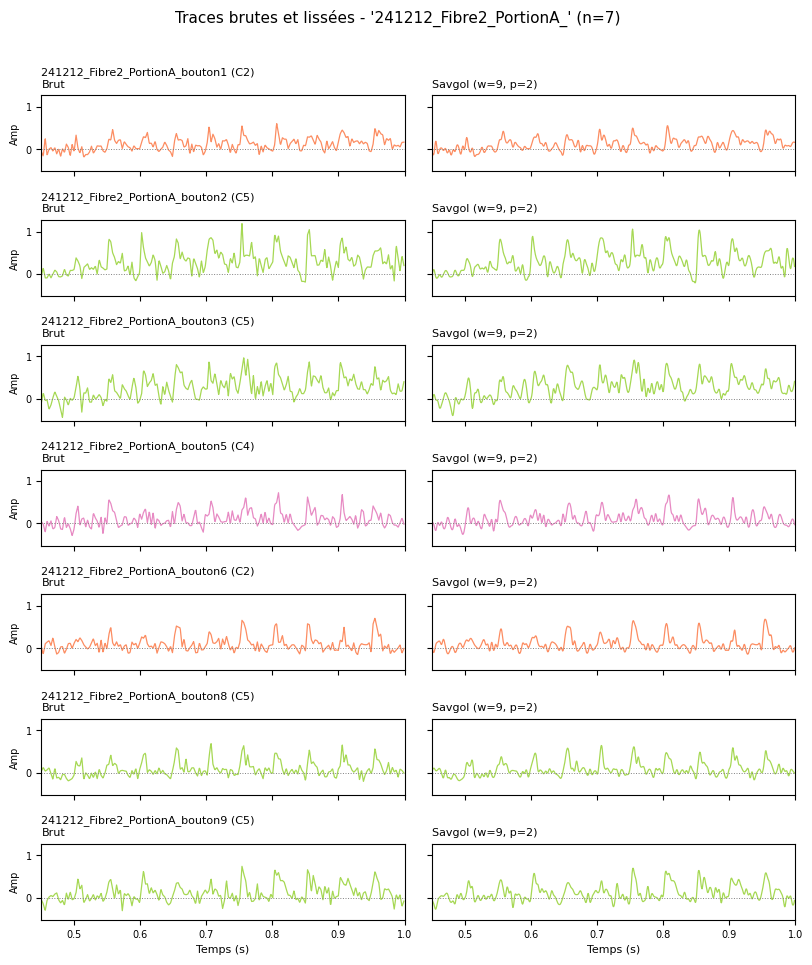

Figure sauvegardée : C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\30_A_traces_241212_Fibre2_PortionA__brut_vs_savgol.pdf


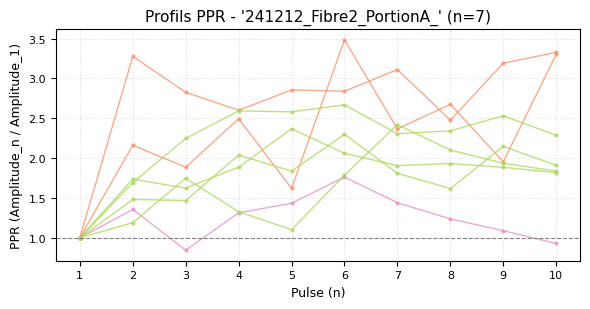

Figure PPR sauvegardée : C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\30_B_PPR_profiles_241212_Fibre2_PortionA__no_mean_points.pdf


In [487]:
# Plot des traces + version lissée (Savitzky-Golay) window=9, poly=2, côte à côte
from scipy.signal import savgol_filter  # nouveau (non importé plus haut)

prefix = "241212_Fibre2_PortionA_"

required_vars = ['df_WT_poolclust', 'test', 'cmap', 'output_dir']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Variables manquantes (exécuter les cellules précédentes): {missing}")

if 'id_to_cluster' not in globals():
    id_to_cluster = dict(zip(df_WT_poolclust['ID'], df_WT_poolclust['HC_UMAP']))

trace_ids = test.columns[1:]
selected_ids = [tid for tid in trace_ids if isinstance(tid, str) and tid.startswith(prefix) and tid in id_to_cluster]

if not selected_ids:
    print(f"Aucune trace trouvée avec le préfixe '{prefix}'.")
else:
    time_vec = test.iloc[1:, 0].astype(float).values
    n = len(selected_ids)

    # 2 colonnes : brute / lissée
    n_cols = 2
    n_rows = n

    base_h = 1.4
    fig_h = min(30, max(4, base_h * n_rows))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8.4, fig_h), sharex=True, sharey=True)

    if n_rows == 1:
        axes = np.array([axes])

    ymin_all, ymax_all = np.inf, -np.inf
    traces_cache = {}
    smoothed_cache = {}

    for tid in selected_ids:
        vals = test.loc[1:, tid].astype(float).values
        # Ajuster la fenêtre si nécessaire
        win = 9
        if len(vals) < 5:
            smooth_vals = vals.copy()
        else:
            if win >= len(vals):
                win = len(vals) if len(vals) % 2 == 1 else len(vals)-1
            if win < 3:
                smooth_vals = vals.copy()
            else:
                smooth_vals = savgol_filter(vals, window_length=win, polyorder=2, mode='interp')
        traces_cache[tid] = vals
        smoothed_cache[tid] = smooth_vals
        ymin_all = min(ymin_all, np.nanmin(vals), np.nanmin(smooth_vals))
        ymax_all = max(ymax_all, np.nanmax(vals), np.nanmax(smooth_vals))

    if not np.isfinite(ymin_all) or not np.isfinite(ymax_all):
        print("Valeurs non finies dans les traces.")
    else:
        y_pad = 0.05 * (ymax_all - ymin_all if ymax_all > ymin_all else 1)
        ymin_plot = ymin_all - y_pad
        ymax_plot = ymax_all + y_pad

        for idx, tid in enumerate(selected_ids):
            cluster = id_to_cluster[tid]
            color = cmap(cluster - 1)

            # Colonne 0 : brute
            ax_raw = axes[idx, 0] if n_rows > 1 else axes[0]
            raw_vals = traces_cache[tid]
            ax_raw.plot(time_vec, raw_vals, color=color, lw=0.9)
            ax_raw.axhline(0, color='gray', ls='dotted', lw=0.7)
            ax_raw.set_xlim(0.45, 1.0)
            ax_raw.set_ylim(ymin_plot, ymax_plot)
            ax_raw.set_ylabel("Amp", fontsize=7)
            ax_raw.set_title(f"{tid} (C{cluster})\nBrut", fontsize=8, loc='left')
            ax_raw.tick_params(labelsize=7)

            # Colonne 1 : lissée
            ax_smooth = axes[idx, 1] if n_rows > 1 else axes[1]
            smooth_vals = smoothed_cache[tid]
            ax_smooth.plot(time_vec, smooth_vals, color=color, lw=0.9)
            ax_smooth.axhline(0, color='gray', ls='dotted', lw=0.7)
            ax_smooth.set_xlim(0.45, 1.0)
            ax_smooth.set_ylim(ymin_plot, ymax_plot)
            ax_smooth.set_title("Savgol (w=9, p=2)", fontsize=8, loc='left')
            ax_smooth.tick_params(labelsize=7)

        axes[-1, 0].set_xlabel("Temps (s)", fontsize=8)
        axes[-1, 1].set_xlabel("Temps (s)", fontsize=8)

        fig.suptitle(f"Traces brutes et lissées - '{prefix}' (n={n})", fontsize=11)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        out_fig = os.path.join(output_dir, f"30_A_traces_{prefix}_brut_vs_savgol.pdf".replace(":", "_"))
        plt.savefig(out_fig)
        plt.show()
        print(f"Figure sauvegardée : {out_fig}")


# --- Figure supplémentaire : profils PPR des traces sélectionnées ---
# Ajout : un marqueur (point) pour chaque donnée ; suppression de la légende.

if selected_ids:
    ppr_cols = [c for c in df_WT_poolclust.columns if c.startswith("PPR") and "/1" in c]
    if not ppr_cols:
        print("Aucune colonne PPR ('PPRx/1') trouvée dans df_WT_poolclust.")
    else:
        def _ppr_key(col):
            try:
                return int(col.split("PPR")[1].split("/1")[0])
            except:
                return 999
        ppr_cols = sorted(ppr_cols, key=_ppr_key)
        pulse_numbers_orig = [_ppr_key(c) for c in ppr_cols]   # ex: [2..10]
        pulse_numbers = [1] + pulse_numbers_orig               # insertion pulse 1

        ppr_traces = []
        colors = []
        for tid in selected_ids:
            row = df_WT_poolclust.loc[df_WT_poolclust['ID'] == tid]
            if row.empty:
                continue
            vals_ppr_trace = row[ppr_cols].values.flatten().astype(float)
            vals_ppr_trace = np.concatenate([[1.0], vals_ppr_trace])  # (1,1)
            ppr_traces.append(vals_ppr_trace)
            cluster = id_to_cluster[tid]
            colors.append(cmap(cluster - 1))

        if not ppr_traces:
            print("Aucune trace PPR correspondante (IDs introuvables dans df_WT_poolclust).")
        else:
            ppr_arr = np.vstack(ppr_traces)

            fig_ppr, ax_ppr = plt.subplots(figsize=(6, 3.2))

            # Traces avec points pour chaque valeur
            for vals_ppr_trace, color in zip(ppr_arr, colors):
                ax_ppr.plot(pulse_numbers, vals_ppr_trace, color=color,
                            alpha=0.75, lw=1.0, marker='o', ms=3, mec='none')

            ax_ppr.axhline(1.0, color='gray', ls='--', lw=0.8)

            ax_ppr.set_xlabel("Pulse (n)", fontsize=9)
            ax_ppr.set_ylabel("PPR (Amplitude_n / Amplitude_1)", fontsize=9)
            ax_ppr.set_title(f"Profils PPR - '{prefix}' (n={ppr_arr.shape[0]})", fontsize=11)
            ax_ppr.tick_params(labelsize=8)

            ymin_ppr, ymax_ppr = np.nanmin(ppr_arr), np.nanmax(ppr_arr)
            if np.isfinite(ymin_ppr) and np.isfinite(ymax_ppr):
                if np.isclose(ymin_ppr, ymax_ppr):
                    pad = 0.05 if ymax_ppr == 0 else 0.05 * abs(ymax_ppr)
                    ax_ppr.set_ylim(ymin_ppr - pad, ymax_ppr + pad)

            ax_ppr.set_xticks(pulse_numbers)
            ax_ppr.grid(ls=':', alpha=0.4)

            # Légende retirée (demandé)

            out_fig_ppr = os.path.join(output_dir,
                                       f"30_B_PPR_profiles_{prefix}_no_mean_points.pdf".replace(":", "_"))
            plt.tight_layout()
            plt.savefig(out_fig_ppr)
            plt.show()
            print(f"Figure PPR sauvegardée : {out_fig_ppr}")


## 4.C Potential SynII fibers vs potential non-SynII fibers
We want to check if the major clusters found in SynII are group in a same fiber or not.

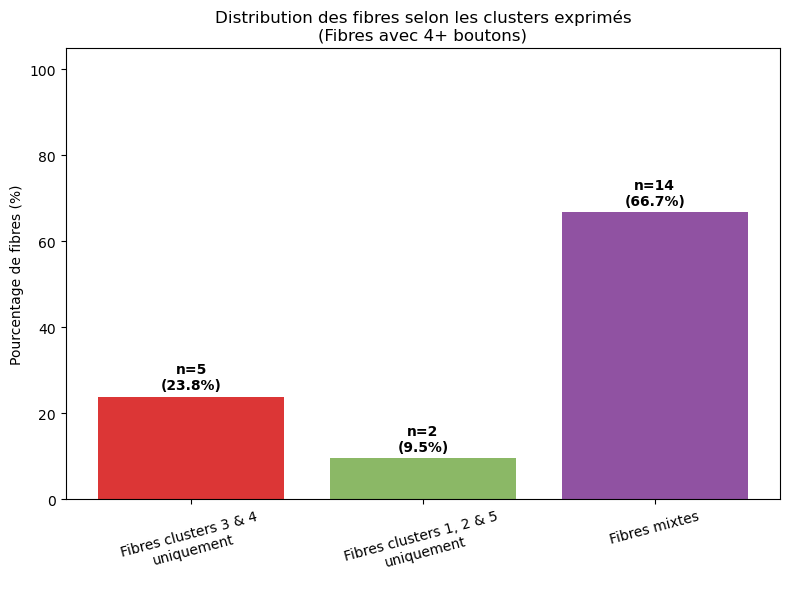

Classification des fibres par types de clusters exprimés (fibres avec 4+ boutons seulement):
- Fibres exprimant uniquement les clusters 3 et/ou 4: 5 fibres (23.8%)
- Fibres exprimant uniquement les clusters 1, 2 et/ou 5: 2 fibres (9.5%)
- Fibres mixtes (combinaison des deux groupes): 14 fibres (66.7%)
- Total: 21 fibres (avec 4+ boutons)

Exemples de fibres mixtes (si il y en a):
  20190801_linescan1_20H: clusters [2, 5]
  241211_Fibre1_PortionA: clusters [3, 4, 5]
  241212_Fibre2_PortionA: clusters [2, 4, 5]
  241212_Fibre1_PortionD: clusters [3, 4, 5]
  20210128_linescan5_20H: clusters [2, 4]
  ... et 9 autres fibres mixtes

Détail des fibres clusters 3 & 4 uniquement:
  20210304_linescan2_20H: clusters [4, 5]
  20210308_linescan2_20H: clusters [4, 5]
  20210310_linescan1_20H: clusters [4, 5]
  20220426_linescan1_20H: clusters [4, 5]
  20240227_linescan2_20H: clusters [4, 5]

Détail des fibres clusters 1, 2 & 5 uniquement:
  20210128_linescan4_20H: clusters [3]
  20220414_linescan1_2

In [453]:
# Classification des fibres selon les clusters exprimés
# Utiliser seulement les fibres avec 4+ boutons (comme dans l'analyse précédente)
fibers_clusters = df_filtered.groupby('Fiber_ID')['HC_UMAP'].apply(lambda x: set(x.unique()))

# Fibres n'exprimant QUE les clusters 3 et/ou 4 (aucun autre cluster)
fibers_only_3_4 = fibers_clusters[fibers_clusters.apply(lambda s: s.issubset({4, 5}) and len(s) > 0)]

# Fibres n'exprimant QUE les clusters 1, 2 et/ou 5 (aucun autre cluster)
fibers_only_1_2_5 = fibers_clusters[fibers_clusters.apply(lambda s: s.issubset({1, 2, 3}) and len(s) > 0)]

# Comptage
count_only_3_4 = len(fibers_only_3_4)
count_only_1_2_5 = len(fibers_only_1_2_5)

# Fibres mixtes (contenant des clusters des deux groupes)
all_fiber_ids = set(fibers_clusters.index)
exclusive_fiber_ids = set(fibers_only_3_4.index) | set(fibers_only_1_2_5.index)
mixed_fibers = all_fiber_ids - exclusive_fiber_ids
count_mixed = len(mixed_fibers)

# Calcul des pourcentages
total_fibers_filtered = len(fibers_clusters)
percentage_3_4 = (count_only_3_4 / total_fibers_filtered) * 100
percentage_1_2_5 = (count_only_1_2_5 / total_fibers_filtered) * 100
percentage_mixed = (count_mixed / total_fibers_filtered) * 100

# Création de l'histogramme avec 3 catégories
labels = ['Fibres clusters 3 & 4\nuniquement', 'Fibres clusters 1, 2 & 5\nuniquement', 'Fibres mixtes']
counts = [count_only_3_4, count_only_1_2_5, count_mixed]
percentages = [percentage_3_4, percentage_1_2_5, percentage_mixed]


plt.figure(figsize=(8,6))
bars = plt.bar(labels, percentages, color=["#d40404", "#6ea740fd", "#74278BFF"], alpha=0.8)
for bar, count, pct in zip(bars, counts, percentages):
    plt.text(bar.get_x() + bar.get_width()/2, pct + 1, 
             f'n={count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Pourcentage de fibres (%)')
plt.title('Distribution des fibres selon les clusters exprimés\n(Fibres avec 4+ boutons)')
plt.xticks(rotation=15)
plt.ylim(0, 105)  # Limiter l'axe Y de 0 à 105%
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "31_fiber_distribution_by_cluster_type.pdf"))
plt.show()

# Affichage des statistiques détaillées
print(f"Classification des fibres par types de clusters exprimés (fibres avec 4+ boutons seulement):")
print(f"- Fibres exprimant uniquement les clusters 3 et/ou 4: {count_only_3_4} fibres ({percentage_3_4:.1f}%)")
print(f"- Fibres exprimant uniquement les clusters 1, 2 et/ou 5: {count_only_1_2_5} fibres ({percentage_1_2_5:.1f}%)")
print(f"- Fibres mixtes (combinaison des deux groupes): {count_mixed} fibres ({percentage_mixed:.1f}%)")
print(f"- Total: {total_fibers_filtered} fibres (avec 4+ boutons)")

# Vérification que toutes les fibres sont bien comptées
assert count_only_3_4 + count_only_1_2_5 + count_mixed == total_fibers_filtered, "Erreur: toutes les fibres ne sont pas comptées"

print(f"\nExemples de fibres mixtes (si il y en a):")
if count_mixed > 0:
    for i, fiber_id in enumerate(list(mixed_fibers)[:5]):  # Afficher les 5 premières
        clusters_in_fiber = list(fibers_clusters[fiber_id])
        print(f"  {fiber_id}: clusters {clusters_in_fiber}")
    if count_mixed > 5:
        print(f"  ... et {count_mixed - 5} autres fibres mixtes")
else:
    print("  Aucune fibre mixte détectée")

# Affichage détaillé des fibres de chaque catégorie
print(f"\nDétail des fibres clusters 3 & 4 uniquement:")
for fiber_id in fibers_only_3_4.index:
    clusters_in_fiber = list(fibers_clusters[fiber_id])
    print(f"  {fiber_id}: clusters {clusters_in_fiber}")

print(f"\nDétail des fibres clusters 1, 2 & 5 uniquement:")
for fiber_id in fibers_only_1_2_5.index:
    clusters_in_fiber = list(fibers_clusters[fiber_id])
    print(f"  {fiber_id}: clusters {clusters_in_fiber}")

# 5 - Calcium


## 5.A High and low calcium data projected on the PCA

Connecting 21 bouton pairs between 1.5Ca and 4Ca datasets using position matching


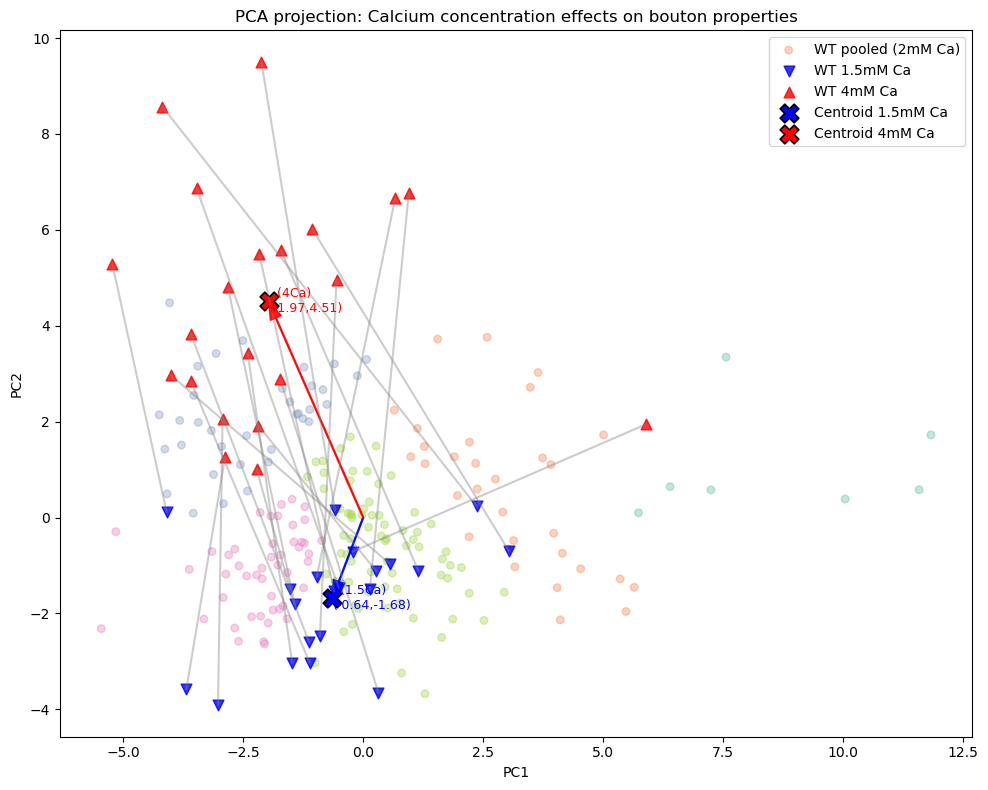

Mouvements dans l'espace PCA lors du changement de calcium:
1.5mM Ca (n=21):
  Distance moyenne: 3.786
  Écart-type: 2.030
  Min-Max: 0.862 - 8.589

4mM Ca (n=21):
  Distance moyenne: 7.227
  Écart-type: 2.917
  Min-Max: 2.804 - 14.294

Mouvements entre 1.5mM Ca et 4mM Ca (boutons appariés, n=21):
  Distance moyenne: 6.845
  Écart-type: 1.760
  Min-Max: 2.595 - 10.604

Centroid coordinates:
  WT pooled (2mM): (-0.000, 0.000)
  1.5mM Ca:       (-0.640, -1.684)  dist from pooled = 1.802
  4mM Ca:         (-1.970, 4.506)  dist from pooled = 4.918


In [454]:
# Projection des données calcium sur la PCA - Figure unique
plt.figure(figsize=(10, 8))

# Plot background WT pooled data
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], 
           c=colors_umap, alpha=0.4, s=30, label='WT pooled (2mM Ca)')

# Plot 1.5mM Ca data with blue triangles (v)
plt.scatter(transformed_WT_1_5Ca['PC1'], transformed_WT_1_5Ca['PC2'], 
           marker='v', s=60, c='blue', alpha=0.8, label='WT 1.5mM Ca')

# Plot 4mM Ca data with red triangles (^)
plt.scatter(transformed_WT_4Ca['PC1'], transformed_WT_4Ca['PC2'], 
           marker='^', s=60, c='red', alpha=0.8, label='WT 4mM Ca')

# --- Centroids & vectors ---
center_pooled = transformed_WT_pooled[['PC1','PC2']].mean()
center_15 = transformed_WT_1_5Ca[['PC1','PC2']].mean()
center_4 = transformed_WT_4Ca[['PC1','PC2']].mean()

# Centroid markers
plt.scatter(center_15['PC1'], center_15['PC2'], marker='X', s=180, c='blue', edgecolor='k', linewidth=1.2, label='Centroid 1.5mM Ca')
plt.scatter(center_4['PC1'], center_4['PC2'], marker='X', s=180, c='red', edgecolor='k', linewidth=1.2, label='Centroid 4mM Ca')

# Optional pooled centroid (not requested to display as point, uncomment if needed)
# plt.scatter(center_pooled['PC1'], center_pooled['PC2'], marker='X', s=140, c='black', edgecolor='k', linewidth=1.2, label='Centroid 2mM Ca')

# Arrows (vectors) from pooled centroid to each calcium condition centroid
plt.arrow(center_pooled['PC1'], center_pooled['PC2'],
          center_15['PC1']-center_pooled['PC1'], center_15['PC2']-center_pooled['PC2'],
          color='blue', width=0.02, head_width=0.25, length_includes_head=True, alpha=0.9)
plt.arrow(center_pooled['PC1'], center_pooled['PC2'],
          center_4['PC1']-center_pooled['PC1'], center_4['PC2']-center_pooled['PC2'],
          color='red', width=0.02, head_width=0.25, length_includes_head=True, alpha=0.9)

# Annotate centroid coordinates
plt.text(center_15['PC1'], center_15['PC2'], f"  (1.5Ca)\n({center_15['PC1']:.2f},{center_15['PC2']:.2f})", color='blue', fontsize=9, ha='left', va='center')
plt.text(center_4['PC1'], center_4['PC2'], f"  (4Ca)\n({center_4['PC1']:.2f},{center_4['PC2']:.2f})", color='red', fontsize=9, ha='left', va='center')

# Draw lines connecting same boutons between 1.5Ca and 4Ca (purple lines)
# Use position-based matching since boutons are organized in the same order
n_boutons = min(len(transformed_WT_1_5Ca), len(transformed_WT_4Ca))
print(f"Connecting {n_boutons} bouton pairs between 1.5Ca and 4Ca datasets using position matching")

for i in range(n_boutons):
    plt.plot([transformed_WT_1_5Ca.iloc[i]['PC1'], transformed_WT_4Ca.iloc[i]['PC1']],
             [transformed_WT_1_5Ca.iloc[i]['PC2'], transformed_WT_4Ca.iloc[i]['PC2']],
             'grey', alpha=0.4, linewidth=1.5)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection: Calcium concentration effects on bouton properties')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "32_calcium_trajectories_PCA.pdf"))
plt.show()

# Calculate and display movement statistics
movements_1_5Ca = []
movements_4Ca = []

for i in range(min(len(transformed_WT_pooled), len(transformed_WT_1_5Ca))):
    dist = np.sqrt((transformed_WT_pooled.iloc[i]['PC1'] - transformed_WT_1_5Ca.iloc[i]['PC1'])**2 + 
                   (transformed_WT_pooled.iloc[i]['PC2'] - transformed_WT_1_5Ca.iloc[i]['PC2'])**2)
    movements_1_5Ca.append(dist)

for i in range(min(len(transformed_WT_pooled), len(transformed_WT_4Ca))):
    dist = np.sqrt((transformed_WT_pooled.iloc[i]['PC1'] - transformed_WT_4Ca.iloc[i]['PC1'])**2 + 
                   (transformed_WT_pooled.iloc[i]['PC2'] - transformed_WT_4Ca.iloc[i]['PC2'])**2)
    movements_4Ca.append(dist)

print(f"Mouvements dans l'espace PCA lors du changement de calcium:")
print(f"1.5mM Ca (n={len(movements_1_5Ca)}):")
print(f"  Distance moyenne: {np.mean(movements_1_5Ca):.3f}")
print(f"  Écart-type: {np.std(movements_1_5Ca):.3f}")
print(f"  Min-Max: {np.min(movements_1_5Ca):.3f} - {np.max(movements_1_5Ca):.3f}")

print(f"\n4mM Ca (n={len(movements_4Ca)}):")
print(f"  Distance moyenne: {np.mean(movements_4Ca):.3f}")
print(f"  Écart-type: {np.std(movements_4Ca):.3f}")
print(f"  Min-Max: {np.min(movements_4Ca):.3f} - {np.max(movements_4Ca):.3f}")

# Calculate movement statistics for matched boutons between calcium conditions
calcium_movements = []
for i in range(n_boutons):
    dist = np.sqrt((transformed_WT_1_5Ca.iloc[i]['PC1'] - transformed_WT_4Ca.iloc[i]['PC1'])**2 + 
                   (transformed_WT_1_5Ca.iloc[i]['PC2'] - transformed_WT_4Ca.iloc[i]['PC2'])**2)
    calcium_movements.append(dist)

if calcium_movements:
    print(f"\nMouvements entre 1.5mM Ca et 4mM Ca (boutons appariés, n={len(calcium_movements)}):")
    print(f"  Distance moyenne: {np.mean(calcium_movements):.3f}")
    print(f"  Écart-type: {np.std(calcium_movements):.3f}")
    print(f"  Min-Max: {np.min(calcium_movements):.3f} - {np.max(calcium_movements):.3f}")

# Print centroid coordinates and distances from pooled centroid
from math import sqrt
print("\nCentroid coordinates:")
print(f"  WT pooled (2mM): ({center_pooled['PC1']:.3f}, {center_pooled['PC2']:.3f})")
print(f"  1.5mM Ca:       ({center_15['PC1']:.3f}, {center_15['PC2']:.3f})  dist from pooled = {sqrt((center_15['PC1']-center_pooled['PC1'])**2 + (center_15['PC2']-center_pooled['PC2'])**2):.3f}")
print(f"  4mM Ca:         ({center_4['PC1']:.3f}, {center_4['PC2']:.3f})  dist from pooled = {sqrt((center_4['PC1']-center_pooled['PC1'])**2 + (center_4['PC2']-center_pooled['PC2'])**2):.3f}")

## 5.B Comparison Normal vs Low calcium

### 5.B.a Distribution of AMP1 Normal vs Low calcium

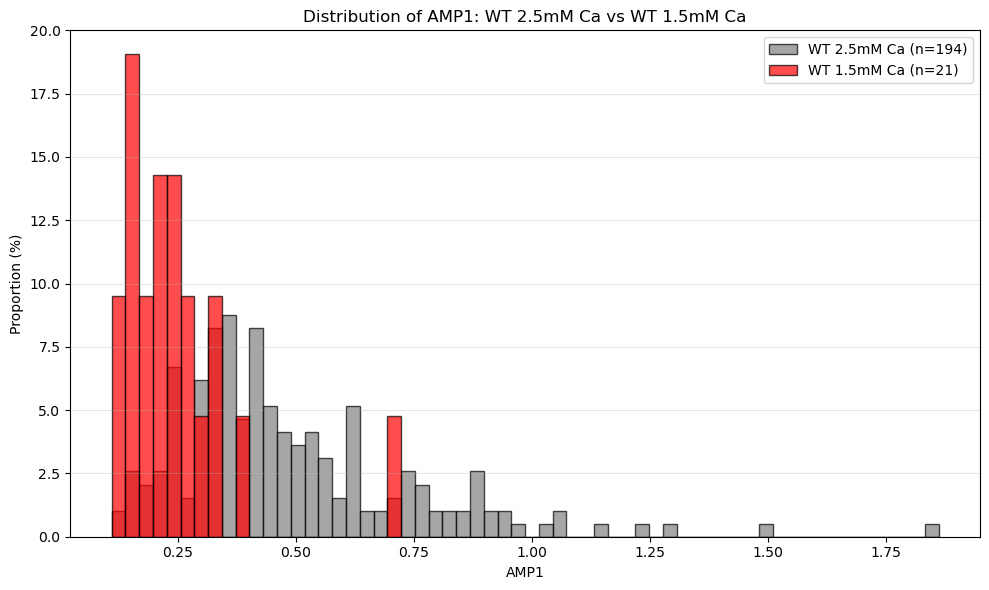

Summary statistics for AMP1:
WT 2.5mM Ca: Mean = 0.489 ± 0.259
WT 1.5mM Ca: Mean = 0.248 ± 0.129


In [455]:
# Histogram comparing AMP1 between WT_pooled (2mM Ca) and WT_1_5Ca (1.5mM Ca)
plt.figure(figsize=(10, 6))

# Calculate bin edges based on combined data
all_amp1_data = pd.concat([df_WT_pooled['AMP1'], df_WT_1_5Ca['AMP1']])
bins = np.linspace(all_amp1_data.min(), all_amp1_data.max(), 61)

# Plot histograms as proportions in percentage
weights_pooled = np.ones(len(df_WT_pooled['AMP1'])) / len(df_WT_pooled['AMP1']) * 100
weights_1_5Ca = np.ones(len(df_WT_1_5Ca['AMP1'])) / len(df_WT_1_5Ca['AMP1']) * 100

plt.hist(df_WT_pooled['AMP1'], bins=bins, alpha=0.7, color='gray', 
         label=f'WT 2.5mM Ca (n={len(df_WT_pooled)})', weights=weights_pooled, edgecolor='black')
plt.hist(df_WT_1_5Ca['AMP1'], bins=bins, alpha=0.7, color='red', 
         label=f'WT 1.5mM Ca (n={len(df_WT_1_5Ca)})', weights=weights_1_5Ca, edgecolor='black')

plt.xlabel('AMP1')
plt.ylabel('Proportion (%)')
plt.title('Distribution of AMP1: WT 2.5mM Ca vs WT 1.5mM Ca')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "33_AMP1_histogram_2_5mM_vs_1_5mM_Ca.pdf"))
plt.show()

# Print summary statistics
print("Summary statistics for AMP1:")
print(f"WT 2.5mM Ca: Mean = {df_WT_pooled['AMP1'].mean():.3f} ± {df_WT_pooled['AMP1'].std():.3f}")
print(f"WT 1.5mM Ca: Mean = {df_WT_1_5Ca['AMP1'].mean():.3f} ± {df_WT_1_5Ca['AMP1'].std():.3f}")

### 5.B.b Distribution of %Fail1 Normal vs Low calcium

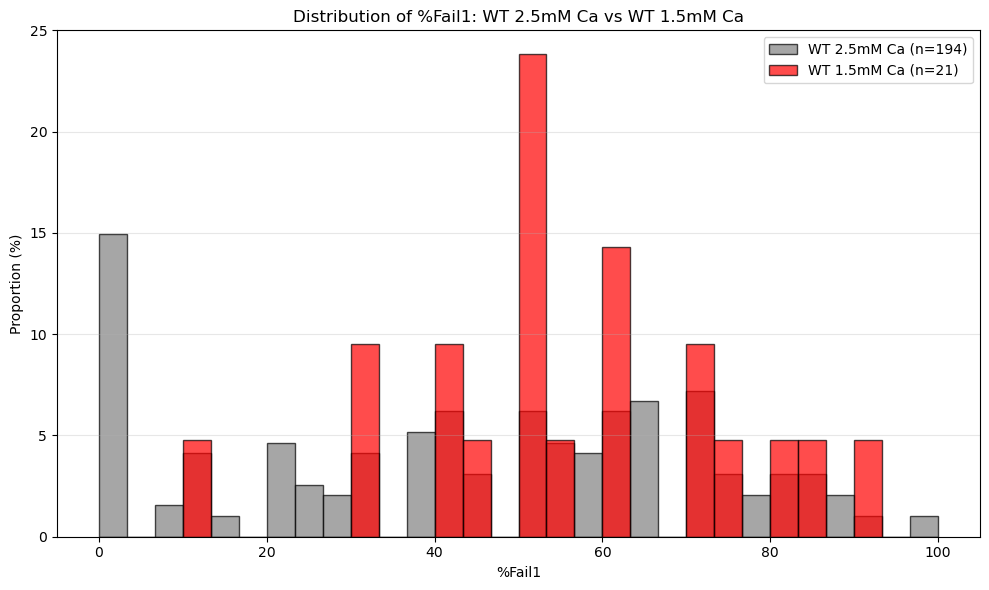

Summary statistics for %Fail1:
WT 2.5mM Ca: Mean = 44.353 ± 27.854
WT 1.5mM Ca: Mean = 54.960 ± 19.255


In [456]:
# Histogram comparing %Fail1 between WT_pooled (2mM Ca) and WT_1_5Ca (1.5mM Ca)
plt.figure(figsize=(10, 6))

# Calculate bin edges based on combined data
all_fail1_data = pd.concat([df_WT_pooled['%Fail1'], df_WT_1_5Ca['%Fail1']])
bins = np.linspace(all_fail1_data.min(), all_fail1_data.max(), 31)

# Plot histograms as proportions in percentage
weights_pooled = np.ones(len(df_WT_pooled['%Fail1'])) / len(df_WT_pooled['%Fail1']) * 100
weights_1_5Ca = np.ones(len(df_WT_1_5Ca['%Fail1'])) / len(df_WT_1_5Ca['%Fail1']) * 100

plt.hist(df_WT_pooled['%Fail1'], bins=bins, alpha=0.7, color='gray', 
         label=f'WT 2.5mM Ca (n={len(df_WT_pooled)})', weights=weights_pooled, edgecolor='black')
plt.hist(df_WT_1_5Ca['%Fail1'], bins=bins, alpha=0.7, color='red', 
         label=f'WT 1.5mM Ca (n={len(df_WT_1_5Ca)})', weights=weights_1_5Ca, edgecolor='black')

plt.xlabel('%Fail1')
plt.ylabel('Proportion (%)')
plt.title('Distribution of %Fail1: WT 2.5mM Ca vs WT 1.5mM Ca')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "34_Fail1_histogram_2_5mM_vs_1_5mM_Ca.pdf"))
plt.show()

# Print summary statistics
print("Summary statistics for %Fail1:")
print(f"WT 2.5mM Ca: Mean = {df_WT_pooled['%Fail1'].mean():.3f} ± {df_WT_pooled['%Fail1'].std():.3f}")
print(f"WT 1.5mM Ca: Mean = {df_WT_1_5Ca['%Fail1'].mean():.3f} ± {df_WT_1_5Ca['%Fail1'].std():.3f}")

### 5.B.c Boxplots Normal vs Low calcium

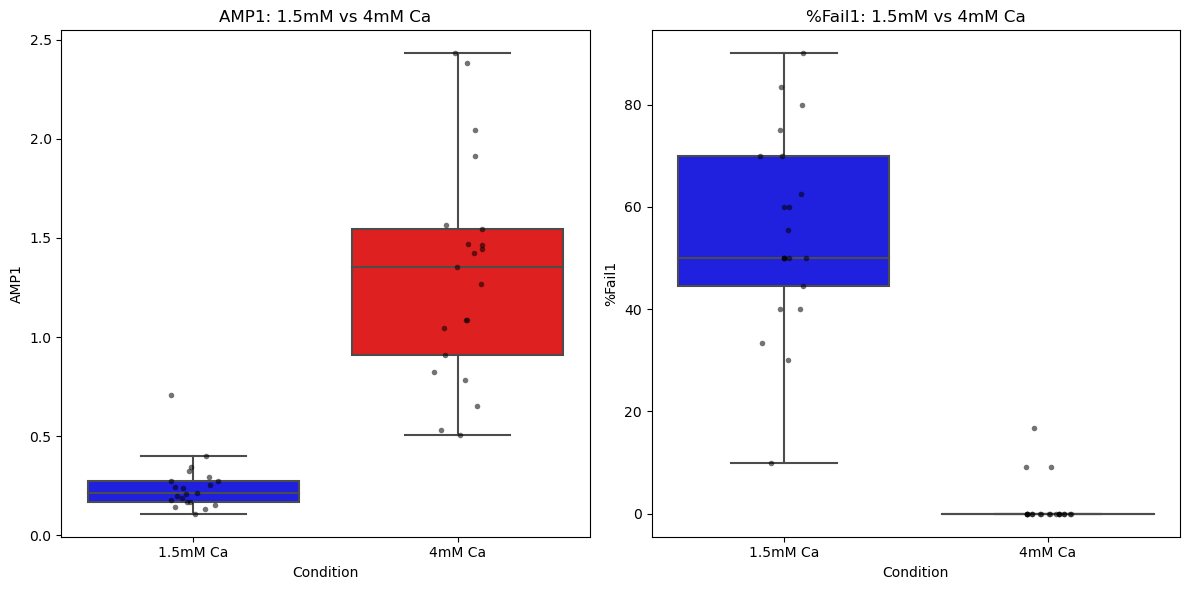

Statistical comparison between 1.5mM Ca and 4mM Ca conditions:

AMP1:
1.5mM Ca (n=21): 0.248 ± 0.129
4mM Ca (n=21): 1.321 ± 0.549
Mann-Whitney U test: U = 3.000, p = 4.793751861055e-08
Significance: ***

%Fail1:
1.5mM Ca (n=21): 54.960 ± 19.255
4mM Ca (n=21): 1.659 ± 4.389
Mann-Whitney U test: U = 440.000, p = 9.187288767857e-09
Significance: ***

Fichier sauvegardé: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\35_calcium_boxplot_comparison_statistics.txt
Copie également sauvegardée: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\2_Traces_SynII_WTAnthime_WTTheo.txt


In [457]:
from scipy.stats import mannwhitneyu

# Boxplots + tous les points individuels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Préparation des DataFrames
amp1_data = pd.DataFrame({
    'AMP1': pd.concat([df_WT_1_5Ca['AMP1'], df_WT_4Ca['AMP1']], ignore_index=True),
    'Condition': ['1.5mM Ca'] * len(df_WT_1_5Ca) + ['4mM Ca'] * len(df_WT_4Ca)
})
fail1_data = pd.DataFrame({
    '%Fail1': pd.concat([df_WT_1_5Ca['%Fail1'], df_WT_4Ca['%Fail1']], ignore_index=True),
    'Condition': ['1.5mM Ca'] * len(df_WT_1_5Ca) + ['4mM Ca'] * len(df_WT_4Ca)
})

# AMP1
sns.boxplot(data=amp1_data, x='Condition', y='AMP1', ax=ax1, palette=['blue', 'red'],
            showcaps=True, fliersize=0)
sns.stripplot(data=amp1_data, x='Condition', y='AMP1', ax=ax1,
              color='black', size=4, alpha=0.55, dodge=False)
ax1.set_title('AMP1: 1.5mM vs 4mM Ca')
ax1.set_ylabel('AMP1')

# %Fail1
sns.boxplot(data=fail1_data, x='Condition', y='%Fail1', ax=ax2, palette=['blue', 'red'],
            showcaps=True, fliersize=0)
sns.stripplot(data=fail1_data, x='Condition', y='%Fail1', ax=ax2,
              color='black', size=4, alpha=0.55, dodge=False)
ax2.set_title('%Fail1: 1.5mM vs 4mM Ca')
ax2.set_ylabel('%Fail1')

# Tests statistiques
amp1_stat, amp1_p = mannwhitneyu(df_WT_1_5Ca['AMP1'], df_WT_4Ca['AMP1'], alternative='two-sided')
fail1_stat, fail1_p = mannwhitneyu(df_WT_1_5Ca['%Fail1'], df_WT_4Ca['%Fail1'], alternative='two-sided')



plt.tight_layout()
plt.savefig(os.path.join(output_dir, "35_calcium_boxplot_comparison.pdf"))
plt.show()

# Résultats texte (on garde les p-values dans le fichier et la console)
results_text = []
results_text.append("Statistical comparison between 1.5mM Ca and 4mM Ca conditions:")
results_text.append("=" * 60)
results_text.append("\nAMP1:")
results_text.append(f"1.5mM Ca (n={len(df_WT_1_5Ca)}): {df_WT_1_5Ca['AMP1'].mean():.3f} ± {df_WT_1_5Ca['AMP1'].std():.3f}")
results_text.append(f"4mM Ca (n={len(df_WT_4Ca)}): {df_WT_4Ca['AMP1'].mean():.3f} ± {df_WT_4Ca['AMP1'].std():.3f}")
results_text.append(f"Mann-Whitney U test: U = {amp1_stat:.3f}, p = {amp1_p:.12e}")
results_text.append(f"Significance: {'***' if amp1_p < 0.001 else '**' if amp1_p < 0.01 else '*' if amp1_p < 0.05 else 'ns'}")
results_text.append("\n%Fail1:")
results_text.append(f"1.5mM Ca (n={len(df_WT_1_5Ca)}): {df_WT_1_5Ca['%Fail1'].mean():.3f} ± {df_WT_1_5Ca['%Fail1'].std():.3f}")
results_text.append(f"4mM Ca (n={len(df_WT_4Ca)}): {df_WT_4Ca['%Fail1'].mean():.3f} ± {df_WT_4Ca['%Fail1'].std():.3f}")
results_text.append(f"Mann-Whitney U test: U = {fail1_stat:.3f}, p = {fail1_p:.12e}")
results_text.append(f"Significance: {'***' if fail1_p < 0.001 else '**' if fail1_p < 0.01 else '*' if fail1_p < 0.05 else 'ns'}")

for line in results_text:
    print(line)

stats_path = os.path.join(output_dir, "35_calcium_boxplot_comparison_statistics.txt")
with open(stats_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(results_text))
print(f"\nFichier sauvegardé: {stats_path}")

if 'txt_path' in locals():
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write("Résultats statistiques calcium\n")
        f.write('\n'.join(results_text))
    print(f"Copie également sauvegardée: {txt_path}")

## 5.C Mean PPR profile for all calcium concentration

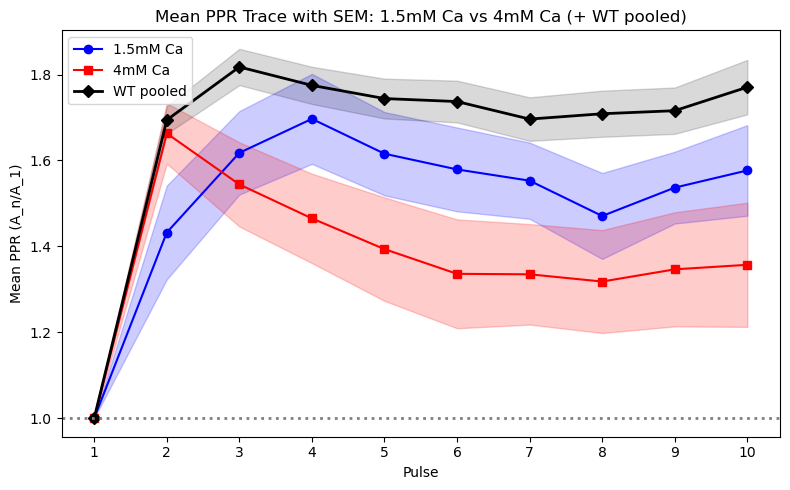

In [458]:
# Plot mean PPR trace with SEM for 4Ca and 1.5Ca, and add WT_pooled in black
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_WT_1_5Ca.columns]
x_pulses = list(range(1, len(ppr_cols) + 2))  # 1 to 10

# Calculate means and SEMs for 1.5Ca
means_1_5Ca = [1] + df_WT_1_5Ca[ppr_cols].mean().tolist()
sems_1_5Ca = [0] + df_WT_1_5Ca[ppr_cols].sem().tolist()

# Calculate means and SEMs for 4Ca
means_4Ca = [1] + df_WT_4Ca[ppr_cols].mean().tolist()
sems_4Ca = [0] + df_WT_4Ca[ppr_cols].sem().tolist()

# Calculate means and SEMs for WT_pooled
means_pooled = [1] + df_WT_pooled[ppr_cols].mean().tolist()
sems_pooled = [0] + df_WT_pooled[ppr_cols].sem().tolist()

plt.figure(figsize=(8, 5))
plt.plot(x_pulses, means_1_5Ca, marker='o', color='blue', label='1.5mM Ca')
plt.fill_between(x_pulses, np.array(means_1_5Ca) - np.array(sems_1_5Ca),
                 np.array(means_1_5Ca) + np.array(sems_1_5Ca), color='blue', alpha=0.2)
plt.plot(x_pulses, means_4Ca, marker='s', color='red', label='4mM Ca')
plt.fill_between(x_pulses, np.array(means_4Ca) - np.array(sems_4Ca),
                 np.array(means_4Ca) + np.array(sems_4Ca), color='red', alpha=0.2)
plt.plot(x_pulses, means_pooled, marker='D', color='black', label='WT pooled', linewidth=2)
plt.fill_between(x_pulses, np.array(means_pooled) - np.array(sems_pooled),
                 np.array(means_pooled) + np.array(sems_pooled), color='black', alpha=0.15)
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.xlabel('Pulse')
plt.ylabel('Mean PPR (A_n/A_1)')
plt.title('Mean PPR Trace with SEM: 1.5mM Ca vs 4mM Ca (+ WT pooled)')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.legend()
plt.tight_layout()
# Save figure and values
fig_path = os.path.join(output_dir, "36_PPR_trace_1_5mM_vs_4mM_Ca.pdf")
plt.savefig(fig_path)
plt.show()

# Save means and SEMs to text file
txt_path = os.path.join(output_dir, "36_PPR_trace_1_5mM_vs_4mM_Ca.txt")
with open(txt_path, "w", encoding="utf-8") as f_txt:
    f_txt.write("Pulse\tMean_1.5mM_Ca\tSEM_1.5mM_Ca\tMean_4mM_Ca\tSEM_4mM_Ca\tMean_WT_pooled\tSEM_WT_pooled\n")
    for i in range(len(x_pulses)):
        f_txt.write(f"{x_pulses[i]}\t{means_1_5Ca[i]:.4f}\t{sems_1_5Ca[i]:.4f}\t{means_4Ca[i]:.4f}\t{sems_4Ca[i]:.4f}\t{means_pooled[i]:.4f}\t{sems_pooled[i]:.4f}\n")

## 5.D High vs Low Traces

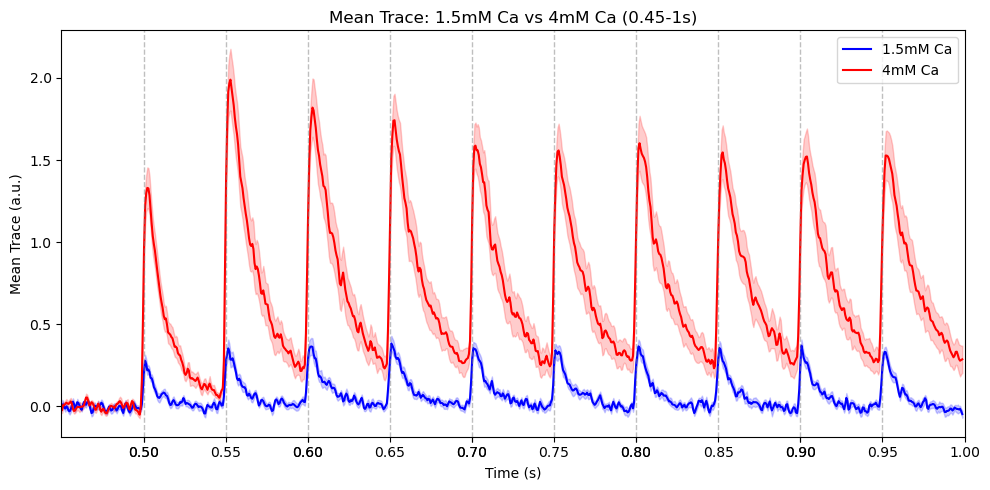

In [459]:
trace_1_5Ca = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx", sheet_name="Theo_1_5Ca")
trace_4Ca   = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx", sheet_name="Theo_4Ca")

# Plot mean trace between 0.45 and 1s for both conditions, with ticks every 0.05s from 0.5s (10 ticks)
# Extract time and traces (ignore first row if it's an ID)
time = trace_1_5Ca.iloc[1:, 0].astype(float).values
traces_1_5Ca = trace_1_5Ca.iloc[1:, 1:].astype(float).values
traces_4Ca = trace_4Ca.iloc[1:, 1:].astype(float).values

mean_1_5Ca = np.mean(traces_1_5Ca, axis=1)
sem_1_5Ca = np.std(traces_1_5Ca, axis=1) / np.sqrt(traces_1_5Ca.shape[1])
mean_4Ca = np.mean(traces_4Ca, axis=1)
sem_4Ca = np.std(traces_4Ca, axis=1) / np.sqrt(traces_4Ca.shape[1])

# Restrict to 0.45-1s
mask = (time >= 0.45) & (time <= 1.0)
time_plot = time[mask]
mean_1_5Ca_plot = mean_1_5Ca[mask]
sem_1_5Ca_plot = sem_1_5Ca[mask]
mean_4Ca_plot = mean_4Ca[mask]
sem_4Ca_plot = sem_4Ca[mask]

plt.figure(figsize=(10, 5))
plt.plot(time_plot, mean_1_5Ca_plot, color='blue', label='1.5mM Ca')
plt.fill_between(time_plot, mean_1_5Ca_plot - sem_1_5Ca_plot, mean_1_5Ca_plot + sem_1_5Ca_plot, color='blue', alpha=0.2)
plt.plot(time_plot, mean_4Ca_plot, color='red', label='4mM Ca')
plt.fill_between(time_plot, mean_4Ca_plot - sem_4Ca_plot, mean_4Ca_plot + sem_4Ca_plot, color='red', alpha=0.2)

# Add ticks every 0.05s from 0.5s (10 ticks)
stim_times = [0.5 + 0.05 * i for i in range(10)]
for stim in stim_times:
    plt.axvline(stim, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.xticks(list(plt.xticks()[0]) + stim_times)
plt.xlim(0.45, 1.0)
plt.xlabel('Time (s)')
plt.ylabel('Mean Trace (a.u.)')
plt.title('Mean Trace: 1.5mM Ca vs 4mM Ca (0.45-1s)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "37_mean_trace_1_5mM_vs_4mM_Ca.pdf"))
plt.show()

## 5.E Scatterplots

### 5.E.a PPR A2/A1 against A1

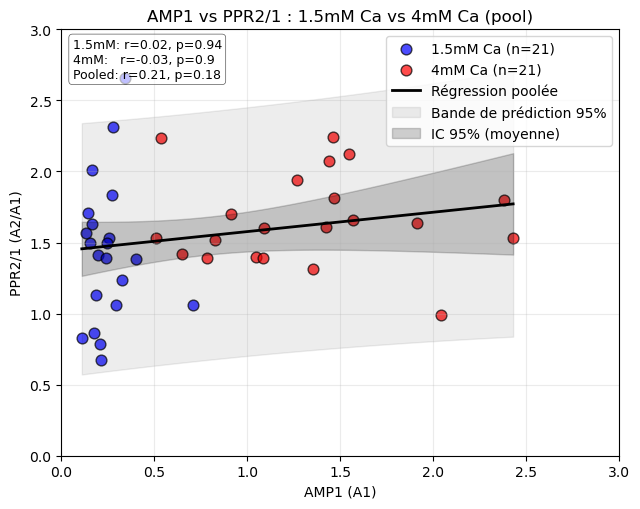

Figure saved to: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\38_scatter_AMP1_vs_PPR2_1_calcium_pooled_CI_PI.pdf
1.5mM: r=0.02, p=0.94 | 4mM:   r=-0.03, p=0.9 | Pooled: r=0.21, p=0.18
Statistiques Pearson sauvegardées: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\38_scatter_AMP1_vs_PPR2_1_calcium_pearson_stats.txt


In [460]:
from scipy.stats import pearsonr, t  # pearsonr déjà utilisé; ajout de t pour intervalles

# Scatter plot AMP1 (x) vs PPR2/1 (y) pour 1.5mM Ca et 4mM Ca
data_15 = df_WT_1_5Ca[['AMP1', 'PPR2/1']].dropna()
data_4  = df_WT_4Ca[['AMP1', 'PPR2/1']].dropna()

x15, y15 = data_15['AMP1'].values, data_15['PPR2/1'].values
x4,  y4  = data_4['AMP1'].values,  data_4['PPR2/1'].values

# Corrélations séparées
r15, p15 = pearsonr(x15, y15) if len(x15) > 1 else (float('nan'), float('nan'))
r4,  p4  = pearsonr(x4,  y4)  if len(x4)  > 1 else (float('nan'), float('nan'))

# Pool
x_all = np.concatenate([x15, x4])
y_all = np.concatenate([y15, y4])
n_all = len(x_all)

if n_all > 2:
    slope, intercept = np.polyfit(x_all, y_all, 1)
    y_hat_all = intercept + slope * x_all
    resid = y_all - y_hat_all
    Sxx = np.sum((x_all - x_all.mean())**2)
    s = np.sqrt(np.sum(resid**2) / (n_all - 2))
    x_grid = np.linspace(x_all.min(), x_all.max(), 300)
    y_grid = intercept + slope * x_grid
    alpha = 0.05
    tcrit = t.ppf(1 - alpha/2, df=n_all - 2)
    se_mean = s * np.sqrt(1/n_all + (x_grid - x_all.mean())**2 / Sxx)
    ci_low = y_grid - tcrit * se_mean
    ci_high = y_grid + tcrit * se_mean
    se_pred = s * np.sqrt(1 + 1/n_all + (x_grid - x_all.mean())**2 / Sxx)
    pi_low = y_grid - tcrit * se_pred
    pi_high = y_grid + tcrit * se_pred
    r_pool, p_pool = pearsonr(x_all, y_all)
else:
    slope = intercept = np.nan
    r_pool = p_pool = np.nan

plt.figure(figsize=(6.5,5.2))
plt.scatter(x15, y15, c='blue', alpha=0.7, edgecolor='k', s=60, label=f'1.5mM Ca (n={len(x15)})')
plt.scatter(x4,  y4,  c='red',  alpha=0.7, edgecolor='k', s=60, label=f'4mM Ca (n={len(x4)})')

# Régression poolée + IC + bande de prédiction
if n_all > 2:
    plt.plot(x_grid, y_grid, color='black', lw=2, label='Régression poolée')
    plt.fill_between(x_grid, pi_low, pi_high, color='black', alpha=0.07, label='Bande de prédiction 95%')
    plt.fill_between(x_grid, ci_low, ci_high, color='black', alpha=0.18, label='IC 95% (moyenne)')

plt.xlabel('AMP1 (A1)')
plt.ylabel('PPR2/1 (A2/A1)')
plt.title('AMP1 vs PPR2/1 : 1.5mM Ca vs 4mM Ca (pool)')
plt.grid(alpha=0.25)
plt.ylim(0, 3)
plt.xlim(0, 3)

annot = (f"1.5mM: r={r15:.2f}, p={p15:.2g}\n"
         f"4mM:   r={r4:.2f}, p={p4:.2g}\n"
         f"Pooled: r={r_pool:.2f}, p={p_pool:.2g}")
plt.gca().text(0.02, 0.98, annot, ha='left', va='top', transform=plt.gca().transAxes,
               fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.65, lw=0.5))

handles, labels = plt.gca().get_legend_handles_labels()
seen = set()
handles_unique, labels_unique = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        handles_unique.append(h)
        labels_unique.append(l)
        seen.add(l)
plt.legend(handles_unique, labels_unique, loc='best')

out_path = os.path.join(output_dir, "38_scatter_AMP1_vs_PPR2_1_calcium_pooled_CI_PI.pdf")
plt.tight_layout()
plt.savefig(out_path)
plt.show()

print(f"Figure saved to: {out_path}")
print(annot.replace('\n', ' | '))

# Sauvegarde des résultats Pearson dans un fichier texte
stats_lines = [
    "Pearson correlation AMP1 vs PPR2/1",
    f"1.5mM Ca: r={r15:.6f}, p={p15:.6g}, n={len(x15)}",
    f"4mM Ca:  r={r4:.6f}, p={p4:.6g}, n={len(x4)}",
    f"Pooled : r={r_pool:.6f}, p={p_pool:.6g}, n={n_all}"
]
pearson_path = os.path.join(output_dir, "38_scatter_AMP1_vs_PPR2_1_calcium_pearson_stats.txt")
with open(pearson_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(stats_lines))
print(f"Statistiques Pearson sauvegardées: {pearson_path}")


### 5.E.b PPR A2/A1 against Failure rate 1

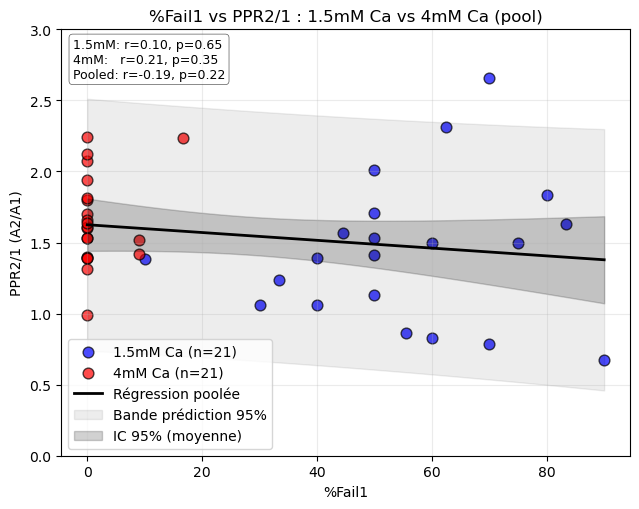

Figure saved to: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\39_scatter_Fail1_vs_PPR2_1_calcium_pooled_CI_PI.pdf
1.5mM: r=0.10, p=0.65 | 4mM:   r=0.21, p=0.35 | Pooled: r=-0.19, p=0.22
Statistiques Pearson sauvegardées: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\39_scatter_Fail1_vs_PPR2_1_calcium_pearson_stats.txt


In [461]:
# Scatter plot %Fail1 (x) vs PPR2/1 (y) pour 1.5mM Ca et 4mM Ca

data_15 = df_WT_1_5Ca[['%Fail1', 'PPR2/1']].dropna()
data_4  = df_WT_4Ca[['%Fail1', 'PPR2/1']].dropna()

x15, y15 = data_15['%Fail1'].values, data_15['PPR2/1'].values
x4,  y4  = data_4['%Fail1'].values,  data_4['PPR2/1'].values

# Corrélations séparées
r15, p15 = pearsonr(x15, y15) if len(x15) > 1 else (float('nan'), float('nan'))
r4,  p4  = pearsonr(x4,  y4)  if len(x4)  > 1 else (float('nan'), float('nan'))

# Pool
x_all = np.concatenate([x15, x4])
y_all = np.concatenate([y15, y4])
n_all = len(x_all)

if n_all > 2:
    slope, intercept = np.polyfit(x_all, y_all, 1)
    y_hat_all = intercept + slope * x_all
    resid = y_all - y_hat_all
    Sxx = np.sum((x_all - x_all.mean())**2)
    s = np.sqrt(np.sum(resid**2) / (n_all - 2))
    x_grid = np.linspace(x_all.min(), x_all.max(), 300)
    y_grid = intercept + slope * x_grid
    alpha = 0.05
    tcrit = t.ppf(1 - alpha/2, df=n_all - 2)
    se_mean = s * np.sqrt(1/n_all + (x_grid - x_all.mean())**2 / Sxx)
    ci_low = y_grid - tcrit * se_mean
    ci_high = y_grid + tcrit * se_mean
    se_pred = s * np.sqrt(1 + 1/n_all + (x_grid - x_all.mean())**2 / Sxx)
    pi_low = y_grid - tcrit * se_pred
    pi_high = y_grid + tcrit * se_pred
    r_pool, p_pool = pearsonr(x_all, y_all)
else:
    slope = intercept = np.nan
    r_pool = p_pool = np.nan

plt.figure(figsize=(6.5,5.2))
plt.scatter(x15, y15, c='blue', alpha=0.7, edgecolor='k', s=60, label=f'1.5mM Ca (n={len(x15)})')
plt.scatter(x4,  y4,  c='red',  alpha=0.7, edgecolor='k', s=60, label=f'4mM Ca (n={len(x4)})')

if n_all > 2:
    plt.plot(x_grid, y_grid, color='black', lw=2, label='Régression poolée')
    plt.fill_between(x_grid, pi_low, pi_high, color='black', alpha=0.07, label='Bande prédiction 95%')
    plt.fill_between(x_grid, ci_low, ci_high, color='black', alpha=0.18, label='IC 95% (moyenne)')

plt.xlabel('%Fail1')
plt.ylabel('PPR2/1 (A2/A1)')
plt.title('%Fail1 vs PPR2/1 : 1.5mM Ca vs 4mM Ca (pool)')
plt.grid(alpha=0.25)

xmin, xmax = x_all.min(), x_all.max()
xpad = 0.05 * (xmax - xmin) if xmax > xmin else 1
plt.xlim(xmin - xpad, xmax + xpad)
plt.ylim(0, 3)

annot = (f"1.5mM: r={r15:.2f}, p={p15:.2g}\n"
         f"4mM:   r={r4:.2f}, p={p4:.2g}\n"
         f"Pooled: r={r_pool:.2f}, p={p_pool:.2g}")
plt.gca().text(0.02, 0.98, annot, ha='left', va='top',
               transform=plt.gca().transAxes, fontsize=9,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.65, lw=0.5))

handles, labels = plt.gca().get_legend_handles_labels()
seen = set()
h_u, l_u = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        h_u.append(h); l_u.append(l); seen.add(l)
plt.legend(h_u, l_u, loc='best')

out_path = os.path.join(output_dir, "39_scatter_Fail1_vs_PPR2_1_calcium_pooled_CI_PI.pdf")
plt.tight_layout()
plt.savefig(out_path)
plt.show()

print(f"Figure saved to: {out_path}")
print(annot.replace('\n', ' | '))

# Sauvegarde des résultats Pearson dans un fichier texte
stats_lines = [
    "Pearson correlation %Fail1 vs PPR2/1",
    f"1.5mM Ca: r={r15:.6f}, p={p15:.6g}, n={len(x15)}",
    f"4mM Ca:  r={r4:.6f}, p={p4:.6g}, n={len(x4)}",
    f"Pooled : r={r_pool:.6f}, p={p_pool:.6g}, n={n_all}"
]
pearson_path = os.path.join(output_dir, "39_scatter_Fail1_vs_PPR2_1_calcium_pearson_stats.txt")
with open(pearson_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(stats_lines))
print(f"Statistiques Pearson sauvegardées: {pearson_path}")


# 6 - Stability experiment


## 6.A Cluster attribution

### 6.A.a Stability data (before and after) projected on the PCA

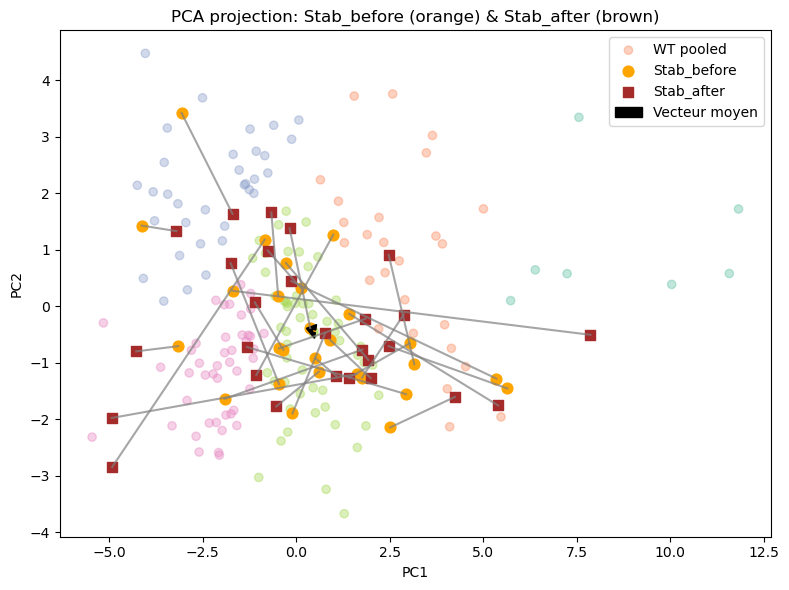

In [462]:
plt.figure(figsize=(8, 6))
# Plot WT pooled background with cluster colors
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')

# Plot Stab_before (orange)
plt.scatter(transformed_stab_before['PC1'], transformed_stab_before['PC2'], marker='o', s=60, c='orange', label='Stab_before')

# Plot Stab_after (brown)
plt.scatter(transformed_stab_after['PC1'], transformed_stab_after['PC2'], marker='s', s=60, c='brown', label='Stab_after')

# Ajoute des lignes reliant les mêmes boutons (même ID dans before et after)
for i in range(min(len(transformed_stab_before), len(transformed_stab_after))):
    plt.plot(
        [transformed_stab_before.iloc[i]['PC1'], transformed_stab_after.iloc[i]['PC1']],
        [transformed_stab_before.iloc[i]['PC2'], transformed_stab_after.iloc[i]['PC2']],
        color='gray', alpha=0.7, linewidth=1.5
    )

# Calcul du vecteur moyen de déplacement
delta = transformed_stab_after.values - transformed_stab_before.values
mean_delta = delta.mean(axis=0)

# Calcul du centre moyen (tous points before+after)
all_points = np.vstack([transformed_stab_before.values, transformed_stab_after.values])
center = all_points.mean(axis=0)

# Ajoute le vecteur moyen centré sur la position moyenne
plt.arrow(center[0], center[1], mean_delta[0], mean_delta[1], 
          color='black', width=0.05, head_width=0.25, head_length=0.25, length_includes_head=True, label='Vecteur moyen')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection: Stab_before (orange) & Stab_after (brown)')
plt.legend()
plt.tight_layout()
plt.show()



### 6.A.b Pieplot Stable vs Unstable

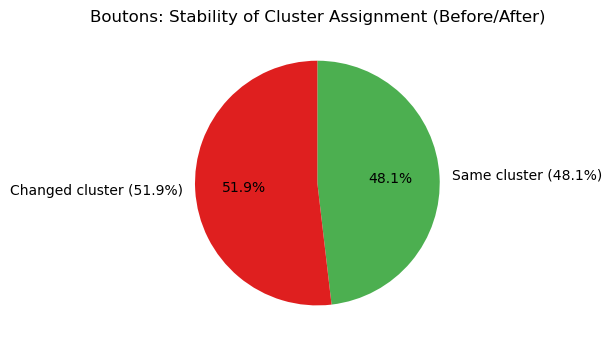

In [463]:
clusters_before = assign_clusters_robust(transformed_data_WT_pooled, hc_labels, transformed_stab_before.values, method='single')
clusters_after = assign_clusters_robust(transformed_data_WT_pooled, hc_labels, transformed_stab_after.values, method='single')

# Calculate percentage of boutons that remain in the same cluster vs those that change (before/after)
same_cluster = np.sum(clusters_before == clusters_after)
diff_cluster = np.sum(clusters_before != clusters_after)
total = len(clusters_before)

percent_same = 100 * same_cluster / total
percent_diff = 100 * diff_cluster / total

# Pie chart (camembert)
labels = [f"Same cluster ({percent_same:.1f}%)", f"Changed cluster ({percent_diff:.1f}%)"]
sizes = [percent_same, percent_diff]
colors = ['#4CAF50', "#DF1F1F"]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%.1f%%', startangle=90, counterclock=False)
plt.title("Boutons: Stability of Cluster Assignment (Before/After)")
plt.tight_layout()
plt.show()


### 6.A.c Histogram of the before/after distances 

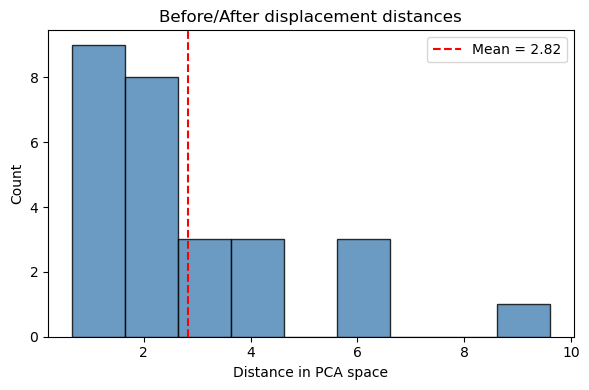

Distances (n=27):
[1.132 1.734 5.751 3.227 5.735 9.603 1.811 6.608 4.302 3.261 1.291 4.339
 3.786 2.055 1.293 1.668 0.656 2.797 2.247 2.498 1.852 1.13  1.491 1.106
 0.933 2.371 1.577]
Mean ± SD: 2.824 ± 2.053


In [464]:
# Histogram of per-bouton displacement distances (before -> after)
distances = np.linalg.norm(delta, axis=1)

plt.figure(figsize=(6,4))
plt.hist(distances, bins=9, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(distances.mean(), color='red', linestyle='dashed', linewidth=1.5, label=f"Mean = {distances.mean():.2f}")
plt.xlabel('Distance in PCA space')
plt.ylabel('Count')
plt.title('Before/After displacement distances')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Distances (n={len(distances)}):")
print(np.round(distances, 3))
print(f"Mean ± SD: {distances.mean():.3f} ± {distances.std():.3f}")


### 6.A.d Pairs that are above the mean before/after distances

Mean distance: 2.824
Pairs above mean distance (indices and distances):
Index 2: distance = 5.751
Index 3: distance = 3.227
Index 4: distance = 5.735
Index 5: distance = 9.603
Index 7: distance = 6.608
Index 8: distance = 4.302
Index 9: distance = 3.261
Index 11: distance = 4.339
Index 12: distance = 3.786


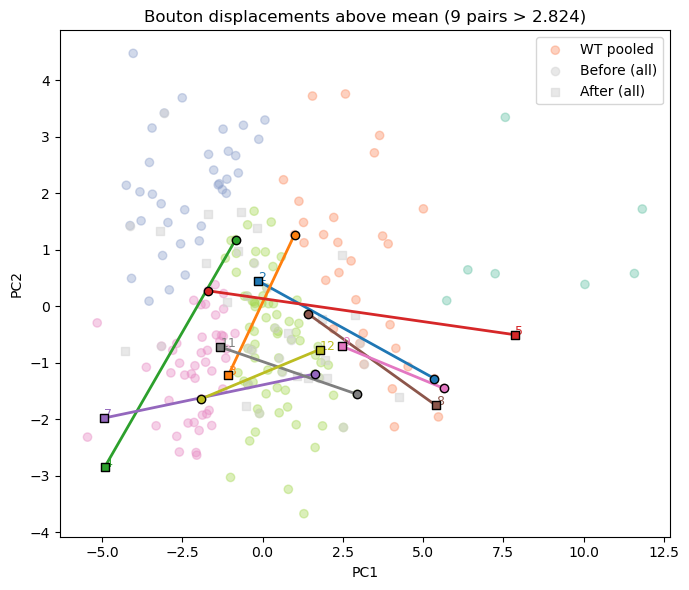

In [465]:
# Indices of pairs with distances greater than the mean
mean_distance = distances.mean()
above_mean_idx = np.where(distances > mean_distance)[0]

print(f"Mean distance: {mean_distance:.3f}")
print(f"Pairs above mean distance (indices and distances):")
for i in above_mean_idx:
    print(f"Index {i}: distance = {distances[i]:.3f}")

# Highlight pairs above mean distance on a dedicated PCA movement plot
plt.figure(figsize=(7,6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
plt.scatter(transformed_stab_before['PC1'], transformed_stab_before['PC2'], c='lightgray', label='Before (all)', alpha=0.5)
plt.scatter(transformed_stab_after['PC1'], transformed_stab_after['PC2'], c='lightgray', marker='s', label='After (all)', alpha=0.5)

colors_top = plt.cm.tab10.colors
for j, i in enumerate(above_mean_idx):
    c = colors_top[j % len(colors_top)]
    x0, y0 = transformed_stab_before.iloc[i][['PC1','PC2']]
    x1, y1 = transformed_stab_after.iloc[i][['PC1','PC2']]
    plt.plot([x0, x1], [y0, y1], color=c, linewidth=2)
    plt.scatter([x0], [y0], color=c, edgecolor='k', zorder=5)
    plt.scatter([x1], [y1], color=c, marker='s', edgecolor='k', zorder=5)
    plt.text(x1, y1, f"{i}", color=c, fontsize=9)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Bouton displacements above mean ({len(above_mean_idx)} pairs > {mean_distance:.3f})')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


### 6.A.e Traces of the pairs that are above the mean before/after distances

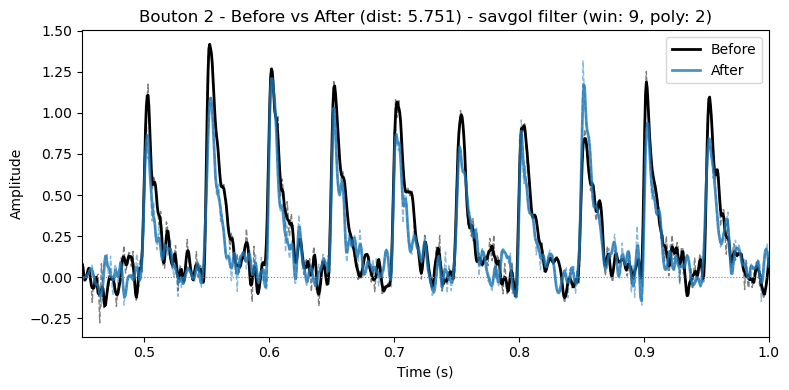

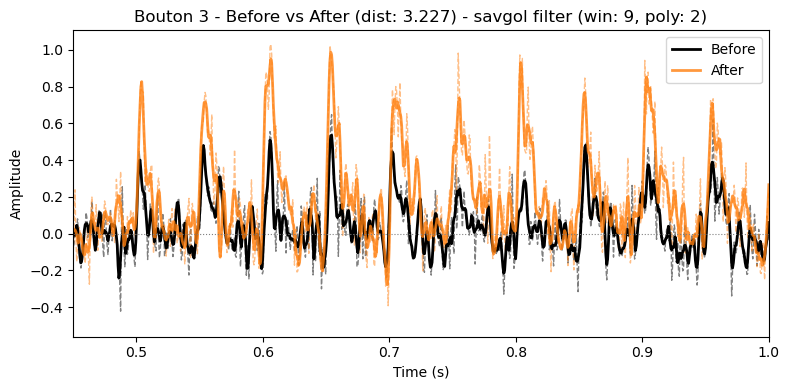

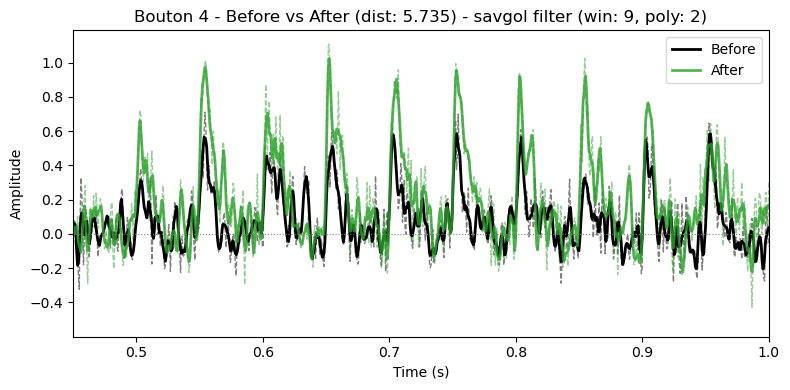

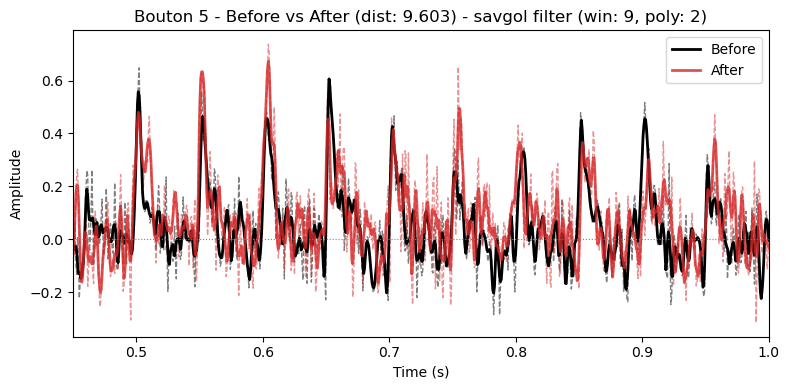

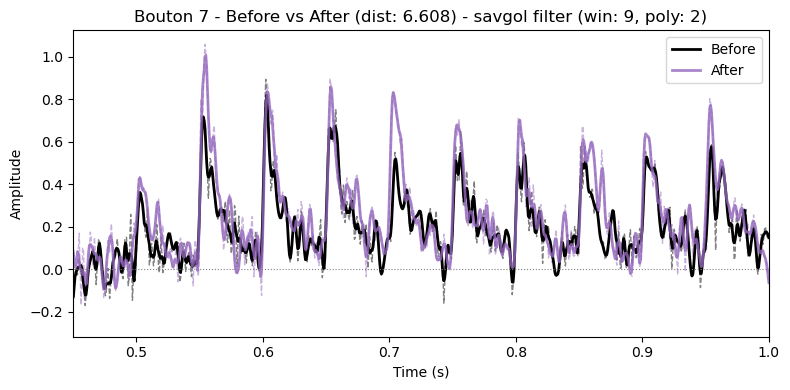

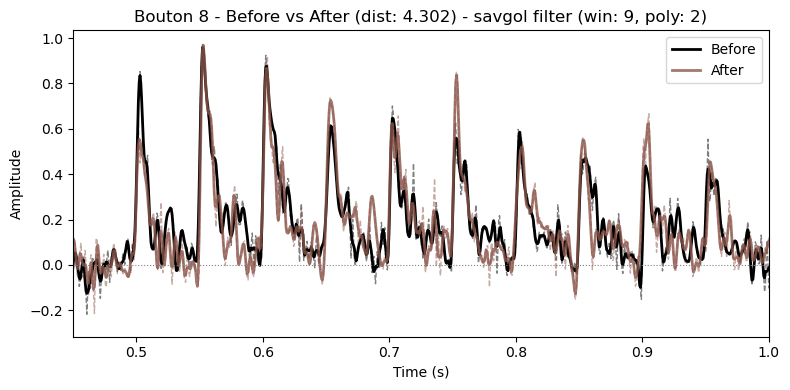

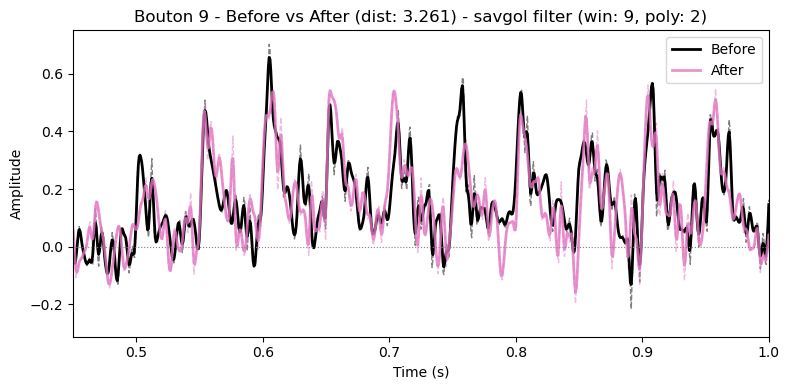

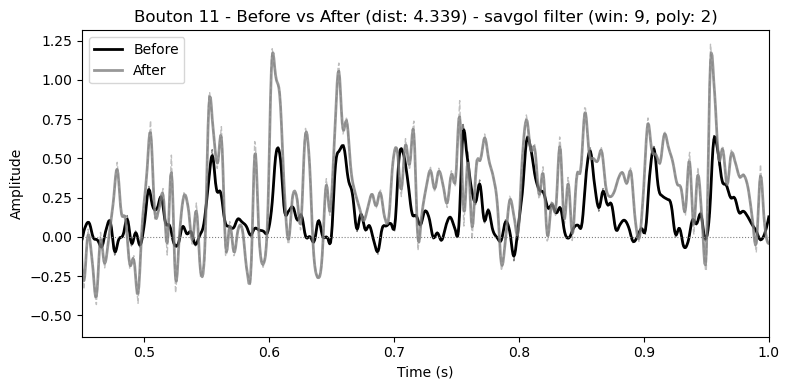

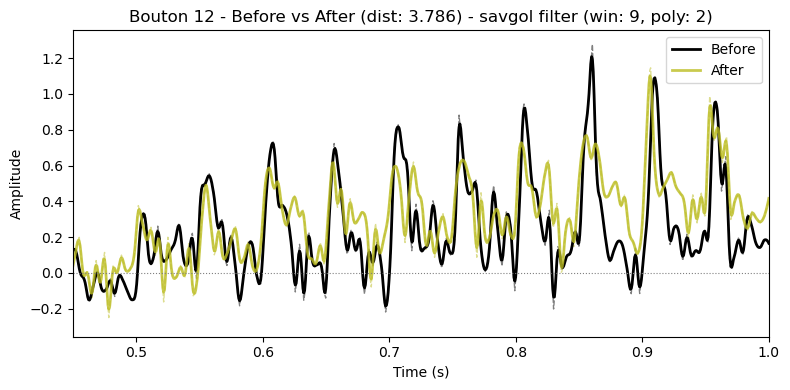

In [466]:
from scipy.signal import savgol_filter  # Savitzky-Golay (not imported earlier)
win = 9
pol = 2

# Plot traces for pairs above mean distance with same colors as previous cell + Savitzky-Golay smoothing
colors_top = plt.cm.tab10.colors

# Load trace data (kept as in original cell)
test_before = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name="Stability_Before")
test_after = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name="Stability_After")


if 'test_before' in locals() and 'test_after' in locals():
    try:
        time_test = test_before.iloc[1:, 0].astype(float).values
        n_cols_before = test_before.shape[1] - 1
        n_cols_after = test_after.shape[1] - 1

        for j, i in enumerate(above_mean_idx):
            if i >= n_cols_before or i >= n_cols_after:
                print(f"Index {i} ignored (insufficient columns).")
                continue

            c = colors_top[j % len(colors_top)]
            trace_b_raw = test_before.iloc[1:, i+1].astype(float).values
            trace_a_raw = test_after.iloc[1:, i+1].astype(float).values

            trace_b = savgol_filter(trace_b_raw, win, pol)
            trace_a = savgol_filter(trace_a_raw, win, pol)

            fig, ax = plt.subplots(figsize=(8, 4))
            # Raw (lighter / dashed)
            ax.plot(time_test, trace_b_raw, color='black', alpha=0.5, linestyle='--', linewidth=1)
            ax.plot(time_test, trace_a_raw, color=c, alpha=0.5, linestyle='--', linewidth=1)

            # Smoothed (main)
            ax.plot(time_test, trace_b, color='black', label=f'Before', linewidth=2)
            ax.plot(time_test, trace_a, color=c, alpha=0.8, label='After', linewidth=2)

            ax.axhline(0, color='gray', linewidth=0.8, linestyle='dotted')
            ax.set_xlim(0.45, 1.0)
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('Amplitude')
            ax.set_title(f'Bouton {i} - Before vs After (dist: {distances[i]:.3f}) - savgol filter (win: {win}, poly: {pol})')
            ax.legend()
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Error plotting traces: {e}")
else:
    print("test_before/test_after variables not found.")


## 6.B Cluster attribution with confidence ellispe

### 6.B.a Stability data (before and after) projected on the PCA with ellipses for clusters

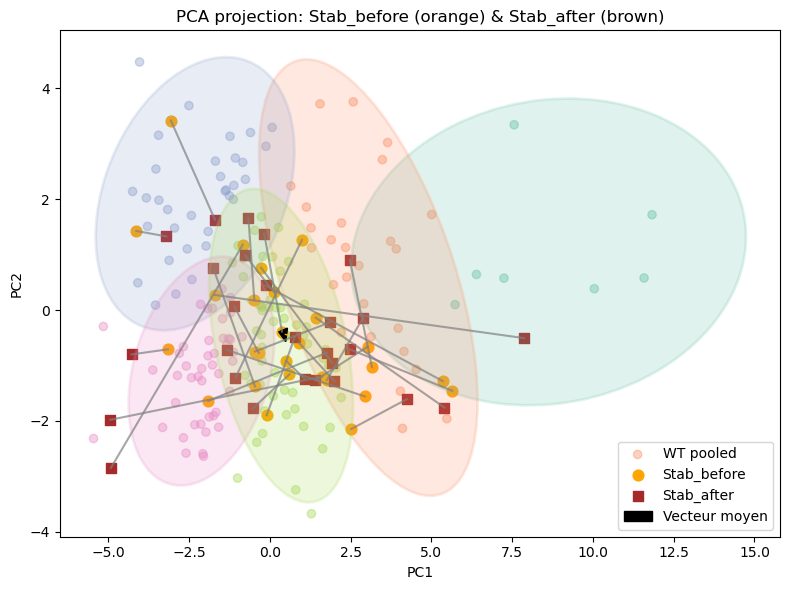

In [467]:
from matplotlib.patches import Ellipse
from scipy.stats import chi2

def draw_ellipse(position, covariance, ax, color, alpha=0.2, linewidth=2):
    """
    Dessine une ellipse de confiance pour des données 2D.
    
    Paramètres:
    - position: centre de l'ellipse (moyenne des points de données)
    - covariance: matrice de covariance des points de données
    - ax: objet axe matplotlib sur lequel dessiner
    - color: couleur de l'ellipse
    - alpha: transparence du remplissage de l'ellipse
    - linewidth: largeur de la bordure de l'ellipse
    """
    # chi2_val: Valeur critique du chi-2 pour une ellipse de confiance à 98% en 2D
    # Elle définit la taille de l'ellipse (plus la valeur est grande, plus l'ellipse est large)
    chi2_val = chi2.ppf(0.95, df=2)
    
    # Décomposition en valeurs singulières (SVD) de la matrice de covariance
    # U: matrice des vecteurs propres (directions principales des données)
    # s: valeurs propres (variance dans chaque direction principale)
    # _: matrice V transposée (non utilisée ici)
    U, s, _ = np.linalg.svd(covariance)
    
    # angle: angle de rotation de l'ellipse en degrés
    # Calculé à partir du premier vecteur propre pour orienter l'ellipse selon les données
    angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
    
    # width et height: largeur et hauteur de l'ellipse
    # Calculées à partir des valeurs propres et de la valeur critique du chi-2
    # Plus la variance est grande dans une direction, plus l'ellipse sera étendue dans cette direction
    width, height = 2 * np.sqrt(chi2_val * s)
    
    # Création et ajout de l'ellipse au graphique
    ellipse = Ellipse(position, width, height, angle, 
                     facecolor=color, edgecolor=color, 
                     alpha=alpha, linewidth=linewidth)
    ax.add_patch(ellipse)

plt.figure(figsize=(8, 6))
ax = plt.gca()
# Plot WT pooled background with cluster colors
ax.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')

# Plot Stab_before (orange)
ax.scatter(transformed_stab_before['PC1'], transformed_stab_before['PC2'], marker='o', s=60, c='orange', label='Stab_before')

# Plot Stab_after (brown)
ax.scatter(transformed_stab_after['PC1'], transformed_stab_after['PC2'], marker='s', s=60, c='brown', label='Stab_after')

# Add lines connecting same boutons
for i in range(min(len(transformed_stab_before), len(transformed_stab_after))):
    ax.plot(
        [transformed_stab_before.iloc[i]['PC1'], transformed_stab_after.iloc[i]['PC1']],
        [transformed_stab_before.iloc[i]['PC2'], transformed_stab_after.iloc[i]['PC2']],
        color='gray', alpha=0.7, linewidth=1.5
    )

# Confidence ellipses for each cluster
cmap = cm.get_cmap('Set2')
n_clust = len(set(hc_labels))
for cluster_id in range(1, n_clust + 1):
    mask = hc_labels == cluster_id
    cluster_points = transformed_WT_pooled.loc[mask, ['PC1', 'PC2']].values
    if len(cluster_points) > 2:
        center = cluster_points.mean(axis=0)
        cov = np.cov(cluster_points.T)
        draw_ellipse(center, cov, ax, color=cmap(cluster_id-1))

# Mean displacement vector
delta = transformed_stab_after.values - transformed_stab_before.values
mean_delta = delta.mean(axis=0)
all_points = np.vstack([transformed_stab_before.values, transformed_stab_after.values])
center = all_points.mean(axis=0)
ax.arrow(center[0], center[1], mean_delta[0], mean_delta[1], 
         color='black', width=0.05, head_width=0.25, head_length=0.25, length_includes_head=True, label='Vecteur moyen')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection: Stab_before (orange) & Stab_after (brown)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "40_PCA_stab_before_after.pdf"))
plt.show()

### 6.B.b Pieplot representation of stability

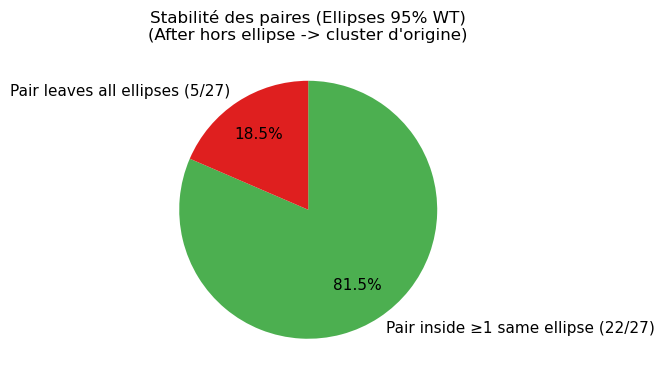

Total pairs: 27
Pairs staying in ≥1 same ellipse: 22 (81.5%)
Pairs leaving all ellipses: 5 (18.5%)
AFTER points réassignés (hors toute ellipse, cluster d'origine utilisé): 3

Paires sortant de toutes les ellipses (index, before -> after):
  1: [2] -> [5] (common=[])
  2: [1, 2] -> [5] (common=[])
  5: [3, 4, 5] -> [1] (common=[])
  11: [2] -> [4, 5] (common=[])
  12: [4] -> [2, 5] (common=[])


In [468]:
# Evaluate if each BEFORE/AFTER pair stays inside at least one same WT cluster 95% ellipse.
# Si un point AFTER ne tombe dans aucune ellipse, on lui attribue son cluster d'origine (clusters_before).

chi2_thr = chi2.ppf(0.95, df=2)
ellipse_models = []  # [{'cluster': id, 'center': center, 'inv_cov': inv_cov}]

for cluster_id in range(1, n_clust + 1):
    mask = hc_labels == cluster_id
    cluster_points = transformed_WT_pooled.loc[mask, ['PC1', 'PC2']].values
    if cluster_points.shape[0] > 2:
        center = cluster_points.mean(axis=0)
        cov = np.cov(cluster_points.T)
        inv_cov = np.linalg.pinv(cov)  # pseudo-inverse
        ellipse_models.append({'cluster': cluster_id, 'center': center, 'inv_cov': inv_cov})

def point_clusters(point, models, thr):
    pcs = set()
    for m in models:
        d = point - m['center']
        md2 = float(d.T @ m['inv_cov'] @ d)
        if md2 <= thr:
            pcs.add(m['cluster'])
    return pcs

before_pts = transformed_stab_before[['PC1','PC2']].values
after_pts  = transformed_stab_after[['PC1','PC2']].values
n_pairs = min(len(before_pts), len(after_pts))

same_count = 0
diff_count = 0
outside_after_count = 0
details = []

use_original_clusters = 'clusters_before' in locals() and len(clusters_before) >= n_pairs

for i in range(n_pairs):
    cb = point_clusters(before_pts[i], ellipse_models, chi2_thr)
    ca = point_clusters(after_pts[i],  ellipse_models, chi2_thr)

    after_used_original = False
    # Si AFTER n'a aucune attribution, on lui assigne le cluster d'origine
    if len(ca) == 0:
        outside_after_count += 1
        if use_original_clusters:
            ca = {int(clusters_before[i])}
            after_used_original = True

    common = cb.intersection(ca)
    stays = len(common) > 0
    if stays:
        same_count += 1
    else:
        diff_count += 1

    details.append({
        'pair_index': i,
        'before_clusters': sorted(cb),
        'after_clusters': sorted(ca),
        'common': sorted(common),
        'stays_in_any_same_ellipse': stays,
        'after_outside_all_ellipses_initially': after_used_original
    })

# Pie chart
labels_pie = [
    f"Pair inside ≥1 same ellipse ({same_count}/{n_pairs})",
    f"Pair leaves all ellipses ({diff_count}/{n_pairs})"
]
sizes = [same_count, diff_count]
colors_pie = ['#4CAF50', '#DF1F1F']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels_pie, colors=colors_pie, autopct='%.1f%%',
        startangle=90, counterclock=False, pctdistance=0.7, textprops={'fontsize':11})
plt.title("Stabilité des paires (Ellipses 95% WT)\n(After hors ellipse -> cluster d'origine)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "41_PCA_stab_before_after_same_ellipse_pie_with_reassign.pdf"))
plt.show()

print(f"Total pairs: {n_pairs}")
print(f"Pairs staying in ≥1 same ellipse: {same_count} ({same_count/n_pairs*100:.1f}%)")
print(f"Pairs leaving all ellipses: {diff_count} ({diff_count/n_pairs*100:.1f}%)")
print(f"AFTER points réassignés (hors toute ellipse, cluster d'origine utilisé): {outside_after_count}")

if diff_count > 0:
    print("\nPaires sortant de toutes les ellipses (index, before -> after):")
    for d in details:
        if not d['stays_in_any_same_ellipse']:
            print(f"  {d['pair_index']}: {d['before_clusters']} -> {d['after_clusters']} (common={d['common']})")
else:
    print("\nToutes les paires restent dans au moins une ellipse commune (après réassignation si nécessaire).")


### 6.B.c Unstable (red) and stable (green) pairs

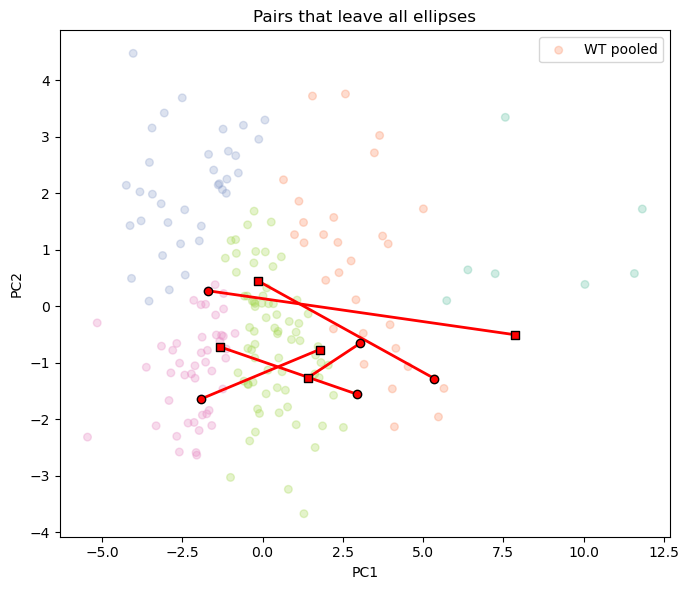

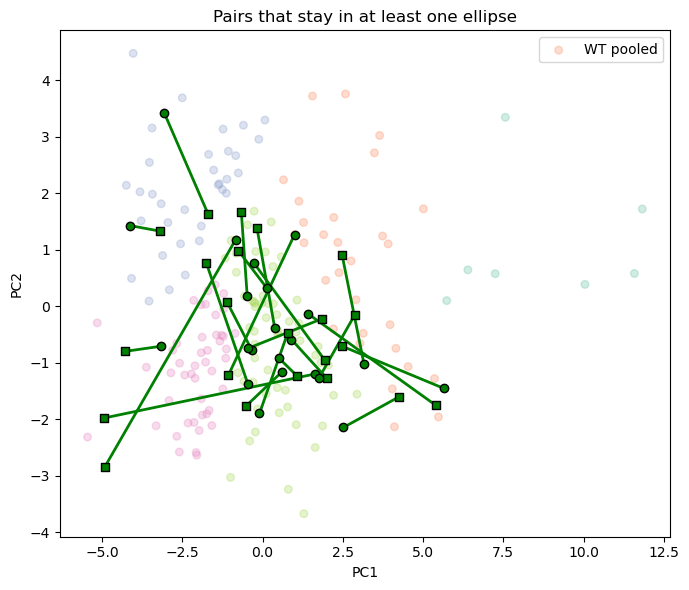

In [469]:
# Identify indices of pairs that leave all ellipses and those that stay in at least one
leave_indices = [d['pair_index'] for d in details if not d['stays_in_any_same_ellipse']]
stay_indices = [d['pair_index'] for d in details if d['stays_in_any_same_ellipse']]

# Graph 1: Pairs that leave all ellipses
plt.figure(figsize=(7, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.3, s=30, label='WT pooled')
for i in leave_indices:
    x0, y0 = transformed_stab_before.iloc[i][['PC1', 'PC2']]
    x1, y1 = transformed_stab_after.iloc[i][['PC1', 'PC2']]
    plt.plot([x0, x1], [y0, y1], color='red', linewidth=2)
    plt.scatter([x0], [y0], color='red', edgecolor='k', zorder=5)
    plt.scatter([x1], [y1], color='red', marker='s', edgecolor='k', zorder=5)
plt.title('Pairs that leave all ellipses')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "42_PCA_stab_pairs_leave_ellipses.pdf"))
plt.show()

# Graph 2: Pairs that stay in at least one ellipse
plt.figure(figsize=(7, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.3, s=30, label='WT pooled')
for i in stay_indices:
    x0, y0 = transformed_stab_before.iloc[i][['PC1', 'PC2']]
    x1, y1 = transformed_stab_after.iloc[i][['PC1', 'PC2']]
    plt.plot([x0, x1], [y0, y1], color='green', linewidth=2)
    plt.scatter([x0], [y0], color='green', edgecolor='k', zorder=5)
    plt.scatter([x1], [y1], color='green', marker='s', edgecolor='k', zorder=5)
plt.title('Pairs that stay in at least one ellipse')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "43_PCA_stab_pairs_stay_ellipses.pdf"))
plt.show()

### 6.B.d CONTROL - Random pairs

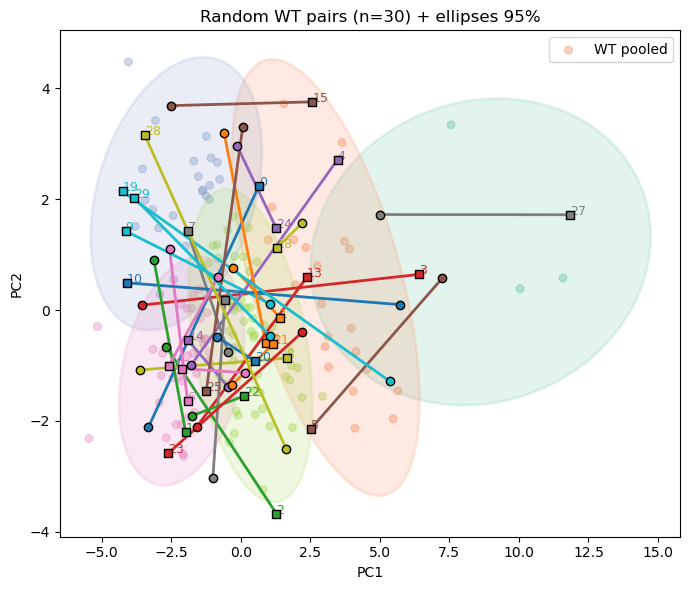

In [470]:
# Ajout des ellipses de confiance 95% pour les clusters WT + paires aléatoires
#np.random.seed(42)

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'],
           c=colors_umap, alpha=0.4, s=30, label='WT pooled')

# Dessiner les ellipses (réutilise draw_ellipse défini plus haut)
from scipy.stats import chi2
if 'draw_ellipse' not in globals():
    def draw_ellipse(position, covariance, ax, color, alpha=0.2, linewidth=2):
        chi2_val = chi2.ppf(0.95, df=2)
        U, s, _ = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(chi2_val * s)
        from matplotlib.patches import Ellipse
        ax.add_patch(Ellipse(position, width, height, angle,
                             facecolor=color, edgecolor=color, alpha=alpha, linewidth=linewidth))

cmap = cm.get_cmap('Set2')
unique_clust = np.unique(hc_labels)
for cl in unique_clust:
    pts = transformed_WT_pooled.loc[hc_labels == cl, ['PC1','PC2']].values
    if pts.shape[0] > 2:
        center = pts.mean(axis=0)
        cov = np.cov(pts.T)
        draw_ellipse(center, cov, ax, color=cmap(cl-1), alpha=0.18, linewidth=2)

# Paires aléatoires
n_pairs = min(30, len(transformed_WT_pooled)//2)
indices = np.random.permutation(len(transformed_WT_pooled))
pairs = [(indices[i], indices[i+n_pairs]) for i in range(n_pairs)]
colors_top = plt.cm.tab10.colors
for j, (i1, i2) in enumerate(pairs):
    c = colors_top[j % len(colors_top)]
    x0, y0 = transformed_WT_pooled.iloc[i1][['PC1','PC2']]
    x1, y1 = transformed_WT_pooled.iloc[i2][['PC1','PC2']]
    ax.plot([x0, x1], [y0, y1], color=c, linewidth=2)
    ax.scatter([x0], [y0], color=c, edgecolor='k', zorder=5)
    ax.scatter([x1], [y1], color=c, marker='s', edgecolor='k', zorder=5)
    ax.text(x1, y1, f"{j}", color=c, fontsize=9)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Random WT pairs (n={n_pairs}) + ellipses 95%')
ax.legend(loc='best')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "44_PCA_stab_random_WT_pairs_ellipses.pdf"))
plt.show()

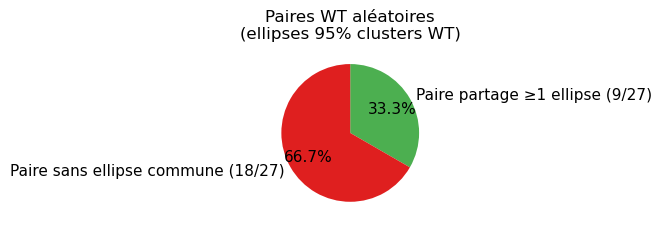

Total random pairs: 27
Paires partageant ≥1 ellipse: 9 (33.3%)
Paires sans ellipse commune: 18 (66.7%)

Paires sans ellipse commune (index, point1 -> point2):
  1: [5] -> [4]
  2: [5] -> [2]
  3: [4] -> [3]
  4: [3] -> [5]
  8: [] -> [5]
  9: [1] -> [3, 4, 5]
  10: [2, 5] -> [4]
  11: [4] -> [2, 5]
  12: [4, 5] -> [3]
  15: [1] -> [4, 5]
  16: [3] -> [4]
  17: [4] -> [3]
  18: [2] -> [3, 4, 5]
  19: [3] -> [1, 2]
  21: [5] -> [4]
  22: [4, 5] -> [2]
  23: [4, 5] -> [1]
  25: [4] -> [2, 5]


In [471]:
# Contrôle: évalue pour des paires WT aléatoires si les deux points partagent ≥1 ellipse 95% d'un même cluster

# (Réutilise ellipse_models et point_clusters si déjà définis, sinon les crée)
if 'ellipse_models' not in globals():
    chi2_thr = chi2.ppf(0.95, df=2)
    ellipse_models = []
    for cluster_id in range(1, n_clust + 1):
        mask = hc_labels == cluster_id
        cluster_points = transformed_WT_pooled.loc[mask, ['PC1', 'PC2']].values
        if cluster_points.shape[0] > 2:
            center = cluster_points.mean(axis=0)
            cov = np.cov(cluster_points.T)
            inv_cov = np.linalg.pinv(cov)
            ellipse_models.append({'cluster': cluster_id, 'center': center, 'inv_cov': inv_cov})
if 'point_clusters' not in globals():
    def point_clusters(point, models, thr):
        pcs = set()
        for m in models:
            d = point - m['center']
            md2 = float(d.T @ m['inv_cov'] @ d)
            if md2 <= thr:
                pcs.add(m['cluster'])
        return pcs
if 'chi2_thr' not in globals():
    chi2_thr = chi2.ppf(0.95, df=2)

# Nombre de paires aléatoires = nombre de paires stab (pour comparaison) ou autre choix
random_n_pairs = len(transformed_stab_before)

# Génère des paires sans recouvrement (façon cellule 7) si possible
total_pts = len(transformed_WT_pooled)
max_pairs_possible = total_pts // 2
if random_n_pairs > max_pairs_possible:
    random_n_pairs = max_pairs_possible

perm = np.random.permutation(total_pts)
pairs_idx = [(perm[i], perm[i + random_n_pairs]) for i in range(random_n_pairs)]

random_details = []
common_count = 0
diff_count = 0

wt_array = transformed_WT_pooled[['PC1','PC2']].values

for k, (i1, i2) in enumerate(pairs_idx):
    p1 = wt_array[i1]
    p2 = wt_array[i2]
    c1 = point_clusters(p1, ellipse_models, chi2_thr)
    c2 = point_clusters(p2, ellipse_models, chi2_thr)
    common = c1.intersection(c2)
    same = len(common) > 0
    if same:
        common_count += 1
    else:
        diff_count += 1
    random_details.append({
        'pair_index': k,
        'idx1': int(i1),
        'idx2': int(i2),
        'clusters_point1': sorted(c1),
        'clusters_point2': sorted(c2),
        'common_clusters': sorted(common),
        'share_any_ellipse': same
    })

# Pie chart
labels_pie = [
    f"Paire partage ≥1 ellipse ({common_count}/{random_n_pairs})",
    f"Paire sans ellipse commune ({diff_count}/{random_n_pairs})"
]
sizes = [common_count, diff_count]
colors_pie = ['#4CAF50', '#DF1F1F']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels_pie, colors=colors_pie, autopct='%.1f%%',
        startangle=90, counterclock=False, pctdistance=0.7, textprops={'fontsize':11})
plt.title("Paires WT aléatoires\n(ellipses 95% clusters WT)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "45_PCA_random_WT_pairs_same_ellipse_pie.pdf"))
plt.show()

print(f"Total random pairs: {random_n_pairs}")
print(f"Paires partageant ≥1 ellipse: {common_count} ({common_count/random_n_pairs*100:.1f}%)")
print(f"Paires sans ellipse commune: {diff_count} ({diff_count/random_n_pairs*100:.1f}%)")

if diff_count > 0:
    print("\nPaires sans ellipse commune (index, point1 -> point2):")
    for d in random_details:
        if not d['share_any_ellipse']:
            print(f"  {d['pair_index']}: {d['clusters_point1']} -> {d['clusters_point2']}")
else:
    print("\nToutes les paires aléatoires partagent au moins une ellipse.")


## 6.C Other way to attribute clusters

### 6.C.1 Alpha shape contour
Show the contour defined by the outermost points for each cluster

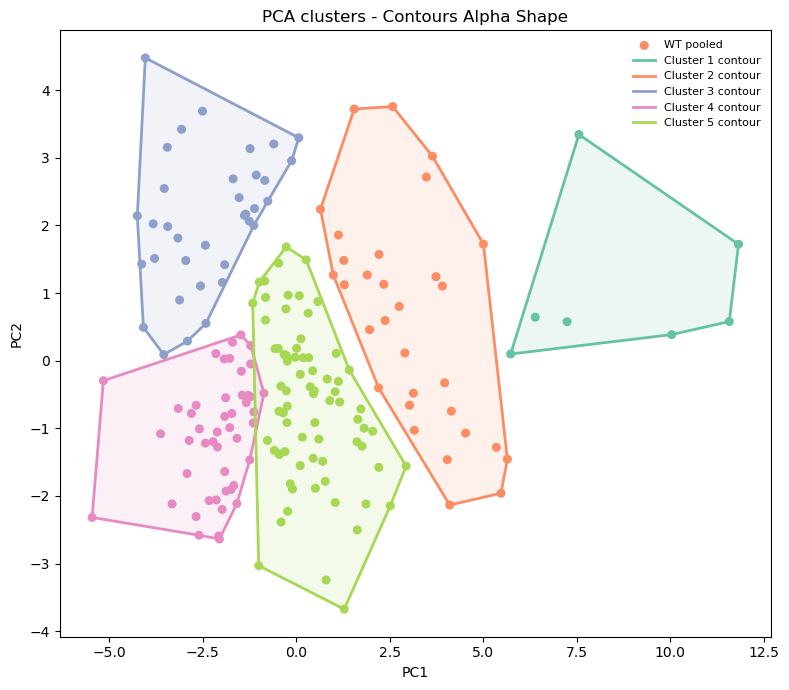

In [472]:
import alphashape
from shapely.geometry import Polygon as ShapelyPolygon, MultiPolygon

plt.figure(figsize=(8, 7))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, s=30, label='WT pooled')

unique_clusters = np.unique(hc_labels)

for idx, cl in enumerate(unique_clusters):
    pts = transformed_WT_pooled.loc[hc_labels == cl, ['PC1', 'PC2']].values
    if pts.shape[0] < 3:
        continue
    try:
        alpha = alphashape.optimizealpha(pts)
    except Exception:
        # fallback heuristique
        alpha = 0.1
    try:
        shape = alphashape.alphashape(pts, alpha)
    except Exception:
        continue

    def plot_geom(geom, first=True):
        if isinstance(geom, ShapelyPolygon):
            coords = np.array(geom.exterior.coords)
            plt.fill(coords[:, 0], coords[:, 1], color=cmap(idx), alpha=0.12)
            plt.plot(coords[:, 0], coords[:, 1], color=cmap(idx),
                     lw=2, label=f'Cluster {cl} contour' if first else None)

    if isinstance(shape, ShapelyPolygon):
        plot_geom(shape)
    elif isinstance(shape, MultiPolygon):
        for j, geom in enumerate(shape.geoms):
            plot_geom(geom, first=(j == 0))

plt.title("PCA clusters - Contours Alpha Shape")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc='best', fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


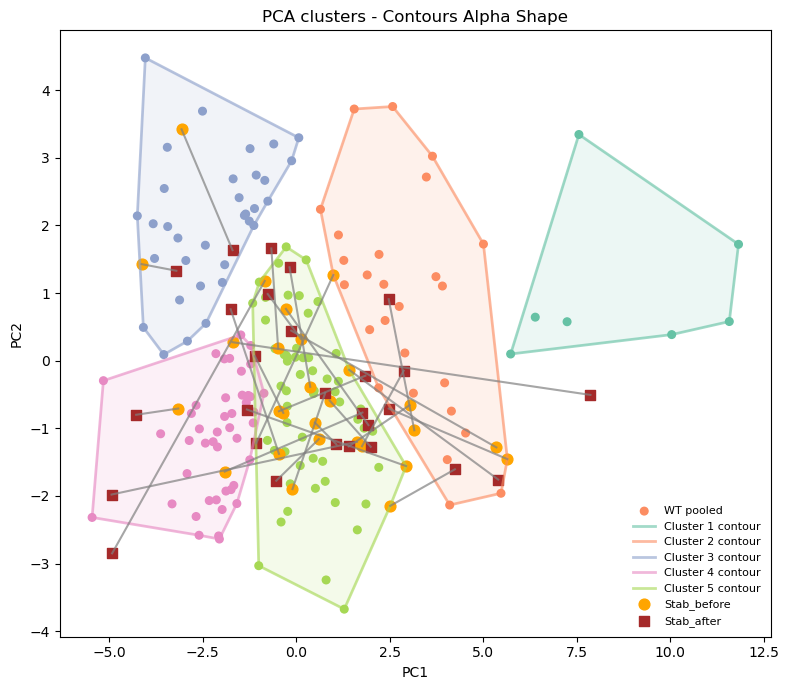

In [473]:
plt.figure(figsize=(8, 7))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, s=30, label='WT pooled')

unique_clusters = np.unique(hc_labels)

for idx, cl in enumerate(unique_clusters):
    pts = transformed_WT_pooled.loc[hc_labels == cl, ['PC1', 'PC2']].values
    if pts.shape[0] < 3:
        continue
    try:
        alpha = alphashape.optimizealpha(pts)
    except Exception:
        # fallback heuristique
        alpha = 0.1
    try:
        shape = alphashape.alphashape(pts, alpha)
    except Exception:
        continue

    def plot_geom(geom, first=True):
        if isinstance(geom, ShapelyPolygon):
            coords = np.array(geom.exterior.coords)
            plt.fill(coords[:, 0], coords[:, 1], color=cmap(idx), alpha=0.12)
            plt.plot(coords[:, 0], coords[:, 1], color=cmap(idx), alpha=0.6,
                     lw=2, label=f'Cluster {cl} contour' if first else None)

    if isinstance(shape, ShapelyPolygon):
        plot_geom(shape)
    elif isinstance(shape, MultiPolygon):
        for j, geom in enumerate(shape.geoms):
            plot_geom(geom, first=(j == 0))

ax = plt.gca()

# Plot Stab_before (orange)
ax.scatter(transformed_stab_before['PC1'], transformed_stab_before['PC2'], marker='o', s=60, c='orange', label='Stab_before')

# Plot Stab_after (brown)
ax.scatter(transformed_stab_after['PC1'], transformed_stab_after['PC2'], marker='s', s=60, c='brown', label='Stab_after')

# Add lines connecting same boutons
for i in range(min(len(transformed_stab_before), len(transformed_stab_after))):
    ax.plot(
        [transformed_stab_before.iloc[i]['PC1'], transformed_stab_after.iloc[i]['PC1']],
        [transformed_stab_before.iloc[i]['PC2'], transformed_stab_after.iloc[i]['PC2']],
        color='gray', alpha=0.7, linewidth=1.5
    )

plt.title("PCA clusters - Contours Alpha Shape")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc='best', fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


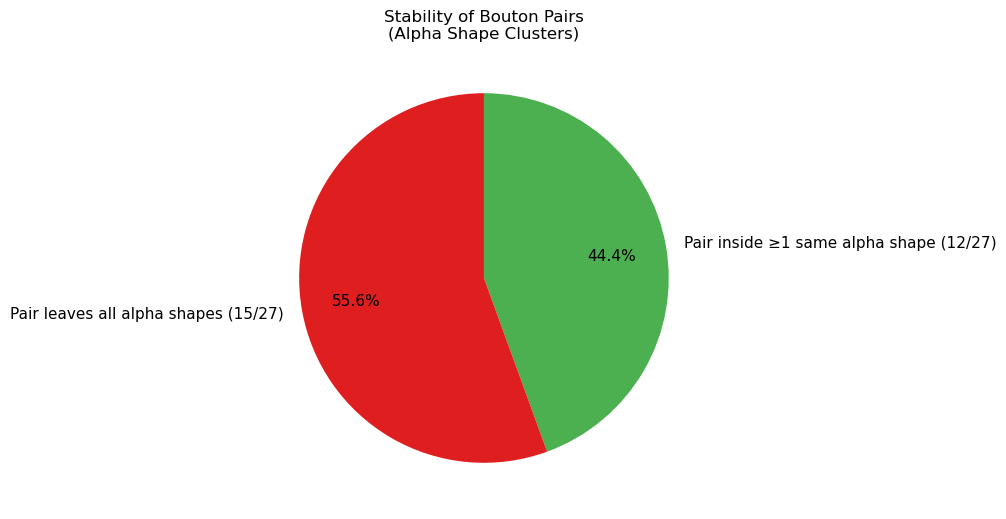

Alpha Shape Stability Analysis:
Total pairs evaluated: 27
Pairs staying in at least one same alpha shape: 12 (44.4%)
Pairs leaving all alpha shapes: 15 (55.6%)

Pairs leaving all alpha shapes (index, before_clusters -> after_clusters):
  1: [2] -> [5] (common=[])
  2: [2] -> [5] (common=[])
  3: [] -> [5] (common=[])
  4: [5] -> [] (common=[])
  5: [4] -> [] (common=[])
  6: [] -> [2] (common=[])
  7: [5] -> [4] (common=[])
  8: [] -> [2] (common=[])
  9: [] -> [] (common=[])
  11: [] -> [4] (common=[])
  12: [4] -> [5] (common=[])
  19: [5] -> [] (common=[])
  22: [5] -> [] (common=[])
  25: [5] -> [] (common=[])
  26: [5] -> [2] (common=[])


In [474]:
from shapely.geometry import Point

# Function to determine which alpha shape clusters contain a point
def point_in_alpha_shapes(point, alpha_shapes_dict):
    """Return set of cluster IDs whose alpha shapes contain the point."""
    clusters = set()
    for cluster_id, shape in alpha_shapes_dict.items():
        if shape is None:
            continue
        
        point_geom = Point(point[0], point[1])
        
        if isinstance(shape, ShapelyPolygon):
            if shape.contains(point_geom):
                clusters.add(cluster_id)
        elif isinstance(shape, MultiPolygon):
            for geom in shape.geoms:
                if geom.contains(point_geom):
                    clusters.add(cluster_id)
                    break
    
    return clusters

# Build alpha shapes for each cluster
alpha_shapes_dict = {}
unique_clusters = np.unique(hc_labels)

for cl in unique_clusters:
    pts = transformed_WT_pooled.loc[hc_labels == cl, ['PC1', 'PC2']].values
    if pts.shape[0] < 3:
        alpha_shapes_dict[cl] = None
        continue
    
    try:
        alpha = alphashape.optimizealpha(pts)
    except Exception:
        alpha = 0.1
    
    try:
        shape = alphashape.alphashape(pts, alpha)
        alpha_shapes_dict[cl] = shape
    except Exception:
        alpha_shapes_dict[cl] = None

# Evaluate stability using alpha shapes
before_pts = transformed_stab_before[['PC1','PC2']].values
after_pts = transformed_stab_after[['PC1','PC2']].values
n_pairs = min(len(before_pts), len(after_pts))

same_alpha_count = 0
diff_alpha_count = 0
alpha_details = []

for i in range(n_pairs):
    cb_alpha = point_in_alpha_shapes(before_pts[i], alpha_shapes_dict)
    ca_alpha = point_in_alpha_shapes(after_pts[i], alpha_shapes_dict)
    common_alpha = cb_alpha.intersection(ca_alpha)
    stays_alpha = len(common_alpha) > 0
    
    if stays_alpha:
        same_alpha_count += 1
    else:
        diff_alpha_count += 1
    
    alpha_details.append({
        'pair_index': i,
        'before_clusters': sorted(cb_alpha),
        'after_clusters': sorted(ca_alpha),
        'common': sorted(common_alpha),
        'stays_in_any_same_alpha': stays_alpha
    })

# Create pie chart for alpha shape stability
labels_alpha_pie = [
    f"Pair inside ≥1 same alpha shape ({same_alpha_count}/{n_pairs})",
    f"Pair leaves all alpha shapes ({diff_alpha_count}/{n_pairs})"
]
sizes_alpha = [same_alpha_count, diff_alpha_count]
colors_alpha_pie = ['#4CAF50', '#DF1F1F']

plt.figure(figsize=(6,6))
plt.pie(sizes_alpha, labels=labels_alpha_pie, colors=colors_alpha_pie, autopct='%.1f%%',
        startangle=90, counterclock=False, pctdistance=0.7, textprops={'fontsize':11})
plt.title("Stability of Bouton Pairs\n(Alpha Shape Clusters)")
plt.show()

# Print summary
print(f"Alpha Shape Stability Analysis:")
print(f"Total pairs evaluated: {n_pairs}")
print(f"Pairs staying in at least one same alpha shape: {same_alpha_count} ({same_alpha_count/n_pairs*100:.1f}%)")
print(f"Pairs leaving all alpha shapes: {diff_alpha_count} ({diff_alpha_count/n_pairs*100:.1f}%)\n")

if diff_alpha_count > 0:
    print("Pairs leaving all alpha shapes (index, before_clusters -> after_clusters):")
    for d in alpha_details:
        if not d['stays_in_any_same_alpha']:
            print(f"  {d['pair_index']}: {d['before_clusters']} -> {d['after_clusters']} (common={d['common']})")
else:
    print("All pairs remained within at least one common alpha shape.")

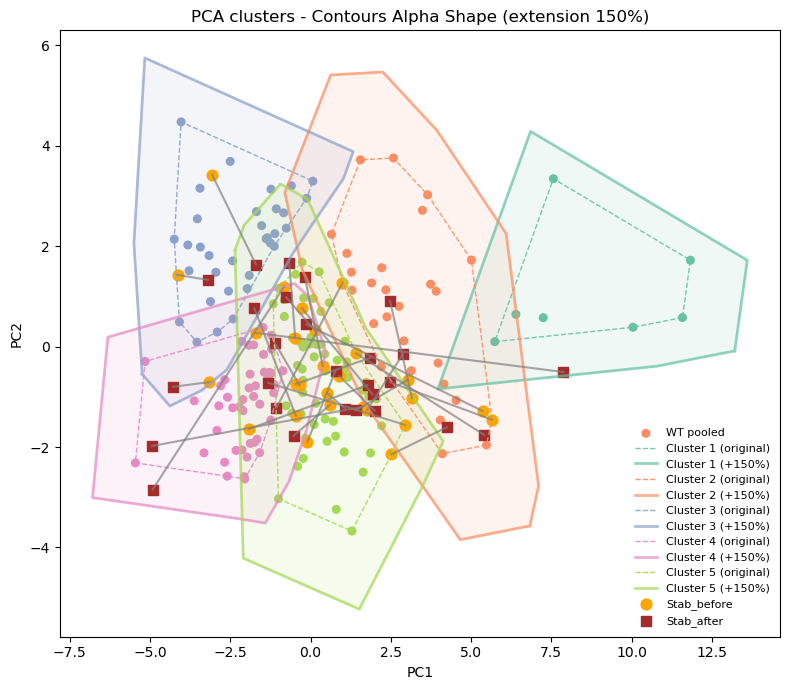

In [475]:
from shapely.affinity import scale as shp_scale

# Pourcentage d'extension de surface des contours (ex: 0.25 = +25%). Mettre 0 pour désactiver.
expand_pct = 1.5


scale_factor = (1 + expand_pct) ** 0.5  # facteur linéaire correspondant à l'augmentation de surface

plt.figure(figsize=(8, 7))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, s=30, label='WT pooled')

unique_clusters = np.unique(hc_labels)

for idx, cl in enumerate(unique_clusters):
    pts = transformed_WT_pooled.loc[hc_labels == cl, ['PC1', 'PC2']].values
    if pts.shape[0] < 3:
        continue
    try:
        alpha = alphashape.optimizealpha(pts)
    except Exception:
        alpha = 0.1
    try:
        shape = alphashape.alphashape(pts, alpha)
    except Exception:
        continue

    # Expansion du shape (surface augmentée de expand_pct)
    if expand_pct > 0:
        if isinstance(shape, ShapelyPolygon):
            shape_expanded = shp_scale(shape, xfact=scale_factor, yfact=scale_factor, origin='center')
        elif isinstance(shape, MultiPolygon):
            shape_expanded = MultiPolygon([shp_scale(g, xfact=scale_factor, yfact=scale_factor, origin='center')
                                           for g in shape.geoms])
        else:
            shape_expanded = shape
    else:
        shape_expanded = shape

    def plot_geom(geom, expanded=False, first=True):
        if isinstance(geom, ShapelyPolygon):
            coords = np.array(geom.exterior.coords)
            if expanded:
                plt.fill(coords[:, 0], coords[:, 1], color=cmap(idx), alpha=0.10)
                plt.plot(coords[:, 0], coords[:, 1], color=cmap(idx), alpha=0.7, lw=2,
                         label=f'Cluster {cl} (+{int(expand_pct*100)}%)' if first else None)
            else:
                plt.plot(coords[:, 0], coords[:, 1], color=cmap(idx), alpha=0.9, lw=1, linestyle='--',
                         label=f'Cluster {cl} (original)' if first else None)

    # Plot original contour
    if isinstance(shape, ShapelyPolygon):
        plot_geom(shape, expanded=False)
    elif isinstance(shape, MultiPolygon):
        for j, geom in enumerate(shape.geoms):
            plot_geom(geom, expanded=False, first=(j == 0))

    # Plot expanded contour
    if expand_pct > 0:
        if isinstance(shape_expanded, ShapelyPolygon):
            plot_geom(shape_expanded, expanded=True)
        elif isinstance(shape_expanded, MultiPolygon):
            for j, geom in enumerate(shape_expanded.geoms):
                plot_geom(geom, expanded=True, first=(j == 0))

ax = plt.gca()

# Points stability before / after
ax.scatter(transformed_stab_before['PC1'], transformed_stab_before['PC2'],
           marker='o', s=60, c='orange', label='Stab_before')
ax.scatter(transformed_stab_after['PC1'], transformed_stab_after['PC2'],
           marker='s', s=60, c='brown', label='Stab_after')

# Liaisons
for i in range(min(len(transformed_stab_before), len(transformed_stab_after))):
    ax.plot([transformed_stab_before.iloc[i]['PC1'], transformed_stab_after.iloc[i]['PC1']],
            [transformed_stab_before.iloc[i]['PC2'], transformed_stab_after.iloc[i]['PC2']],
            color='gray', alpha=0.7, linewidth=1.5)

plt.title(f"PCA clusters - Contours Alpha Shape (extension {int(expand_pct*100)}%)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc='best', fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


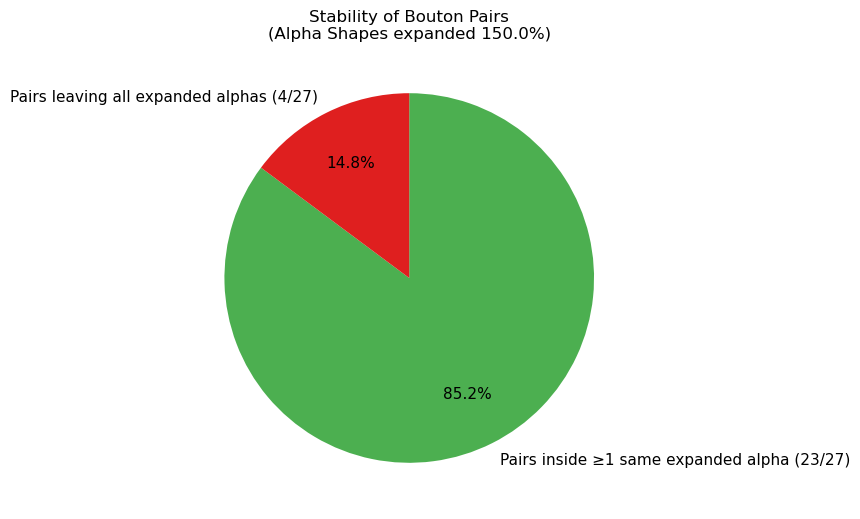

Alpha Shape Stability Analysis (expanded):
Expansion requested: 150.0%  (scale factor 1.5811)
Total pairs evaluated: 27
Pairs staying in ≥1 same expanded alpha shape: 23 (85.2%)
Pairs leaving all expanded alpha shapes: 4 (14.8%)

Pairs leaving all expanded alpha shapes:
  2: [2] -> [4, 5] (common=[])
  5: [3, 4, 5] -> [] (common=[])
  6: [5] -> [2] (common=[])
  7: [5] -> [4] (common=[])

Résumé des aires (original vs expanded):
   cluster  n_points  area_original  area_expanded  expand_pct
0        1         7      11.886724      29.716810         1.5
1        2        31      17.854893      44.637233         1.5
2        3        35      11.345551      28.363877         1.5
3        4        47      10.321551      25.803877         1.5
4        5        74      14.168840      35.422099         1.5


In [476]:
from shapely.geometry import Point
from shapely.prepared import prep
from shapely.affinity import scale as shp_scale
import math

def point_in_alpha_shapes(point, alpha_shapes_prepared, use_expanded=True):
    """Retourne IDs de clusters dont l'alpha-shape (évent. étendue) contient le point."""
    pt = Point(point[0], point[1])
    clusters = set()
    for cid, g in alpha_shapes_prepared.items():
        if g is None:
            continue
        prep_geom = g['prepared_expanded'] if (use_expanded and g.get('prepared_expanded')) else g['prepared']
        if prep_geom.contains(pt):
            clusters.add(cid)
    return clusters

alpha_shapes_dict = {}
alpha_shapes_prepared = {}
alpha_area_rows = []

scale_factor = math.sqrt(1 + expand_pct) if expand_pct > 0 else 1.0

for cl in unique_clusters:
    pts = transformed_WT_pooled.loc[hc_labels == cl, ['PC1', 'PC2']].values
    if pts.shape[0] < 4:
        alpha_shapes_dict[cl] = None
        alpha_shapes_prepared[cl] = None
        alpha_area_rows.append({
            'cluster': cl,
            'n_points': pts.shape[0],
            'area_original': None,
            'area_expanded': None,
            'expand_pct': expand_pct
        })
        continue
    try:
        alpha = alphashape.optimizealpha(pts)
    except Exception:
        bb = (pts[:,0].max()-pts[:,0].min() + pts[:,1].max()-pts[:,1].min())
        alpha = max(0.01, bb / (10 * pts.shape[0]))
    try:
        shape = alphashape.alphashape(pts, alpha)
        shape_expanded = shp_scale(shape, xfact=scale_factor, yfact=scale_factor, origin='centroid') if expand_pct>0 else None
        alpha_shapes_dict[cl] = shape
        alpha_shapes_prepared[cl] = {
            'shape': shape,
            'prepared': prep(shape),
            'shape_expanded': shape_expanded,
            'prepared_expanded': prep(shape_expanded) if shape_expanded is not None else None
        }
        alpha_area_rows.append({
            'cluster': cl,
            'n_points': pts.shape[0],
            'area_original': shape.area,
            'area_expanded': shape_expanded.area if shape_expanded is not None else shape.area,
            'expand_pct': expand_pct
        })
    except Exception:
        alpha_shapes_dict[cl] = None
        alpha_shapes_prepared[cl] = None
        alpha_area_rows.append({
            'cluster': cl,
            'n_points': pts.shape[0],
            'area_original': None,
            'area_expanded': None,
            'expand_pct': expand_pct
        })

alpha_areas_df = pd.DataFrame(alpha_area_rows)

before_pts = transformed_stab_before[['PC1','PC2']].values
after_pts  = transformed_stab_after[['PC1','PC2']].values
n_pairs = min(len(before_pts), len(after_pts))

same_alpha_count = 0
diff_alpha_count = 0
alpha_details = []

for i in range(n_pairs):
    cb_alpha = point_in_alpha_shapes(before_pts[i], alpha_shapes_prepared, use_expanded=True)
    ca_alpha = point_in_alpha_shapes(after_pts[i], alpha_shapes_prepared, use_expanded=True)
    common_alpha = cb_alpha.intersection(ca_alpha)
    stays_alpha = len(common_alpha) > 0
    if stays_alpha:
        same_alpha_count += 1
    else:
        diff_alpha_count += 1
    alpha_details.append({
        'pair_index': i,
        'before_clusters': sorted(cb_alpha),
        'after_clusters': sorted(ca_alpha),
        'common': sorted(common_alpha),
        'stays_in_any_same_alpha': stays_alpha
    })

alpha_details_df = pd.DataFrame(alpha_details)

labels_alpha_pie = [
    f"Pairs inside ≥1 same expanded alpha ({same_alpha_count}/{n_pairs})",
    f"Pairs leaving all expanded alphas ({diff_alpha_count}/{n_pairs})"
]
sizes_alpha = [same_alpha_count, diff_alpha_count]
colors_alpha_pie = ['#4CAF50', '#DF1F1F']

plt.figure(figsize=(6,6))
plt.pie(sizes_alpha, labels=labels_alpha_pie, colors=colors_alpha_pie, autopct='%.1f%%',
        startangle=90, counterclock=False, pctdistance=0.7, textprops={'fontsize':11})

plt.title(f"Stability of Bouton Pairs\n(Alpha Shapes expanded {expand_pct*100:.1f}%)")
plt.show()

print("Alpha Shape Stability Analysis (expanded):")
print(f"Expansion requested: {expand_pct*100:.1f}%  (scale factor {scale_factor:.4f})")
print(f"Total pairs evaluated: {n_pairs}")
print(f"Pairs staying in ≥1 same expanded alpha shape: {same_alpha_count} ({same_alpha_count/n_pairs*100:.1f}%)")
print(f"Pairs leaving all expanded alpha shapes: {diff_alpha_count} ({diff_alpha_count/n_pairs*100:.1f}%)\n")

if diff_alpha_count > 0:
    print("Pairs leaving all expanded alpha shapes:")
    for _, d in alpha_details_df[~alpha_details_df['stays_in_any_same_alpha']].iterrows():
        print(f"  {d.pair_index}: {d.before_clusters} -> {d.after_clusters} (common={d.common})")
else:
    print("All pairs remained within at least one common expanded alpha shape.")

print("\nRésumé des aires (original vs expanded):")
print(alpha_areas_df)

### 6.C.2 One-class SVM contour

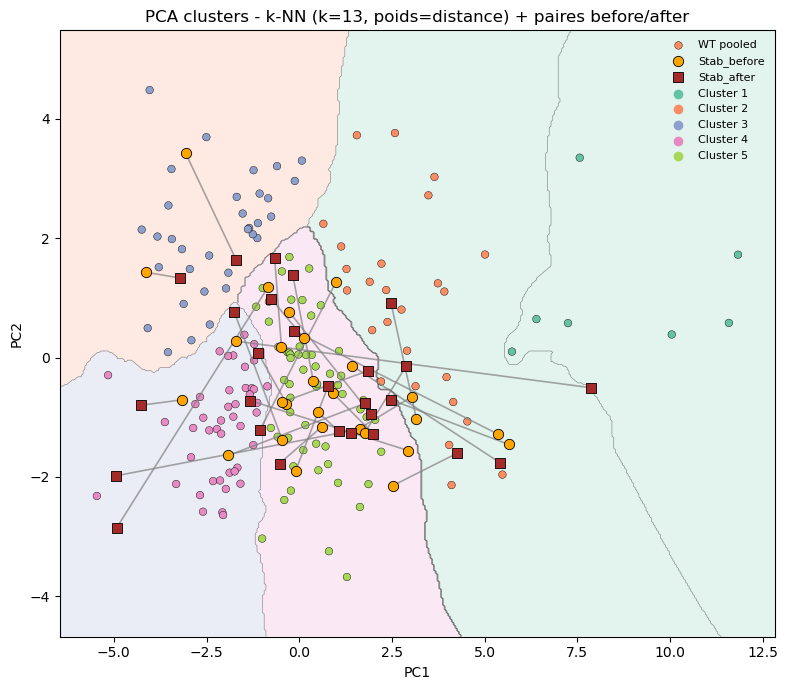

In [477]:
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

# Données k-NN
try:
    X = transformed_WT_pooled[['PC1', 'PC2']].values
except Exception:
    X = np.asarray(transformed_WT_pooled)
y = hc_labels

# k impair automatique
k = int(np.sqrt(len(y)))
if k < 3:
    k = 3
if k % 2 == 0:
    k += 1

knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
knn.fit(X, y)

# Grille
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

unique_clusters = np.unique(y)
cmap_base = cm.get_cmap('Set2')
cmap_regions = ListedColormap([cmap_base(i) for i in range(len(unique_clusters))])

plt.figure(figsize=(8, 7))

# Zones de décision
plt.contourf(xx, yy, Z,
             levels=np.append(unique_clusters, unique_clusters[-1] + 1),
             cmap=cmap_regions, alpha=0.18, antialiased=True)

# Frontières
plt.contour(xx, yy, Z, levels=unique_clusters, colors='k', linewidths=0.4, alpha=0.5)

# Points apprentissage
plt.scatter(X[:, 0], X[:, 1], c=colors_umap, s=30, edgecolors='k', linewidths=0.3, label='WT pooled', zorder=3)

# Ajout des paires before/after
if 'transformed_stab_before' in globals() and 'transformed_stab_after' in globals():
    b = transformed_stab_before[['PC1', 'PC2']].values
    a = transformed_stab_after[['PC1', 'PC2']].values
    n_pairs = min(len(b), len(a))
    # Lignes de déplacement
    for i in range(n_pairs):
        plt.plot([b[i,0], a[i,0]], [b[i,1], a[i,1]], color='gray', alpha=0.7, linewidth=1.2, zorder=4)
    # Points
    plt.scatter(b[:,0], b[:,1], c='orange', s=55, edgecolors='k', linewidths=0.6, label='Stab_before', zorder=5)
    plt.scatter(a[:,0], a[:,1], c='brown', marker='s', s=55, edgecolors='k', linewidths=0.6, label='Stab_after', zorder=6)

# Légende clusters
for cl in unique_clusters:
    plt.scatter([], [], color=cmap_base(cl-1), label=f'Cluster {cl}')
plt.legend(loc='best', fontsize=8, frameon=False)

plt.title(f"PCA clusters - k-NN (k={k}, poids=distance) + paires before/after")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [478]:
"""import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=12, weights="distance")
knn.fit(X, labels)

res = 400
xx, yy = np.meshgrid(np.linspace(0, 1, res), np.linspace(0, 1, res))
grid = np.c_[xx.ravel(), yy.ravel()]

proba = knn.predict_proba(grid)
pred = proba.argmax(1).reshape(xx.shape)

sorted_proba = np.sort(proba, axis=1)
margin = (sorted_proba[:, -1] - sorted_proba[:, -2]).reshape(xx.shape)

threshold = 1.0
conf_mask = np.where(margin < threshold, 1.0, np.nan)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, pred, levels=np.arange(n_clusters + 1) - 0.5, alpha=0.25)
plt.contourf(xx, yy, conf_mask, levels=[0.5, 1.5], alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("Confidence perimeter: margin < 1.0 (nearly full overlay)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()"""


'import numpy as np\nimport matplotlib.pyplot as plt\nfrom scipy.cluster.hierarchy import linkage, fcluster\nfrom sklearn.neighbors import KNeighborsClassifier\n\nknn = KNeighborsClassifier(n_neighbors=12, weights="distance")\nknn.fit(X, labels)\n\nres = 400\nxx, yy = np.meshgrid(np.linspace(0, 1, res), np.linspace(0, 1, res))\ngrid = np.c_[xx.ravel(), yy.ravel()]\n\nproba = knn.predict_proba(grid)\npred = proba.argmax(1).reshape(xx.shape)\n\nsorted_proba = np.sort(proba, axis=1)\nmargin = (sorted_proba[:, -1] - sorted_proba[:, -2]).reshape(xx.shape)\n\nthreshold = 1.0\nconf_mask = np.where(margin < threshold, 1.0, np.nan)\n\nplt.figure(figsize=(6, 6))\nplt.contourf(xx, yy, pred, levels=np.arange(n_clusters + 1) - 0.5, alpha=0.25)\nplt.contourf(xx, yy, conf_mask, levels=[0.5, 1.5], alpha=0.4)\nplt.scatter(X[:, 0], X[:, 1], c=labels)\nplt.title("Confidence perimeter: margin < 1.0 (nearly full overlay)")\nplt.xlim(0, 1)\nplt.ylim(0, 1)\nplt.gca().set_aspect("equal", adjustable="box")\npl

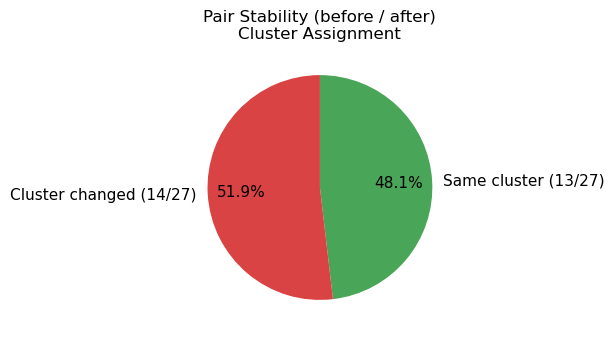

Total pairs: 27
Remain in the same cluster: 13 (48.1%)
Change cluster: 14 (51.9%)
Figure saved: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\20_SynII_vs_top2_clusters_4_3.pdf


In [479]:
# Pie chart: % of pairs remaining in the same cluster vs changing
# Assumes clusters_before and clusters_after (cell 76) already exist.
# Otherwise, raise an explicit error to prompt running the previous cell.

if 'clusters_before' not in locals() or 'clusters_after' not in locals():
    raise RuntimeError("clusters_before / clusters_after missing (run the cluster assignment cell first).")

if len(clusters_before) != len(clusters_after):
    raise ValueError("Different lengths between clusters_before and clusters_after.")

import matplotlib.pyplot as plt

same_mask = (clusters_before == clusters_after)
same_count = int(same_mask.sum())
total = len(clusters_before)
diff_count = total - same_count

pct_same = 100 * same_count / total
pct_diff = 100 * diff_count / total

labels = [f"Same cluster ({same_count}/{total})", f"Cluster changed ({diff_count}/{total})"]
sizes = [same_count, diff_count]
colors = ['#49A557', '#D94343']

fig, ax = plt.subplots(figsize=(6,6))
ax.pie(
    sizes,
    labels=labels,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    counterclock=False,
    colors=colors,
    pctdistance=0.7,
    textprops={'fontsize':11}
    )
ax.set_title("Pair Stability (before / after)\nCluster Assignment")
plt.tight_layout()
plt.show()

print(f"Total pairs: {total}")
print(f"Remain in the same cluster: {same_count} ({pct_same:.1f}%)")
print(f"Change cluster: {diff_count} ({pct_diff:.1f}%)")
print(f"Figure saved: {outfile}")

## 6.D Other figures (except PCA)

### 6.D.a PPR profiles before vs after

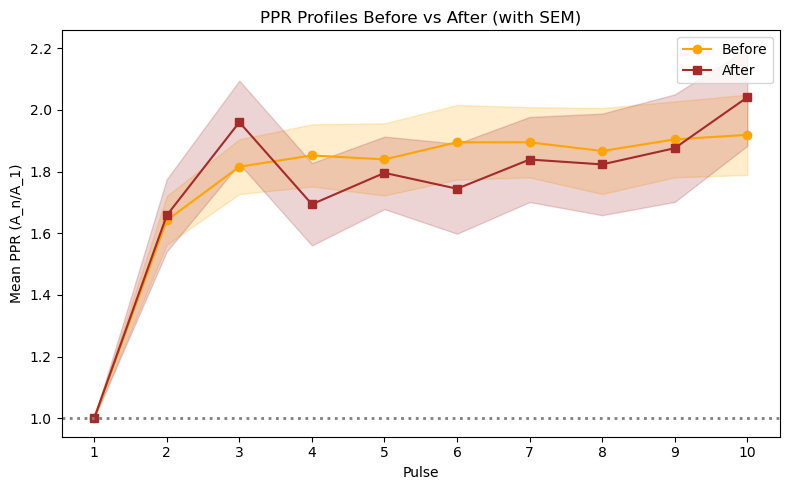

Paired t-test (Before vs After) per pulse:
Pulse 2 (PPR2/1): t = -0.122, p = 9.039e-01
Pulse 3 (PPR3/1): t = -0.995, p = 3.289e-01
Pulse 4 (PPR4/1): t = 1.099, p = 2.817e-01
Pulse 5 (PPR5/1): t = 0.298, p = 7.683e-01
Pulse 6 (PPR6/1): t = 0.996, p = 3.284e-01
Pulse 7 (PPR7/1): t = 0.378, p = 7.081e-01
Pulse 8 (PPR8/1): t = 0.228, p = 8.216e-01
Pulse 9 (PPR9/1): t = 0.159, p = 8.749e-01
Pulse 10 (PPR10/1): t = -0.693, p = 4.944e-01

Global (all PPR pulses 2-10 combined): t = 0.421, p = 6.744e-01


In [480]:
from scipy.stats import ttest_rel  # not imported earlier

# Plot PPR profiles (with SEM) for before and after conditions using PCA-transformed data

# Define PPR columns (assume same as used elsewhere)
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_stab_before.columns]
x_pulses = list(range(1, len(ppr_cols) + 2))  # 1 to 10

# Calculate means and SEMs for before
means_before = [1] + df_stab_before[ppr_cols].mean().tolist()
sems_before = [0] + df_stab_before[ppr_cols].sem().tolist()

# Calculate means and SEMs for after
means_after = [1] + df_stab_after[ppr_cols].mean().tolist()
sems_after = [0] + df_stab_after[ppr_cols].sem().tolist()

plt.figure(figsize=(8, 5))
plt.plot(x_pulses, means_before, marker='o', color='orange', label='Before')
plt.fill_between(x_pulses, np.array(means_before) - np.array(sems_before),
                 np.array(means_before) + np.array(sems_before), color='orange', alpha=0.2)
plt.plot(x_pulses, means_after, marker='s', color='brown', label='After')
plt.fill_between(x_pulses, np.array(means_after) - np.array(sems_after),
                 np.array(means_after) + np.array(sems_after), color='brown', alpha=0.2)
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.xlabel('Pulse')
plt.ylabel('Mean PPR (A_n/A_1)')
plt.title('PPR Profiles Before vs After (with SEM)')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.legend()
plt.savefig(os.path.join(output_dir, "46_PPR_profiles_before_after.pdf"))
plt.tight_layout()
plt.show()

# Paired Student t-test (before vs after) for each PPR pulse (excluding pulse 1 which is fixed at 1)
print("Paired t-test (Before vs After) per pulse:")
ttest_results = []
for pulse_idx, col in enumerate(ppr_cols, start=2):  # pulses start at 2 for PPR2/1
    t_stat, p_val = ttest_rel(df_stab_before[col], df_stab_after[col], nan_policy='omit')
    ttest_results.append((pulse_idx, col, t_stat, p_val))
    print(f"Pulse {pulse_idx} ({col}): t = {t_stat:.3f}, p = {p_val:.3e}")

# Optional: overall paired t-test on concatenated PPR values (all pulses 2-10)
all_before = df_stab_before[ppr_cols].values.flatten()
all_after = df_stab_after[ppr_cols].values.flatten()
t_global, p_global = ttest_rel(all_before, all_after, nan_policy='omit')
print(f"\nGlobal (all PPR pulses 2-10 combined): t = {t_global:.3f}, p = {p_global:.3e}")


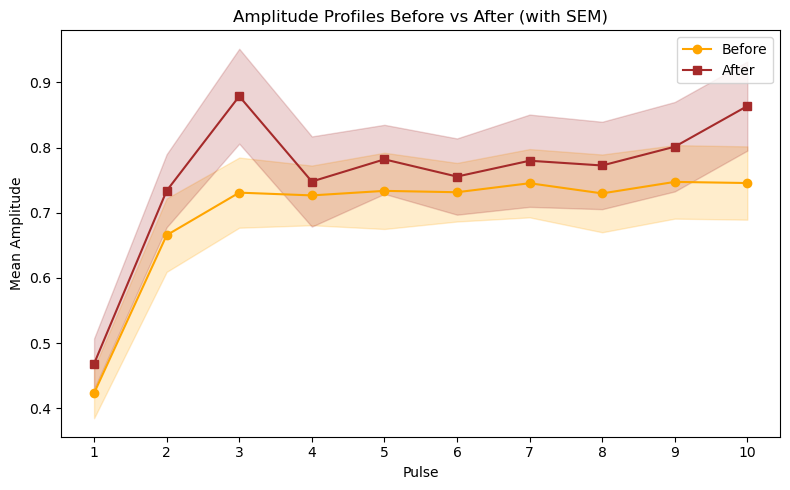

In [481]:
# Plot amplitude profiles (with SEM) for before and after conditions
#Stability experiments

#Import again, so we have the amplitudes (which was previously dropped)
df_stab_before = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="Stability_Before")
df_stab_after  = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="Stability_After")


# Detect amplitude columns (AMP1, AMP2, ...)
amp_cols = [f'AMP{i}' for i in range(1, 21) if f'AMP{i}' in df_stab_before.columns]
if not amp_cols:
    raise ValueError("No amplitude columns (AMP1, AMP2, ...) found in df_stab_before.")

x_pulses = list(range(1, len(amp_cols) + 1))

# Means and SEMs
means_before = df_stab_before[amp_cols].mean().values
sems_before = df_stab_before[amp_cols].sem().values

means_after = df_stab_after[amp_cols].mean().values
sems_after = df_stab_after[amp_cols].sem().values

plt.figure(figsize=(8, 5))
plt.plot(x_pulses, means_before, marker='o', color='orange', label='Before')
plt.fill_between(x_pulses, means_before - sems_before, means_before + sems_before,
                 color='orange', alpha=0.2)
plt.plot(x_pulses, means_after, marker='s', color='brown', label='After')
plt.fill_between(x_pulses, means_after - sems_after, means_after + sems_after,
                 color='brown', alpha=0.2)

plt.xlabel('Pulse')
plt.ylabel('Mean Amplitude')
plt.title('Amplitude Profiles Before vs After (with SEM)')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "47_Amplitude_profiles_before_after.pdf"))
plt.show()


### 6.D.b Comparison of Amp1 and PPR2/1 Before vs After

#### 6.D.b.1 Histograms

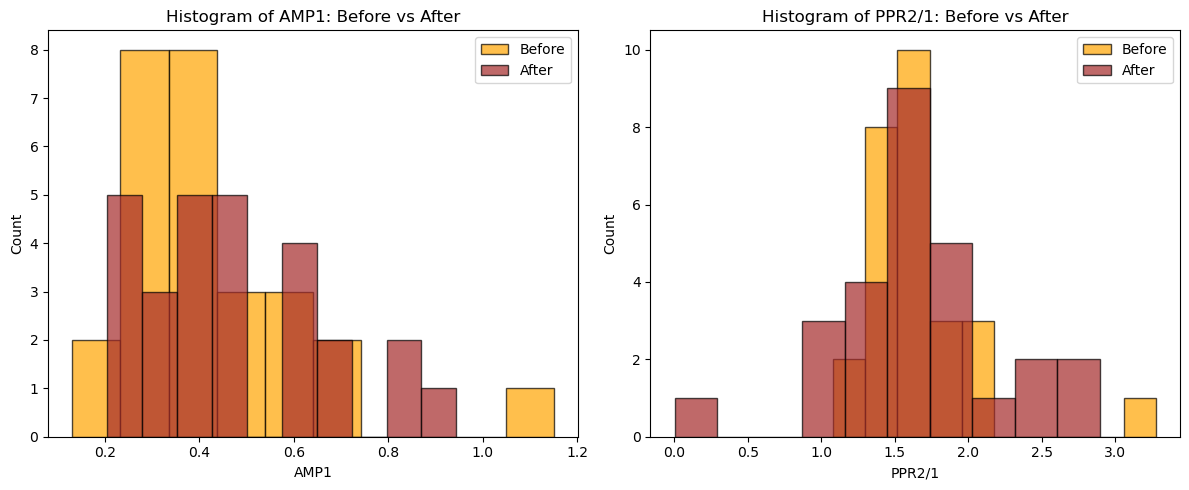

In [482]:
# Plot histograms of AMP1 and PPR2/1 values before and after
plt.figure(figsize=(12, 5))

# AMP1 histogram
plt.subplot(1, 2, 1)
plt.hist(df_stab_before['AMP1'], bins=10, alpha=0.7, label='Before', color='orange', edgecolor='black')
plt.hist(df_stab_after['AMP1'], bins=10, alpha=0.7, label='After', color='brown', edgecolor='black')
plt.xlabel('AMP1')
plt.ylabel('Count')
plt.title('Histogram of AMP1: Before vs After')
plt.legend()

# PPR2/1 histogram
plt.subplot(1, 2, 2)
plt.hist(df_stab_before['PPR2/1'], bins=10, alpha=0.7, label='Before', color='orange', edgecolor='black')
plt.hist(df_stab_after['PPR2/1'], bins=10, alpha=0.7, label='After', color='brown', edgecolor='black')
plt.xlabel('PPR2/1')
plt.ylabel('Count')
plt.title('Histogram of PPR2/1: Before vs After')
plt.legend()

plt.tight_layout()
plt.show()

#### 6.D.b.2 Boxplots

Paired t-test AMP1: p = 0.3766
 * p < 0.05: False
 ** p < 0.01: False
 *** p < 0.001: False
Paired t-test PPR2/1: p = 0.9039
 * p < 0.05: False
 ** p < 0.01: False
 *** p < 0.001: False


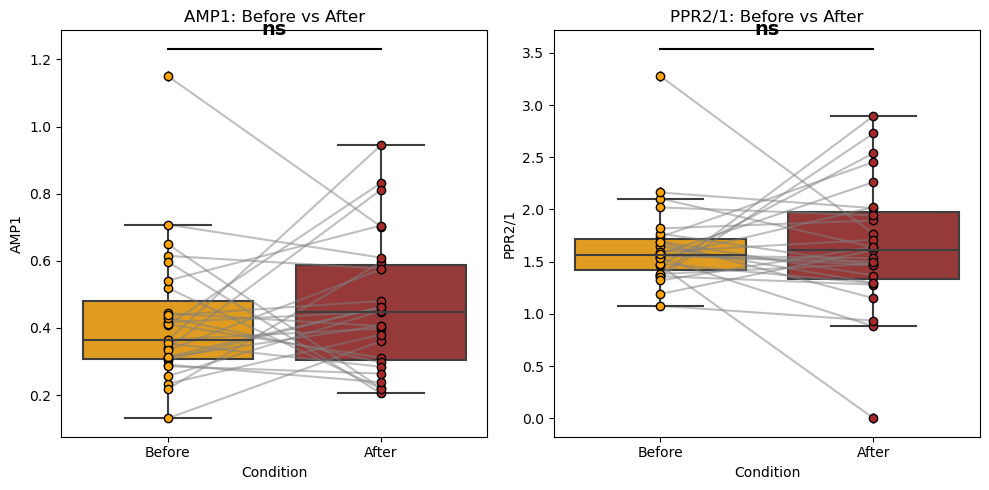

In [483]:
from scipy.stats import ttest_rel

# Boxplots comparing AMP1 and PPR2/1 before vs after, with all points and linking lines + paired t-test

# Load the original data for stability experiments (with AMP1 and PPR2/1 columns)
df_stab_before_full = pd.read_excel(
    r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx",
    sheet_name="Stability_Before"
)
df_stab_after_full = pd.read_excel(
    r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx",
    sheet_name="Stability_After"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Boxplot for AMP1
sns.boxplot(
    data=pd.DataFrame({
        'AMP1': pd.concat([df_stab_before_full['AMP1'], df_stab_after_full['AMP1']]).values,
        'Condition': ['Before'] * len(df_stab_before_full) + ['After'] * len(df_stab_after_full)
    }),
    x='Condition', y='AMP1', ax=ax1, palette=['orange', 'brown']
)
ax1.set_title('AMP1: Before vs After')
ax1.set_ylabel('AMP1')

# Overlay all points and link them
for i in range(min(len(df_stab_before_full), len(df_stab_after_full))):
    ax1.plot([0, 1], [df_stab_before_full['AMP1'].iloc[i], df_stab_after_full['AMP1'].iloc[i]],
             color='gray', alpha=0.5, zorder=1)
ax1.scatter(np.zeros(len(df_stab_before_full)), df_stab_before_full['AMP1'], color='orange', edgecolor='k', zorder=2)
ax1.scatter(np.ones(len(df_stab_after_full)), df_stab_after_full['AMP1'], color='brown', edgecolor='k', zorder=2)

# Paired t-test for AMP1
stat_amp1, p_amp1 = ttest_rel(df_stab_before_full['AMP1'], df_stab_after_full['AMP1'])
print(f"Paired t-test AMP1: p = {p_amp1:.4g}")
print(f" * p < 0.05: {p_amp1 < 0.05}")
print(f" ** p < 0.01: {p_amp1 < 0.01}")
print(f" *** p < 0.001: {p_amp1 < 0.001}")

def get_sigstars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

y_max_amp1 = max(df_stab_before_full['AMP1'].max(), df_stab_after_full['AMP1'].max())
y_min_amp1 = min(df_stab_before_full['AMP1'].min(), df_stab_after_full['AMP1'].min())
y_sig_amp1 = y_max_amp1 + 0.08 * (y_max_amp1 - y_min_amp1)
ax1.plot([0, 1], [y_sig_amp1, y_sig_amp1], color='black', lw=1.5)
ax1.text(0.5, y_sig_amp1 + 0.03 * (y_max_amp1 - y_min_amp1), get_sigstars(p_amp1),
         ha='center', va='bottom', fontsize=14, fontweight='bold')

# Boxplot for PPR2/1
sns.boxplot(
    data=pd.DataFrame({
        'PPR2/1': pd.concat([df_stab_before_full['PPR2/1'], df_stab_after_full['PPR2/1']]).values,
        'Condition': ['Before'] * len(df_stab_before_full) + ['After'] * len(df_stab_after_full)
    }),
    x='Condition', y='PPR2/1', ax=ax2, palette=['orange', 'brown']
)
ax2.set_title('PPR2/1: Before vs After')
ax2.set_ylabel('PPR2/1')

for i in range(min(len(df_stab_before_full), len(df_stab_after_full))):
    ax2.plot([0, 1], [df_stab_before_full['PPR2/1'].iloc[i], df_stab_after_full['PPR2/1'].iloc[i]],
             color='gray', alpha=0.5, zorder=1)
ax2.scatter(np.zeros(len(df_stab_before_full)), df_stab_before_full['PPR2/1'], color='orange', edgecolor='k', zorder=2)
ax2.scatter(np.ones(len(df_stab_after_full)), df_stab_after_full['PPR2/1'], color='brown', edgecolor='k', zorder=2)

# Paired t-test for PPR2/1
stat_ppr, p_ppr = ttest_rel(df_stab_before_full['PPR2/1'], df_stab_after_full['PPR2/1'])
print(f"Paired t-test PPR2/1: p = {p_ppr:.4g}")
print(f" * p < 0.05: {p_ppr < 0.05}")
print(f" ** p < 0.01: {p_ppr < 0.01}")
print(f" *** p < 0.001: {p_ppr < 0.001}")

y_max_ppr = max(df_stab_before_full['PPR2/1'].max(), df_stab_after_full['PPR2/1'].max())
y_min_ppr = min(df_stab_before_full['PPR2/1'].min(), df_stab_after_full['PPR2/1'].min())
y_sig_ppr = y_max_ppr + 0.08 * (y_max_ppr - y_min_ppr)
ax2.plot([0, 1], [y_sig_ppr, y_sig_ppr], color='black', lw=1.5)
ax2.text(0.5, y_sig_ppr + 0.03 * (y_max_ppr - y_min_ppr), get_sigstars(p_ppr),
         ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "48_AMP1_PPR2_boxplots_before_after.pdf"))
plt.show()

### 6.D.c Fo boxplots

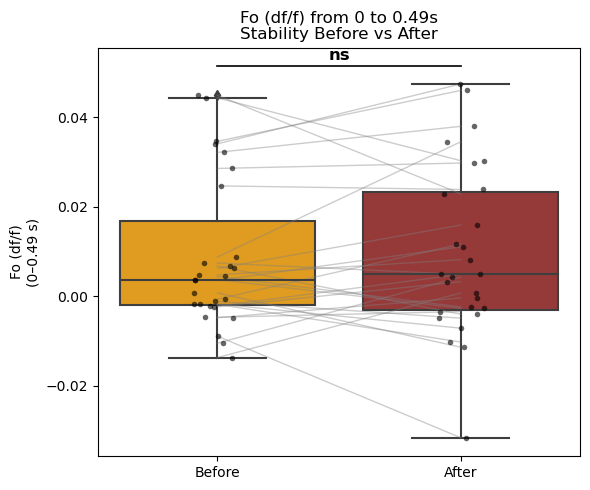

Time interval: 0–0.49 s  (n points = 734)
Before: n=27, mean=0.0088 ± 0.0166
After : n=27, mean=0.0096 ± 0.0187
Test paired t-test: stat=-0.3699, p=0.7145 (ns)
Figure saved: C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures\49_f0_boxplot.pdf


In [484]:
from scipy.stats import mannwhitneyu

# Average between 0 and 0.49 s of stability_before / stability_after traces + boxplot

# Load traces if missing (already loaded in cell 72 as test_before / test_after)
if 'test_before' not in locals() or 'test_after' not in locals():
    test_before = pd.read_excel(
        r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx',
        sheet_name=6
    )
    test_after = pd.read_excel(
        r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx',
        sheet_name=7
    )

# Extract time (skip the first row as done previously)
time_vec = test_before.iloc[1:, 0].astype(float).values
mask = (time_vec >= 0) & (time_vec <= 0.49)

if mask.sum() == 0:
    print("No time points in the interval 0 - 0.49 s.")
else:
    # Convert to numpy (rows = time, columns = boutons)
    traces_before = test_before.iloc[1:, 1:].astype(float).values
    traces_after  = test_after.iloc[1:, 1:].astype(float).values

    # Check compatible dimensions
    n_before = traces_before.shape[1]
    n_after = traces_after.shape[1]
    paired = (n_before == n_after)

    means_before = traces_before[mask, :].mean(axis=0)
    means_after  = traces_after[mask, :].mean(axis=0)

    df_box = pd.DataFrame({
        'Mean_0_0.49': np.concatenate([means_before, means_after]),
        'Condition': ['Before'] * len(means_before) + ['After'] * len(means_after)
    })

    plt.figure(figsize=(6, 5))
    ax = sns.boxplot(data=df_box, x='Condition', y='Mean_0_0.49', palette=['orange', 'brown'])
    sns.stripplot(data=df_box, x='Condition', y='Mean_0_0.49', color='black', size=4, alpha=0.6)

    # If paired, connect the points
    if paired:
        for i in range(n_before):
            plt.plot([0, 1], [means_before[i], means_after[i]], color='gray', alpha=0.4, linewidth=1)

    # Statistical test (paired if same number of columns, otherwise Mann-Whitney)
    if paired:
        stat, pval = ttest_rel(means_before, means_after)
        test_name = 'paired t-test'
    else:
        stat, pval = mannwhitneyu(means_before, means_after, alternative='two-sided')
        test_name = 'Mann-Whitney'

    def stars(p):
        return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

    y_max = df_box['Mean_0_0.49'].max()
    y_min = df_box['Mean_0_0.49'].min()
    y_sig = y_max + 0.05 * (y_max - y_min if y_max > y_min else 1)
    ax.plot([0, 1], [y_sig, y_sig], color='black', linewidth=1.2)
    ax.text(0.5, y_sig + 0.01 * (y_max - y_min if y_max > y_min else 1),
            stars(pval), ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_title('Fo (df/f) from 0 to 0.49s\nStability Before vs After')
    ax.set_ylabel('Fo (df/f)\n(0–0.49 s)')
    ax.set_xlabel('')
    plt.tight_layout()

    # Save figure
    out_fig = os.path.join(output_dir, "49_f0_boxplot.pdf")
    plt.savefig(out_fig)
    plt.show()

    # Summary
    print(f"Time interval: 0–0.49 s  (n points = {mask.sum()})")
    print(f"Before: n={len(means_before)}, mean={means_before.mean():.4f} ± {means_before.std():.4f}")
    print(f"After : n={len(means_after)}, mean={means_after.mean():.4f} ± {means_after.std():.4f}")
    print(f"Test {test_name}: stat={stat:.4f}, p={pval:.4g} ({stars(pval)})")
    print(f"Figure saved: {out_fig}")

# 7 - Chains of boutons.

To visualize the distribution of boutons from the same fiber within clusters.

In [485]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
import numpy as np

# Use the already imported dataframes with fiber ID columns
# Add fiber ID columns to each dataset
def get_fiber_id(full_id, dataset_type):
    if dataset_type == 'SynII':
        return full_id[:13]
    elif dataset_type == 'WT_Anthime':
        return full_id[:22]
    elif dataset_type == 'WT_Theo':
        return full_id[:18]
    else:
        return full_id

# Reload original dataframes with ID columns intact (since they were dropped earlier)
df_SynII_with_fiber = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="SynII")
df_WT_Anthime_with_fiber = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="WT_Anthime")
df_WT_Theo_with_fiber = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\ppr_results_higher_failure90.xlsx", sheet_name="WT_Theo")

# Add fiber ID columns
df_SynII_with_fiber['Fiber_ID'] = df_SynII_with_fiber['ID'].apply(lambda x: get_fiber_id(x, 'SynII'))
df_WT_Anthime_with_fiber['Fiber_ID'] = df_WT_Anthime_with_fiber['ID'].apply(lambda x: get_fiber_id(x, 'WT_Anthime'))
df_WT_Theo_with_fiber['Fiber_ID'] = df_WT_Theo_with_fiber['ID'].apply(lambda x: get_fiber_id(x, 'WT_Theo'))

# Combine all datasets with their types
all_data = []

# Add SynII data
for i, row in df_SynII_with_fiber.iterrows():
    if i < transformed_data_SynII.shape[0]:  # Check bounds
        all_data.append({
            'ID': row['ID'],
            'PC1': transformed_data_SynII[i, 0],
            'PC2': transformed_data_SynII[i, 1],
            'dataset': 'SynII',
            'fiber_id': row['Fiber_ID'],
            'color': 'orange',
            'marker': '*'
        })

# Add WT_Anthime data
for i, row in df_WT_Anthime_with_fiber.iterrows():
    if i < transformed_data_WT_Anthime.shape[0]:  # Check bounds
        all_data.append({
            'ID': row['ID'],
            'PC1': transformed_data_WT_Anthime[i, 0],
            'PC2': transformed_data_WT_Anthime[i, 1],
            'dataset': 'WT_Anthime',
            'fiber_id': row['Fiber_ID'],
            'color': 'lightgreen',
            'marker': 's'
        })

# Add WT_Theo data
for i, row in df_WT_Theo_with_fiber.iterrows():
    if i < transformed_data_WT_Theo.shape[0]:  # Check bounds
        all_data.append({
            'ID': row['ID'],
            'PC1': transformed_data_WT_Theo[i, 0],
            'PC2': transformed_data_WT_Theo[i, 1],
            'dataset': 'WT_Theo',
            'fiber_id': row['Fiber_ID'],
            'color': 'blue',
            'marker': 'o'
        })

# Group by fiber ID
fibers = {}
for data_point in all_data:
    fiber_id = data_point['fiber_id']
    if fiber_id not in fibers:
        fibers[fiber_id] = []
    fibers[fiber_id].append(data_point)

# Filter fibers with more than 1 bouton
fibers_multi = {k: v for k, v in fibers.items() if len(v) > 1}
fiber_list = list(fibers_multi.keys())

print(f"Found {len(fiber_list)} fibers with multiple boutons")

# Create interactive plot
class FiberNavigator:
    def __init__(self, fibers_dict, fiber_list):
        self.fibers = fibers_dict
        self.fiber_list = fiber_list
        self.current_index = 0
        
        # Create figure and axis
        self.fig, self.ax = plt.subplots(figsize=(12, 8))
        self.fig.subplots_adjust(bottom=0.2)
        
        # Add navigation buttons
        ax_prev = plt.axes([0.3, 0.05, 0.1, 0.075])
        ax_next = plt.axes([0.6, 0.05, 0.1, 0.075])
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        
        self.btn_prev.on_clicked(self.prev_fiber)
        self.btn_next.on_clicked(self.next_fiber)
        
        # Connect keyboard events
        self.fig.canvas.mpl_connect('key_press_event', self.on_key_press)
        
        # Initial plot
        self.update_plot()
        
    def prev_fiber(self, event=None):
        if self.current_index > 0:
            self.current_index -= 1
            self.update_plot()
    
    def next_fiber(self, event=None):
        if self.current_index < len(self.fiber_list) - 1:
            self.current_index += 1
            self.update_plot()
    
    def on_key_press(self, event):
        if event.key == 'left':
            self.prev_fiber()
        elif event.key == 'right':
            self.next_fiber()
    
    def update_plot(self):
        self.ax.clear()
        
        # Plot background PCA data (WT pooled)
        self.ax.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], 
                       c=colors_umap, alpha=0.3, s=30, label='WT pooled background')
        
        # Get current fiber data
        current_fiber_id = self.fiber_list[self.current_index]
        current_fiber_data = self.fibers[current_fiber_id]
        
        # Sort boutons by ID to maintain order along the fiber
        current_fiber_data.sort(key=lambda x: x['ID'])
        
        # Extract coordinates
        x_coords = [point['PC1'] for point in current_fiber_data]
        y_coords = [point['PC2'] for point in current_fiber_data]
        
        # Plot connection lines
        self.ax.plot(x_coords, y_coords, 'r-', linewidth=2, alpha=0.8, label='Fiber connection')
        
        # Plot boutons with numbers
        for i, point in enumerate(current_fiber_data):
            self.ax.scatter(point['PC1'], point['PC2'], 
                           c=point['color'], marker=point['marker'], 
                           s=100, edgecolor='black', linewidth=1, zorder=5)
            
            # Add number annotation
            self.ax.annotate(str(i+1), (point['PC1'], point['PC2']), 
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=10, fontweight='bold', 
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        # Set labels and title
        self.ax.set_xlabel('PC1')
        self.ax.set_ylabel('PC2')
        self.ax.set_title(f'Fiber {self.current_index + 1}/{len(self.fiber_list)}: {current_fiber_id}\n'
                         f'Dataset: {current_fiber_data[0]["dataset"]} | '
                         f'Boutons: {len(current_fiber_data)}')
        
        # Add legend
        self.ax.legend(loc='upper right')
        
        # Add navigation info
        self.fig.suptitle('Use LEFT/RIGHT arrows or buttons to navigate between fibers', 
                         fontsize=12, y=0.95)
        
        # Refresh plot
        self.fig.canvas.draw()

# Create and show the navigator in a new window
if len(fiber_list) > 0:
    # Force matplotlib to use a GUI backend for interactive window
    import matplotlib
    matplotlib.use('Qt5Agg')  # or 'TkAgg' if Qt5Agg is not available
    
    navigator = FiberNavigator(fibers_multi, fiber_list)
    
    # Set window title (handle different backends)
    try:
        # For Qt5Agg backend
        navigator.fig.canvas.manager.set_window_title("Fiber Navigator - Interactive Bouton Visualization")
    except AttributeError:
        try:
            # Alternative for other backends
            navigator.fig.canvas.manager.window.setWindowTitle("Fiber Navigator - Interactive Bouton Visualization")
        except AttributeError:
            # If neither works, just continue without setting title
            print("Window title could not be set, but the interactive window will still work")
    
    # Show the figure in a new window
    navigator.fig.show()
    
    # Keep the window open
    plt.show(block=True)
else:
    print("No fibers with multiple boutons found")

Found 59 fibers with multiple boutons


In [486]:
# Fix matplotlib backend to enable figure display
import matplotlib
import matplotlib.pyplot as plt
import warnings

# Set matplotlib to use a GUI backend that can display figures
matplotlib.use('Qt5Agg')  # Use Qt5Agg backend for interactive display

# Configure matplotlib for notebook display
%matplotlib inline

# Re-enable interactive mode and clear warnings
plt.ion()
plt.close('all')
plt.rcdefaults()
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

print("✓ Matplotlib backend configured for figure display")
print(f"✓ Current backend: {matplotlib.get_backend()}")
print("✓ Figures should now display properly in the notebook")

✓ Matplotlib backend configured for figure display
✓ Current backend: module://matplotlib_inline.backend_inline
✓ Figures should now display properly in the notebook
